# Exoplanet Detection — Complete Pipeline V2
**NASA Kepler | 1D CNN | 2D Visual Analysis | Diffusion Model | Full Evaluation | CLIP**

This notebook unifies every concept from V1, V2, and the evaluation suite into one pipeline:

| Section | Content |
|---|---|
| **Part 1** | Install, imports, NASA data acquisition (expanded columns + 300 samples/class) |
| **Part 2** | Preprocessing — quality filters, augmentation, signal statistics |
| **Part 3** | 1D visualization — phase-folded examples and signal comparisons |
| **Part 4** | 2D visual analysis — heatmaps, spectrograms, transit stacks |
| **Part 5** | 1D CNN — build, train, training history |
| **Part 6** | Diffusion model — generate synthetic light curves, augment dataset, retrain |
| **Part 7** | Full evaluation — confusion matrix, ROC, PR, F1, AUC, IoU, CLIP |
| **Part 8** | Predict on any Kepler star, save, download |

> **Runtime:** `Runtime > Change runtime type > T4 GPU` before running.

## Part 1 — Setup & Data Acquisition

In [ ]:
# ── Step 1: Install all dependencies ──────────────────────────────
import subprocess, sys, warnings
warnings.filterwarnings("ignore")

print("Installing dependencies...")

# Pin fsspec first to resolve Colab version conflicts
subprocess.run([sys.executable,"-m","pip","install","fsspec==2025.3.0","-q","--no-deps"], check=False)

# Core packages
subprocess.run([sys.executable,"-m","pip","install",
    "lightkurve","scikit-learn","scipy","seaborn","-q"], check=False)

print("✅ All dependencies installed")

Installing dependencies...
✅ All dependencies installed


In [ ]:
# ── Step 2: All global imports ────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings, time, os
warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import lightkurve as lk
from scipy import signal as scipy_signal
from scipy import stats as scipy_stats
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, average_precision_score
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm

# Global constants
BINS       = 201   # light curve bins after folding
BATCH_SIZE = 32
EPOCHS     = 60
N_SAMPLE   = 2000   # samples per class
SEED       = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Safe defaults — prevents NameError if cells are skipped ───────
history    = None   # set by training cell; guards downstream cells
results    = None   # set by evaluation cell
model      = None   # set by build_cnn cell
X_eval     = None   # set by NaN cleanup cell
y_test_eval= None
y_prob     = None
y_pred     = None
accuracy   = None
precision  = None
recall     = None
f1         = None
mcc        = None
roc_auc    = None
avg_prec   = None
tp = tn = fp = fn = 0
best_f1_thr = 0.5
f1_arr      = np.array([0.0])
best_f1_idx = 0
clip_acc = clip_f1 = clip_prec = clip_rec = 0.0
results_aug = [0, 0, 0, 0, 0]

print(f"TensorFlow   : {tf.__version__}")
print(f"GPU available: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Bins         : {BINS}")
print(f"Samples/class: {N_SAMPLE}")
print(f"Seed         : {SEED}")
print(f"Epochs       : {EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Num GPUs     : {len(tf.config.list_physical_devices('GPU'))}")
print(f"Num CPU cores: {os.cpu_count()}")
print("✅ Imports complete — safe defaults set")

TensorFlow   : 2.19.0
GPU available: True
Bins         : 201
Samples/class: 2000
Seed         : 42
Epochs       : 60
Batch size   : 32
Num GPUs     : 1
Num CPU cores: 2
✅ Imports complete — safe defaults set


In [ ]:
# ── Checkpoint Setup: mount Google Drive ─────────────────────────
# Saves model weights, epoch, learning rate between sessions
import os
from google.colab import drive

drive.mount('/content/drive')

CHECKPOINT_DIR  = '/content/drive/MyDrive/exoplanet_checkpoints'
CHECKPOINT_PATH = f'{CHECKPOINT_DIR}/best_model.h5'
HISTORY_PATH    = f'{CHECKPOINT_DIR}/history.npy'
EPOCH_PATH      = f'{CHECKPOINT_DIR}/last_epoch.npy'
LR_PATH         = f'{CHECKPOINT_DIR}/last_lr.npy'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f'✅ Drive mounted')
print(f'✅ Checkpoint directory: {CHECKPOINT_DIR}')
print(f'   best_model.h5  : {"EXISTS" if os.path.exists(CHECKPOINT_PATH) else "not found yet"}')
print(f'   history.npy    : {"EXISTS" if os.path.exists(HISTORY_PATH)    else "not found yet"}')
print(f'   last_epoch.npy : {"EXISTS" if os.path.exists(EPOCH_PATH)      else "not found yet"}')
print(f'   last_lr.npy    : {"EXISTS" if os.path.exists(LR_PATH)         else "not found yet"}')

Mounted at /content/drive
✅ Drive mounted
✅ Checkpoint directory: /content/drive/MyDrive/exoplanet_checkpoints
   best_model.h5  : not found yet
   history.npy    : not found yet
   last_epoch.npy : not found yet
   last_lr.npy    : not found yet


In [ ]:
# ── Resume cell: skip retraining on return sessions ──────────────
# ONLY run this if you already trained before and want to skip
# straight to evaluation. If first session, skip this cell.

if os.path.exists(CHECKPOINT_PATH):
    model.load_weights(CHECKPOINT_PATH)
    print('✅ Model weights loaded from Drive checkpoint')
else:
    print('❌ No checkpoint found — run the training cell below first')

if os.path.exists(LR_PATH):
    saved_lr = float(np.load(LR_PATH))
    keras.backend.set_value(model.optimizer.learning_rate, saved_lr)
    print(f'✅ Learning rate restored: {saved_lr:.6f}')
else:
    print('   No saved LR — using default 1e-4')

if os.path.exists(HISTORY_PATH):
    class HistoryWrapper:
        def __init__(self, h):
            self.history = h
    history = HistoryWrapper(
        np.load(HISTORY_PATH, allow_pickle=True).item())
    print('✅ Training history loaded')
    print(f'   Epochs recorded : {len(history.history["loss"])}')
    print(f'   Best val AUC    : {max(history.history["val_auc"]):.4f}')
    print(f'   Best val Acc    : {max(history.history["val_accuracy"]):.4f}')
else:
    print('   No history found — graphs will only show new epochs')
    history = None
    print('✅ No history loaded')

❌ No checkpoint found — run the training cell below first
   No saved LR — using default 1e-4
   No history found — graphs will only show new epochs
✅ No history loaded


In [ ]:
# ── Step 3: Download NASA KOI catalog (expanded columns) ──────────
print("Downloading NASA KOI cumulative catalog...")

url = (
    "https://exoplanetarchive.ipac.caltech.edu/cgi-bin/nstedAPI/nph-nstedAPI"
    "?table=cumulative"
    "&select=kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,"
    "koi_duration,koi_depth,koi_prad,koi_teq,koi_steff,koi_slogg,"
    "koi_srad,koi_smass,koi_impact,koi_incl"
    "&format=csv"
)

df_koi = pd.read_csv(url, comment="#")
print(f"✅ Downloaded {len(df_koi)} KOI entries")
print(f"Columns: {list(df_koi.columns)}")
df_koi.head()

✅ Downloaded 9564 KOI entries
Columns: ['kepid', 'kepoi_name', 'koi_disposition', 'koi_period', 'koi_time0bk', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_smass', 'koi_impact', 'koi_incl']


,kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,koi_duration,koi_depth,koi_prad,koi_teq,koi_steff,koi_slogg,koi_srad,koi_smass,koi_impact,koi_incl
0,10797460,K00752.01,CONFIRMED,9.488036,170.538750,2.95750,615.8,2.26,793.0,5455.0,4.467,0.927,0.919,0.146,89.66
1,10797460,K00752.02,CONFIRMED,54.418383,162.513840,4.50700,874.8,2.83,443.0,5455.0,4.467,0.927,0.919,0.586,89.57
2,10811496,K00753.01,CANDIDATE,19.899140,175.850252,1.78220,10829.0,14.60,638.0,5853.0,4.544,0.868,0.961,0.969,88.96
3,10848459,K00754.01,FALSE POSITIVE,1.736952,170.307565,2.40641,8079.2,33.46,1395.0,5805.0,4.564,0.791,0.836,1.276,67.09
4,10854555,K00755.01,CONFIRMED,2.525592,171.595550,1.65450,603.3,2.75,1406.0,6031.0,4.438,1.046,1.095,0.701,85.41


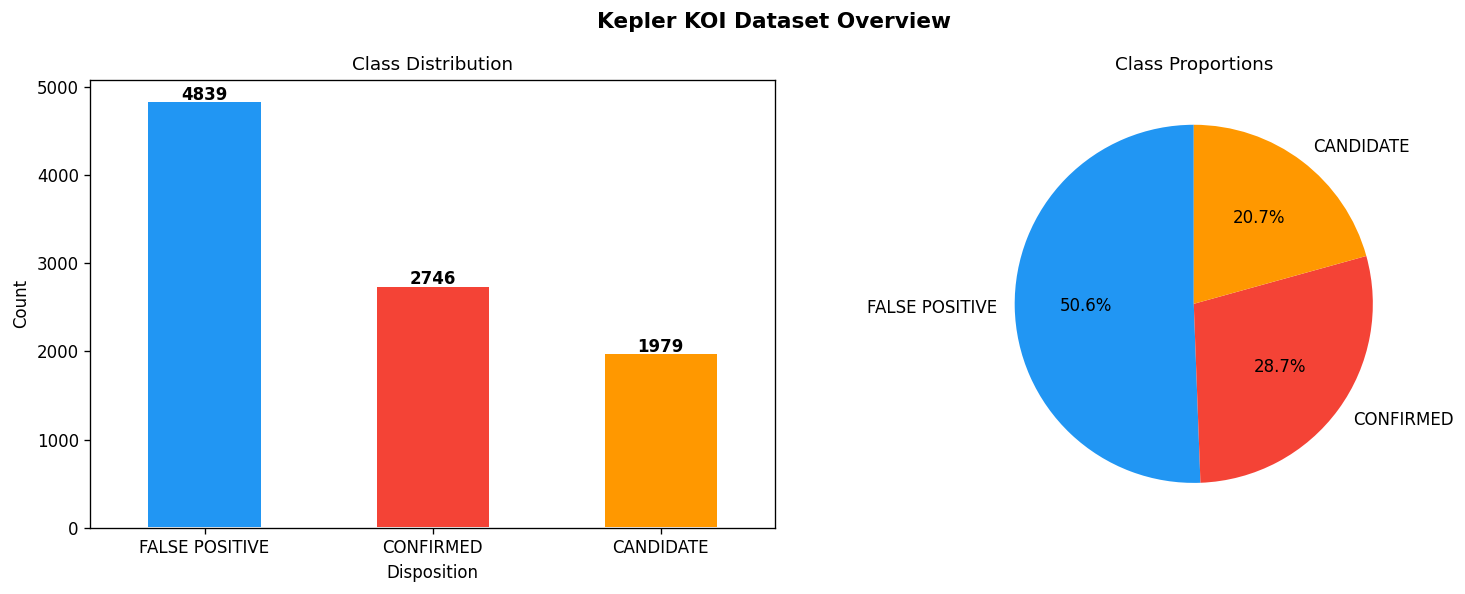

Confirmed planets : 2746
False positives   : 4839
Candidates        : 1979
Total samples     : 9564
✅ Saved dataset_overview.png


In [ ]:
# ── Step 4: Explore dataset — class distribution ──────────────────
counts = df_koi["koi_disposition"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Kepler KOI Dataset Overview", fontsize=13, fontweight="bold")

# Bar chart
colors = ["#2196F3", "#F44336", "#FF9800"]
counts.plot(kind="bar", ax=axes[0], color=colors[:len(counts)],
            edgecolor="white", linewidth=1.2)
axes[0].set_title("Class Distribution", fontsize=11)
axes[0].set_xlabel("Disposition")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(counts.index, rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold", fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors[:len(counts)],
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
axes[1].set_title("Class Proportions", fontsize=11)

plt.tight_layout()
plt.savefig("dataset_overview.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"Confirmed planets : {counts.get('CONFIRMED', 0)}")
print(f"False positives   : {counts.get('FALSE POSITIVE', 0)}")
print(f"Candidates        : {counts.get('CANDIDATE', 0)}")
print(f"Total samples     : {len(df_koi)}")
print("✅ Saved dataset_overview.png")

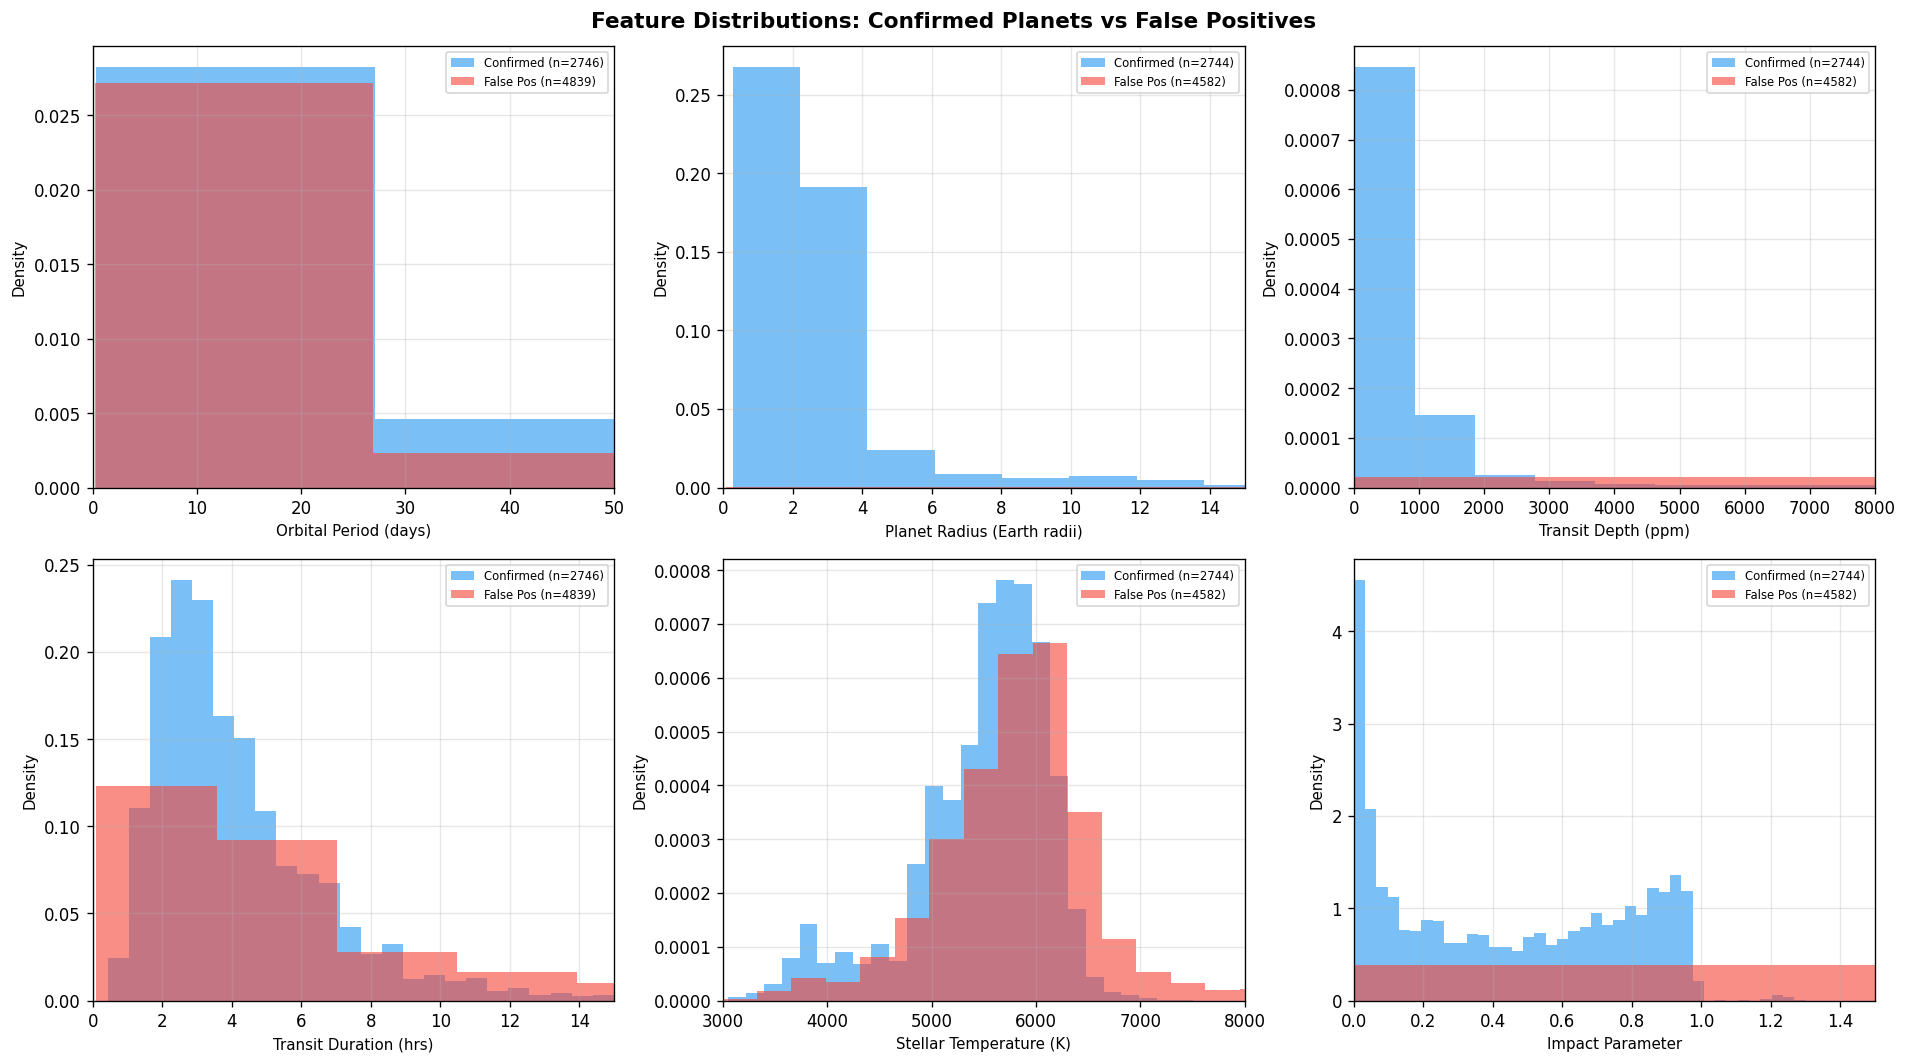

✅ Saved feature_distributions.png


In [ ]:
# ── Step 5: Feature distributions — orbital & stellar properties ──
df_c  = df_koi[df_koi["koi_disposition"] == "CONFIRMED"]
df_fp = df_koi[df_koi["koi_disposition"] == "FALSE POSITIVE"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Feature Distributions: Confirmed Planets vs False Positives",
             fontsize=13, fontweight="bold")

features = [
    ("koi_period",   "Orbital Period (days)",      (0, 50)),
    ("koi_prad",     "Planet Radius (Earth radii)", (0, 15)),
    ("koi_depth",    "Transit Depth (ppm)",         (0, 8000)),
    ("koi_duration", "Transit Duration (hrs)",      (0, 15)),
    ("koi_steff",    "Stellar Temperature (K)",     (3000, 8000)),
    ("koi_impact",   "Impact Parameter",            (0, 1.5)),
]

for ax, (col, label, xlim) in zip(axes.flat, features):
    data_c  = df_c[col].dropna()
    data_fp = df_fp[col].dropna()
    ax.hist(data_c,  bins=40, alpha=0.6, color="#2196F3",
            label=f"Confirmed (n={len(data_c)})", density=True)
    ax.hist(data_fp, bins=40, alpha=0.6, color="#F44336",
            label=f"False Pos (n={len(data_fp)})", density=True)
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.set_xlim(xlim)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved feature_distributions.png")

In [ ]:
# ── Step 6: Balance dataset with N_SAMPLE per class ──────────────
df_confirmed = df_koi[df_koi["koi_disposition"] == "CONFIRMED"].copy()
df_fp        = df_koi[df_koi["koi_disposition"] == "FALSE POSITIVE"].copy()

n_sample = min(N_SAMPLE, len(df_confirmed), len(df_fp))
df_pos = df_confirmed.sample(n=n_sample, random_state=SEED)
df_neg = df_fp.sample(n=n_sample, random_state=SEED)
df_pos["label"] = 1
df_neg["label"] = 0

df_dataset = pd.concat([df_pos, df_neg]).reset_index(drop=True)

print(f"✅ Confirmed planets sampled : {len(df_pos)}")
print(f"✅ False positives sampled   : {len(df_neg)}")
print(f"✅ Total dataset             : {len(df_dataset)}")

# Quick peek at key columns
print(df_dataset[["kepid","kepoi_name","koi_disposition",
                   "koi_period","koi_depth","label"]].head(8).to_string())

✅ Confirmed planets sampled : 2000
✅ False positives sampled   : 2000
✅ Total dataset             : 4000
      kepid kepoi_name koi_disposition  koi_period  koi_depth  label
0   6768394  K02086.02       CONFIRMED    8.919012      180.6      1
1  11444514  K04371.01       CONFIRMED   66.373298      415.0      1
2   9527334  K00049.01       CONFIRMED    8.313773      837.4      1
3  11963206  K02820.01       CONFIRMED    3.009125      191.4      1
4   4947556  K03936.02       CONFIRMED   13.026796      356.6      1
5   8073705  K03245.01       CONFIRMED   10.600521       60.9      1
6  11860395  K03445.01       CONFIRMED   82.303914      737.0      1
7   7211141  K01355.01       CONFIRMED   51.929207     3425.8      1


## Part 2 — Preprocessing Pipeline

In [ ]:
# ── Step 7: Core helper functions ────────────────────────────────

def _to_numpy(arr):
    """Safely convert AstroPy MaskedNDArray / Quantity to plain float64."""
    if hasattr(arr, "filled"):
        arr = arr.filled(np.nan)
    if hasattr(arr, "value"):
        arr = arr.value
    return np.array(arr, dtype=float)

def download_and_fold(kepler_id, period, t0, bins=BINS):
    """
    Download a Kepler light curve, flatten stellar variability,
    phase-fold at the transit period, bin to fixed length, normalise.

    Returns: numpy array of shape (bins,) or None on failure.
    """
    try:
        search = lk.search_lightcurve(
            f"KIC {int(kepler_id)}", mission="Kepler", cadence="long")
        if len(search) == 0:
            return None
        lc = search[0].download()
        if lc is None:
            return None
        lc_flat = lc.flatten(window_length=101)
        lc_fold = lc_flat.fold(period=period, epoch_time=t0)
        lc_bin  = lc_fold.bin(bins=bins)
        flux = _to_numpy(lc_bin.flux)
        flux = (flux - np.nanmedian(flux)) / (np.nanstd(flux) + 1e-8)
        if len(flux) < bins:
            flux = np.pad(flux, (0, bins - len(flux)), constant_values=0)
        else:
            flux = flux[:bins]
        return flux
    except Exception:
        return None

print("✅ _to_numpy and download_and_fold ready")

✅ _to_numpy and download_and_fold ready


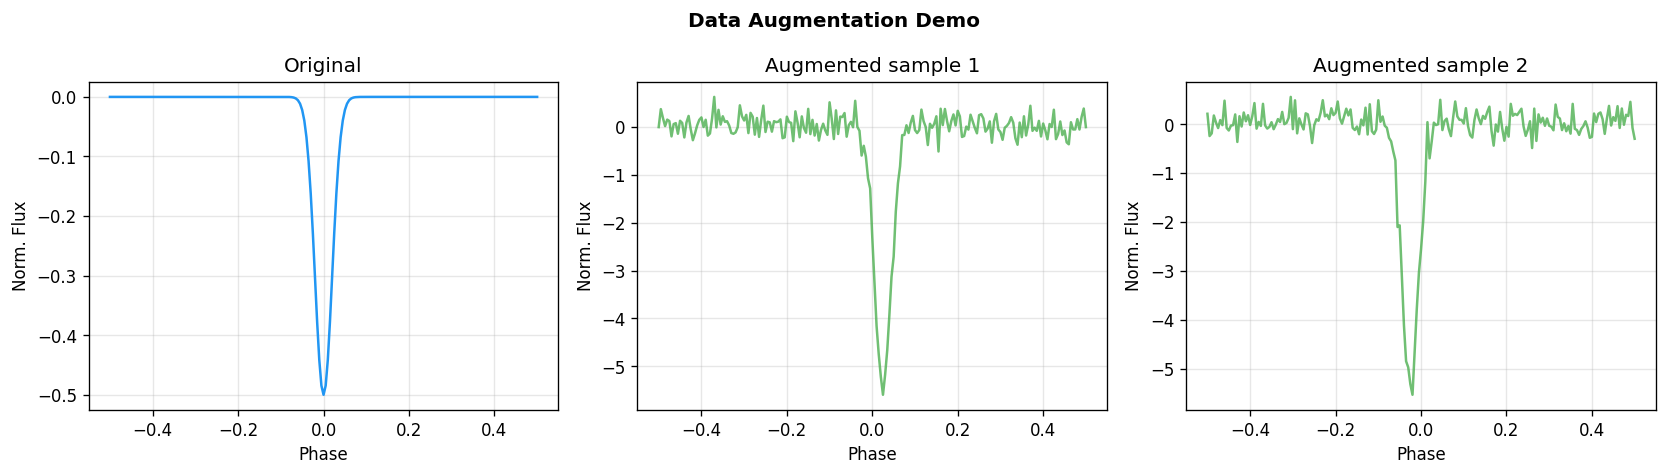

✅ Augmentation demo saved
✅ Saved augmentation_demo.png
✅ Augmentation functions ready


In [ ]:
# ── Step 8: Data augmentation functions ───────────────────────────

def augment_flux(flux, noise_std=0.02, max_shift=5, flip_prob=0.3):
    """
    Apply random augmentation to a single light curve array.
    Augmentation types:
      1. Gaussian noise  — adds realistic measurement noise
      2. Phase shift     — simulates small period estimation error
      3. Amplitude flip  — mirrors the curve (valid by symmetry)

    Args:
        flux      : (BINS,) normalised flux array
        noise_std : std of Gaussian noise to add
        max_shift : max bins to shift left/right
        flip_prob : probability of horizontal flip

    Returns:
        Augmented (BINS,) array
    """
    aug = flux.copy()

    # 1. Gaussian noise
    aug = aug + np.random.normal(0, noise_std, size=aug.shape)

    # 2. Phase shift (roll)
    shift = np.random.randint(-max_shift, max_shift + 1)
    aug = np.roll(aug, shift)

    # 3. Amplitude flip (valid: transit is symmetric in phase)
    if np.random.rand() < flip_prob:
        aug = aug[::-1]

    # Re-normalise after augmentation
    aug = (aug - np.nanmedian(aug)) / (np.nanstd(aug) + 1e-8)
    return aug.astype(np.float32)

def augment_dataset(X, y, n_augmented_per_sample=2):
    """Augment every sample n_augmented_per_sample times."""
    X_aug, y_aug = [], []
    for flux, label in zip(X, y):
        for _ in range(n_augmented_per_sample):
            X_aug.append(augment_flux(flux.flatten()))
            y_aug.append(label)
    return np.array(X_aug), np.array(y_aug)

# ── Demo: show original vs augmented ──────────────────────────────
demo_flux = np.zeros(BINS)
demo_flux -= 0.5 * np.exp(-((np.linspace(-0.5,0.5,BINS))**2) / (2*0.02**2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Data Augmentation Demo", fontsize=12, fontweight="bold")
x_ax = np.linspace(-0.5, 0.5, BINS)

axes[0].plot(x_ax, demo_flux, "#2196F3", lw=1.5)
axes[0].set_title("Original")

for i, ax in enumerate(axes[1:]):
    aug = augment_flux(demo_flux)
    ax.plot(x_ax, aug, "#4CAF50", lw=1.5, alpha=0.8)
    ax.set_title(f"Augmented sample {i+1}")

for ax in axes:
    ax.set_xlabel("Phase")
    ax.set_ylabel("Norm. Flux")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("augmentation_demo.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Augmentation demo saved")
print("✅ Saved augmentation_demo.png")
print("✅ Augmentation functions ready")

In [14]:
# ── Step 9: Build training dataset with 4-stage quality filter ────
# Saves dataset to Drive after downloading so it never downloads twice.

DATASET_PATH = f'{CHECKPOINT_DIR}/X_raw.npy'
Y_PATH       = f'{CHECKPOINT_DIR}/y_raw.npy'

# ── Check if dataset already exists on Drive ──────────────────────
if os.path.exists(DATASET_PATH) and os.path.exists(Y_PATH):
    print("✅ Found saved dataset on Drive — loading instead of downloading...")
    X_raw = np.load(DATASET_PATH)
    y_raw = np.load(Y_PATH)
    print(f"   Loaded {len(X_raw)} light curves")
    print(f"   Planets        : {int(y_raw.sum())}")
    print(f"   False Positives: {int((y_raw==0).sum())}")
    print(f"   Dataset is clean: {not np.any(np.isnan(X_raw))}")

else:
    print("No saved dataset found — downloading from NASA MAST...")
    print(f"Downloading light curves for {len(df_dataset)} KOIs...")
    print("Expected time: 15-25 min.")
    print()

    X_list, y_list = [], []
    failed       = 0
    rejected_nan = 0

    for _, row in tqdm(df_dataset.iterrows(), total=len(df_dataset)):
        flux = download_and_fold(row["kepid"], row["koi_period"], row["koi_time0bk"])

        # Filter 1: download must succeed
        if flux is None:
            failed += 1
            continue

        # Filter 2: NaN fraction must be < 10%
        if np.isnan(flux).mean() > 0.1:
            rejected_nan += 1
            continue

        # Filter 3: signal must have real variation (not flat/dead)
        if np.nanstd(flux) < 1e-4:
            rejected_nan += 1
            continue

        # Filter 4: fill any remaining isolated NaNs
        flux = np.nan_to_num(flux, nan=0.0, posinf=0.0, neginf=0.0)

        X_list.append(flux)
        y_list.append(int(row["label"]))

    # Convert to numpy arrays
    X_raw = np.array(X_list, dtype=np.float32)
    y_raw = np.array(y_list, dtype=np.float32)

    # Final NaN safety net
    X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

    print(f"\n✅ Download complete")
    print(f"   Usable light curves  : {len(X_raw)}")
    print(f"   Planets              : {int(y_raw.sum())}")
    print(f"   False Positives      : {int((y_raw==0).sum())}")
    print(f"   Download failed      : {failed}")
    print(f"   Rejected (bad data)  : {rejected_nan}")
    print(f"   Dataset is clean     : {not np.any(np.isnan(X_raw))}")

    # ── Save to Drive so next session skips download ──────────────
    np.save(DATASET_PATH, X_raw)
    np.save(Y_PATH, y_raw)
    print(f"\n💾 Dataset saved to Drive:")
    print(f"   {DATASET_PATH}")
    print(f"   {Y_PATH}")

# ── Augment dataset ───────────────────────────────────────────────
X_aug, y_aug = augment_dataset(X_raw, y_raw, n_augmented_per_sample=2)

print(f"\n✅ Augmentation complete")
print(f"   Original samples     : {len(X_raw)}")
print(f"   Augmented samples    : {len(X_aug)}")
print(f"   Total combined       : {len(X_raw) + len(X_aug)}")
print(f"   Augmented planets    : {int(y_aug.sum())}")
print(f"   Augmented false pos  : {int((y_aug==0).sum())}")
print(f"   Dataset is clean     : {not np.any(np.isnan(X_aug))}")

No saved dataset found — downloading from NASA MAST...
Expected time: 15-25 min.



  0%|          | 0/4000 [00:00<?, ?it/s]


✅ Download complete
   Usable light curves  : 3575
   Planets              : 1770
   False Positives      : 1805
   Download failed      : 0
   Rejected (bad data)  : 425
   Dataset is clean     : True

💾 Dataset saved to Drive:
   /content/drive/MyDrive/exoplanet_checkpoints/X_raw.npy
   /content/drive/MyDrive/exoplanet_checkpoints/y_raw.npy

✅ Augmentation complete
   Original samples     : 3575
   Augmented samples    : 7150
   Total combined       : 10725
   Augmented planets    : 3540
   Augmented false pos  : 3610
   Dataset is clean     : True


In [15]:
  # ── Cell A: NaN Audit — missing value rates across the dataset ────
nan_rates_raw = np.isnan(X_raw).mean(axis=1)

print("="*50)
print("  NaN AUDIT — Raw Downloaded Dataset")
print("="*50)
print(f"  Total samples         : {len(X_raw)}")
print(f"  Samples with ANY NaN  : {int((nan_rates_raw > 0).sum())}")
print(f"  Samples >10% NaN      : {int((nan_rates_raw > 0.1).sum())}  <- would be rejected")
print(f"  Mean NaN rate         : {nan_rates_raw.mean():.4%}")
print(f"  Max NaN rate          : {nan_rates_raw.max():.4%}")
print(f"  Min NaN rate          : {nan_rates_raw.min():.4%}")
print()
print("After np.nan_to_num (final safety net):")
X_check = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
print(f"  Remaining NaNs        : {int(np.isnan(X_check).sum())}")
print(f"  Remaining Infs        : {int(np.isinf(X_check).sum())}")
print(f"  Dataset is clean      : {not np.any(np.isnan(X_check)) and not np.any(np.isinf(X_check))}")
print("="*50)


  NaN AUDIT — Raw Downloaded Dataset
  Total samples         : 3575
  Samples with ANY NaN  : 0
  Samples >10% NaN      : 0  <- would be rejected
  Mean NaN rate         : 0.0000%
  Max NaN rate          : 0.0000%
  Min NaN rate          : 0.0000%

After np.nan_to_num (final safety net):
  Remaining NaNs        : 0
  Remaining Infs        : 0
  Dataset is clean      : True


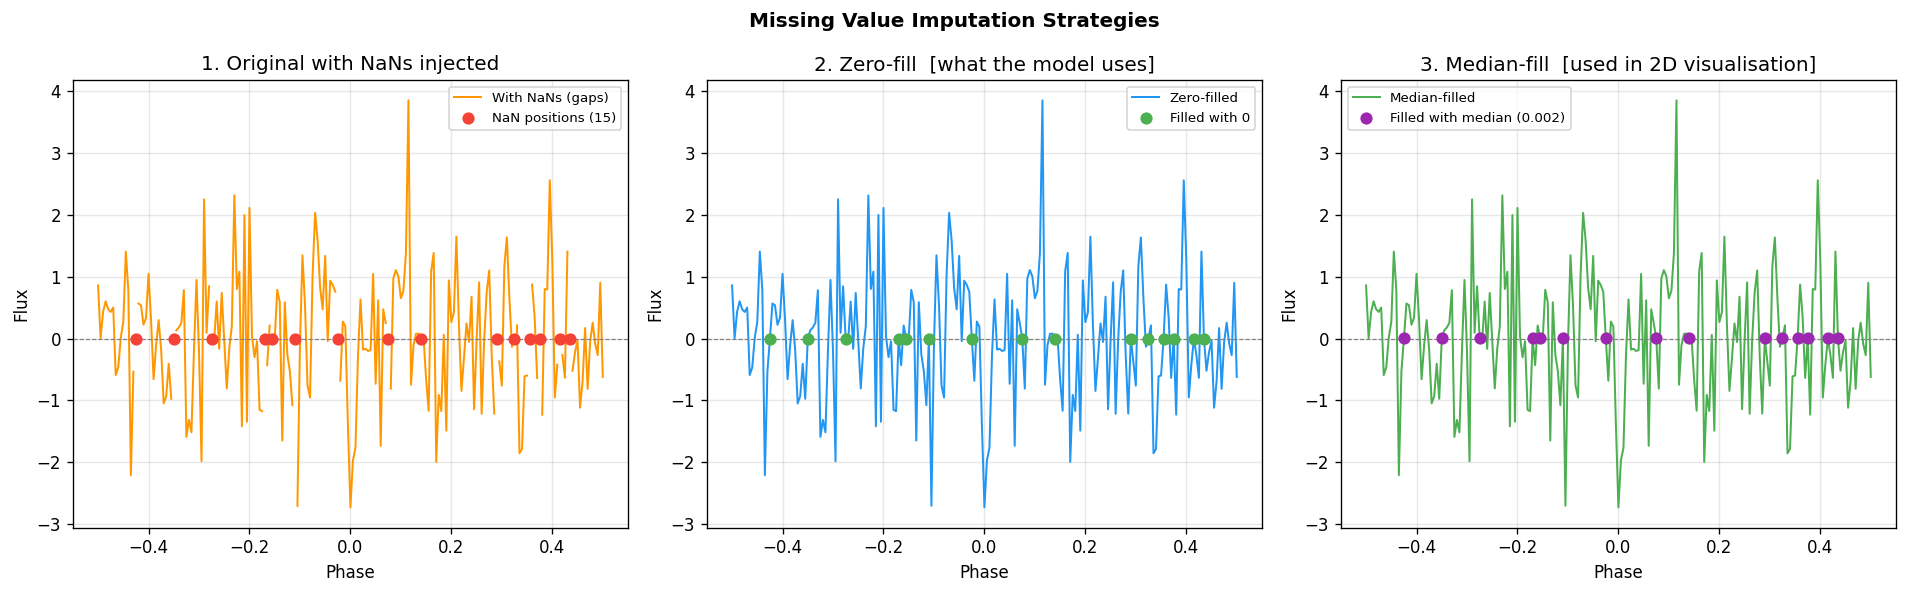

NaNs injected      : 15
Zero-fill NaNs left: 0
Median-fill NaNs   : 0
Median value used  : 0.0022
Dataset is clean   : True
✅ Saved imputation_comparison.png


In [16]:
# ── Cell C: Before vs After — zero-fill vs median-fill ───────────
sample_idx = 0
flux_orig  = X_raw[sample_idx].copy()
flux_dirty = flux_orig.copy()

np.random.seed(SEED)
nan_pos = np.random.choice(len(flux_dirty), size=15, replace=False)
flux_dirty[nan_pos] = np.nan

flux_zerofill = np.nan_to_num(flux_dirty, nan=0.0)
median_val    = float(np.nanmedian(flux_dirty))
flux_medfill  = np.where(np.isfinite(flux_dirty), flux_dirty, median_val)

x_ax = np.linspace(-0.5, 0.5, len(flux_orig))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Missing Value Imputation Strategies', fontsize=12, fontweight='bold')

axes[0].plot(x_ax, flux_dirty, '#FF9800', lw=1.2, label='With NaNs (gaps)')
axes[0].scatter(x_ax[nan_pos], np.zeros(len(nan_pos)),
                color='#F44336', s=40, zorder=5,
                label=f'NaN positions ({len(nan_pos)})')
axes[0].axhline(0, color='gray', linestyle='--', lw=0.7)
axes[0].set_title('1. Original with NaNs injected')
axes[0].legend(fontsize=8)
axes[0].set_xlabel('Phase')
axes[0].set_ylabel('Flux')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_ax, flux_zerofill, '#2196F3', lw=1.2, label='Zero-filled')
axes[1].scatter(x_ax[nan_pos], np.zeros(len(nan_pos)),
                color='#4CAF50', s=40, zorder=5, label='Filled with 0')
axes[1].axhline(0, color='gray', linestyle='--', lw=0.7)
axes[1].set_title('2. Zero-fill  [what the model uses]')
axes[1].legend(fontsize=8)
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Flux')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_ax, flux_medfill, '#4CAF50', lw=1.2, label='Median-filled')
axes[2].scatter(x_ax[nan_pos], np.full(len(nan_pos), median_val),
                color='#9C27B0', s=40, zorder=5,
                label=f'Filled with median ({median_val:.3f})')
axes[2].axhline(0, color='gray', linestyle='--', lw=0.7)
axes[2].set_title('3. Median-fill  [used in 2D visualisation]')
axes[2].legend(fontsize=8)
axes[2].set_xlabel('Phase')
axes[2].set_ylabel('Flux')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('imputation_comparison.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'NaNs injected      : {len(nan_pos)}')
print(f'Zero-fill NaNs left: {int(np.isnan(flux_zerofill).sum())}')
print(f'Median-fill NaNs   : {int(np.isnan(flux_medfill).sum())}')
print(f'Median value used  : {median_val:.4f}')
print(f'Dataset is clean   : {not np.any(np.isnan(flux_zerofill))}')
print('✅ Saved imputation_comparison.png')

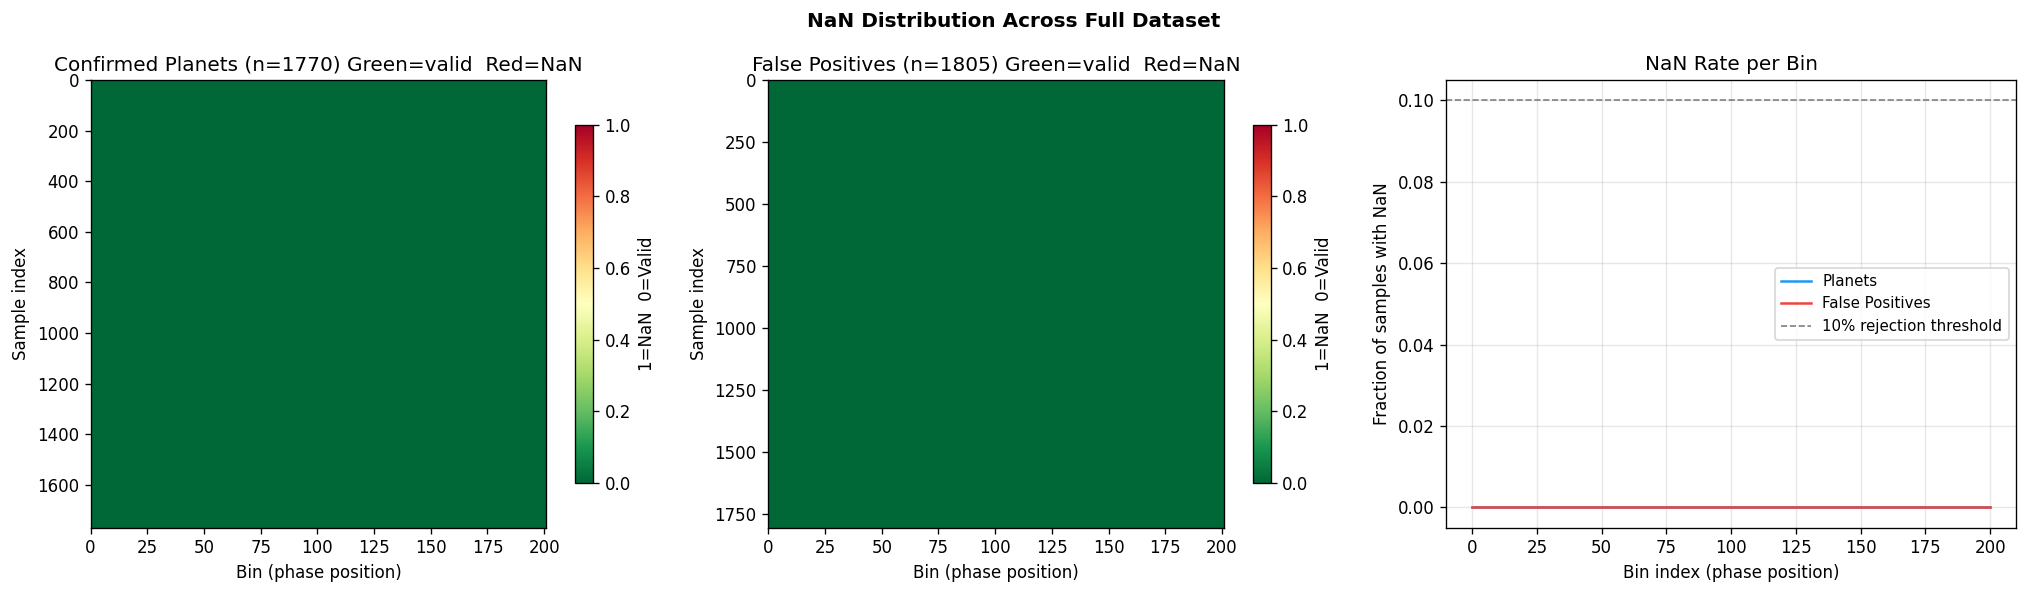

Total values in dataset : 718,575
Total NaNs remaining    : 0  (0.0000%)
Dataset is fully clean  : True
✅ Saved nan_heatmap.png


In [18]:
# ── Cell D: NaN heatmap across full dataset ───────────────────────
nan_matrix_p  = np.isnan(X_raw[y_raw == 1])
nan_matrix_fp = np.isnan(X_raw[y_raw == 0])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('NaN Distribution Across Full Dataset', fontsize=12, fontweight='bold')

im1 = axes[0].imshow(nan_matrix_p.astype(float), aspect='auto',
                      cmap='RdYlGn_r', vmin=0, vmax=1,
                      extent=[0, BINS, len(nan_matrix_p), 0])
plt.colorbar(im1, ax=axes[0], shrink=0.8, label='1=NaN  0=Valid')
axes[0].set_title(f'Confirmed Planets (n={len(nan_matrix_p)}) Green=valid  Red=NaN')
axes[0].set_xlabel('Bin (phase position)')
axes[0].set_ylabel('Sample index')

im2 = axes[1].imshow(nan_matrix_fp.astype(float), aspect='auto',
                      cmap='RdYlGn_r', vmin=0, vmax=1,
                      extent=[0, BINS, len(nan_matrix_fp), 0])
plt.colorbar(im2, ax=axes[1], shrink=0.8, label='1=NaN  0=Valid')
axes[1].set_title(f'False Positives (n={len(nan_matrix_fp)}) Green=valid  Red=NaN')
axes[1].set_xlabel('Bin (phase position)')
axes[1].set_ylabel('Sample index')

nan_per_bin_p  = nan_matrix_p.mean(axis=0)
nan_per_bin_fp = nan_matrix_fp.mean(axis=0)
axes[2].plot(np.arange(BINS), nan_per_bin_p,  '#2196F3', lw=1.5, label='Planets')
axes[2].plot(np.arange(BINS), nan_per_bin_fp, '#F44336', lw=1.5, label='False Positives')
axes[2].axhline(0.1, color='gray', linestyle='--', lw=1, label='10% rejection threshold')
axes[2].set_title('NaN Rate per Bin')
axes[2].set_xlabel('Bin index (phase position)')
axes[2].set_ylabel('Fraction of samples with NaN')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nan_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

total_nans = int(np.isnan(X_raw).sum())
total_vals = int(X_raw.size)
print(f'Total values in dataset : {total_vals:,}')
print(f'Total NaNs remaining    : {total_nans:,}  ({total_nans/total_vals:.4%})')
print(f'Dataset is fully clean  : {total_nans == 0}')
print('✅ Saved nan_heatmap.png')

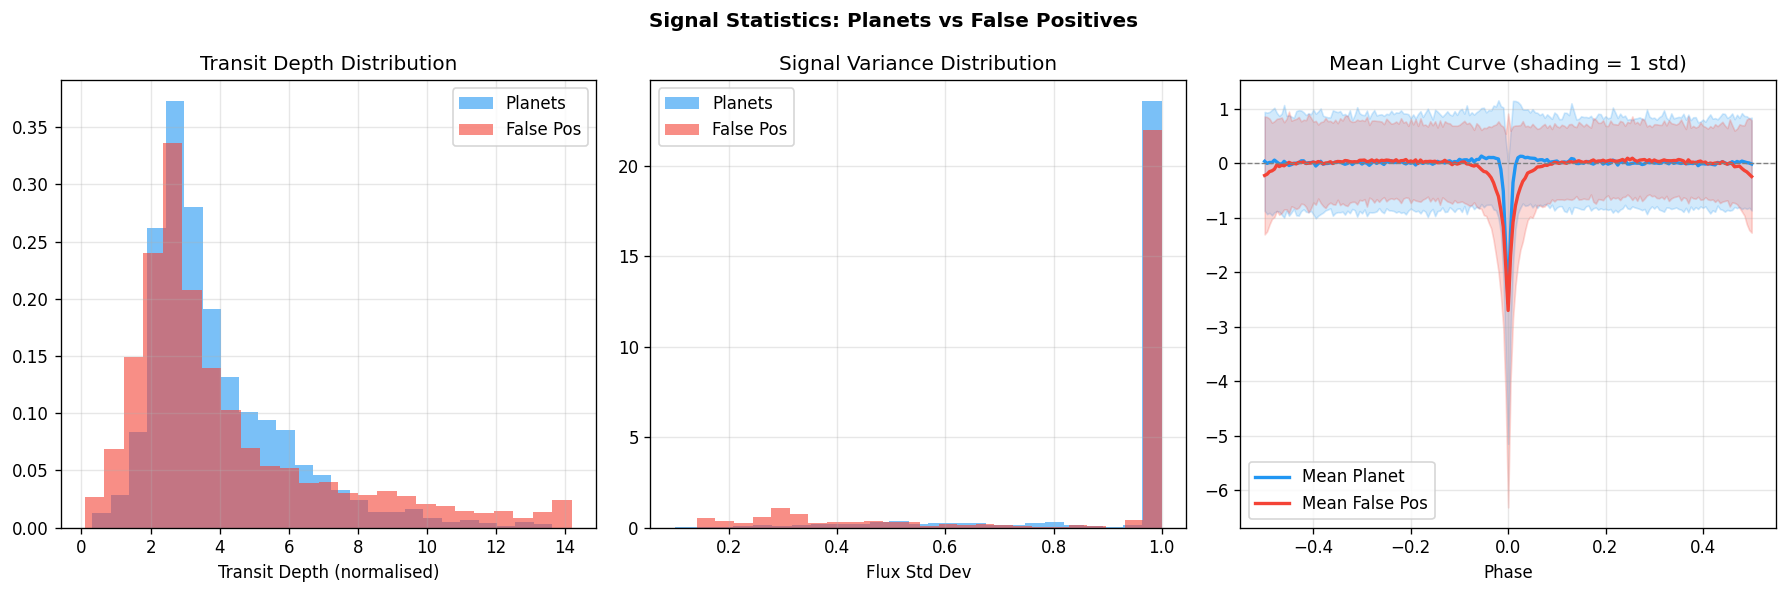

✅ Saved signal_statistics.png


In [19]:
# ── Step 10: Signal statistics analysis ──────────────────────────
planet_X = X_raw[y_raw == 1]
fp_X     = X_raw[y_raw == 0]

# Compute per-sample transit depth (max dip below baseline)
def transit_depth(flux):
    baseline = np.median(flux[np.abs(np.linspace(-0.5,0.5,BINS)) > 0.2])
    return max(0.0, float(baseline - flux.min()))

depths_p  = np.array([transit_depth(f) for f in planet_X])
depths_fp = np.array([transit_depth(f) for f in fp_X])
stds_p    = planet_X.std(axis=1)
stds_fp   = fp_X.std(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Signal Statistics: Planets vs False Positives", fontsize=12, fontweight="bold")

axes[0].hist(depths_p,  bins=25, alpha=0.6, color="#2196F3",
             label="Planets", density=True)
axes[0].hist(depths_fp, bins=25, alpha=0.6, color="#F44336",
             label="False Pos", density=True)
axes[0].set_xlabel("Transit Depth (normalised)")
axes[0].set_title("Transit Depth Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(stds_p,  bins=25, alpha=0.6, color="#2196F3",
             label="Planets", density=True)
axes[1].hist(stds_fp, bins=25, alpha=0.6, color="#F44336",
             label="False Pos", density=True)
axes[1].set_xlabel("Flux Std Dev")
axes[1].set_title("Signal Variance Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Mean profiles
mean_planet = planet_X.mean(axis=0)
mean_fp     = fp_X.mean(axis=0)
std_planet  = planet_X.std(axis=0)
std_fp      = fp_X.std(axis=0)
x_ax        = np.linspace(-0.5, 0.5, BINS)

axes[2].plot(x_ax, mean_planet, "#2196F3", lw=2, label="Mean Planet")
axes[2].fill_between(x_ax, mean_planet-std_planet, mean_planet+std_planet,
                     alpha=0.2, color="#2196F3")
axes[2].plot(x_ax, mean_fp, "#F44336", lw=2, label="Mean False Pos")
axes[2].fill_between(x_ax, mean_fp-std_fp, mean_fp+std_fp,
                     alpha=0.2, color="#F44336")
axes[2].axhline(0, color="gray", linestyle="--", lw=0.8)
axes[2].set_xlabel("Phase")
axes[2].set_title("Mean Light Curve (shading = 1 std)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("signal_statistics.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved signal_statistics.png")

## Part 3 — 1D Light Curve Visualization

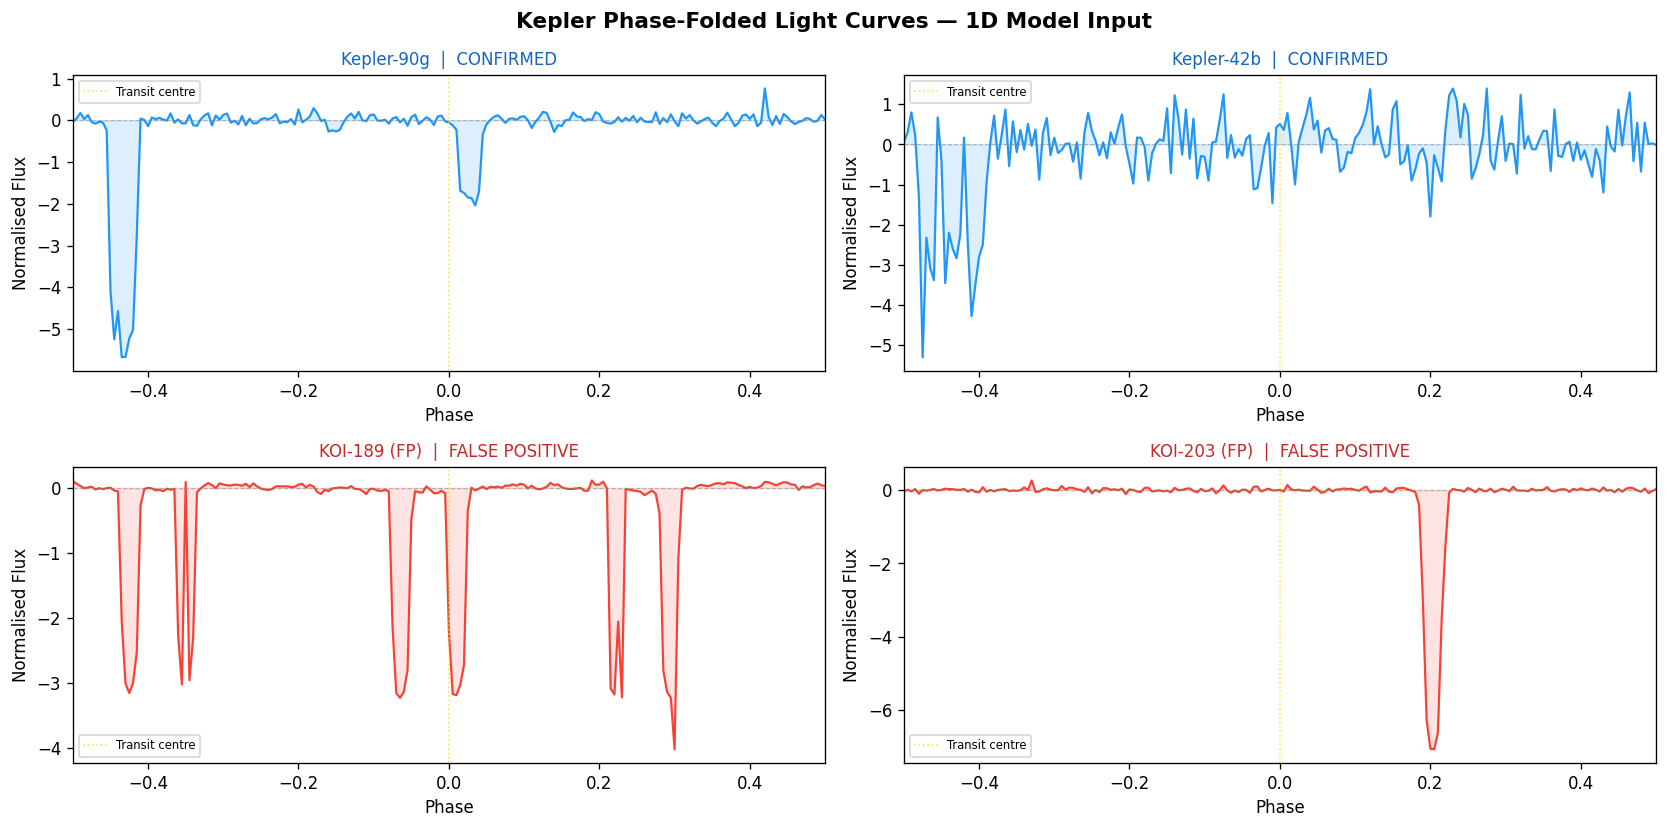

✅ Saved lightcurve_1d_examples.png


In [20]:
# ── Step 11: 1D phase-folded examples ────────────────────────────
examples = [
    (11442793, 14.44912, 2.2,  "CONFIRMED",      "Kepler-90g"),
    (3544595,   4.88780, 0.5,  "CONFIRMED",      "Kepler-42b"),
    (9941662,   4.9278,  1.2,  "FALSE POSITIVE", "KOI-189 (FP)"),
    (5358624,   3.521,   0.3,  "FALSE POSITIVE", "KOI-203 (FP)"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Kepler Phase-Folded Light Curves — 1D Model Input",
             fontsize=13, fontweight="bold")
x_axis = np.linspace(-0.5, 0.5, BINS)

for i, (kid, period, t0, disposition, name) in enumerate(examples):
    ax   = axes[i // 2][i % 2]
    flux = download_and_fold(kid, period, t0)
    color = "#2196F3" if disposition == "CONFIRMED" else "#F44336"
    if flux is not None:
        ax.plot(x_axis, flux, color=color, linewidth=1.3)
        ax.fill_between(x_axis, flux, alpha=0.15, color=color)
        ax.axhline(0, color="gray", linestyle="--", lw=0.7, alpha=0.5)
        ax.axvline(0, color="gold", linestyle=":", lw=1, alpha=0.7,
                   label="Transit centre")
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "Download failed", ha="center", va="center",
                transform=ax.transAxes, color="gray")
    ax.set_title(f"{name}  |  {disposition}", fontsize=10,
                 color="#1565C0" if disposition == "CONFIRMED" else "#C62828")
    ax.set_xlabel("Phase")
    ax.set_ylabel("Normalised Flux")
    ax.set_xlim(-0.5, 0.5)

plt.tight_layout()
plt.savefig("lightcurve_1d_examples.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved lightcurve_1d_examples.png")

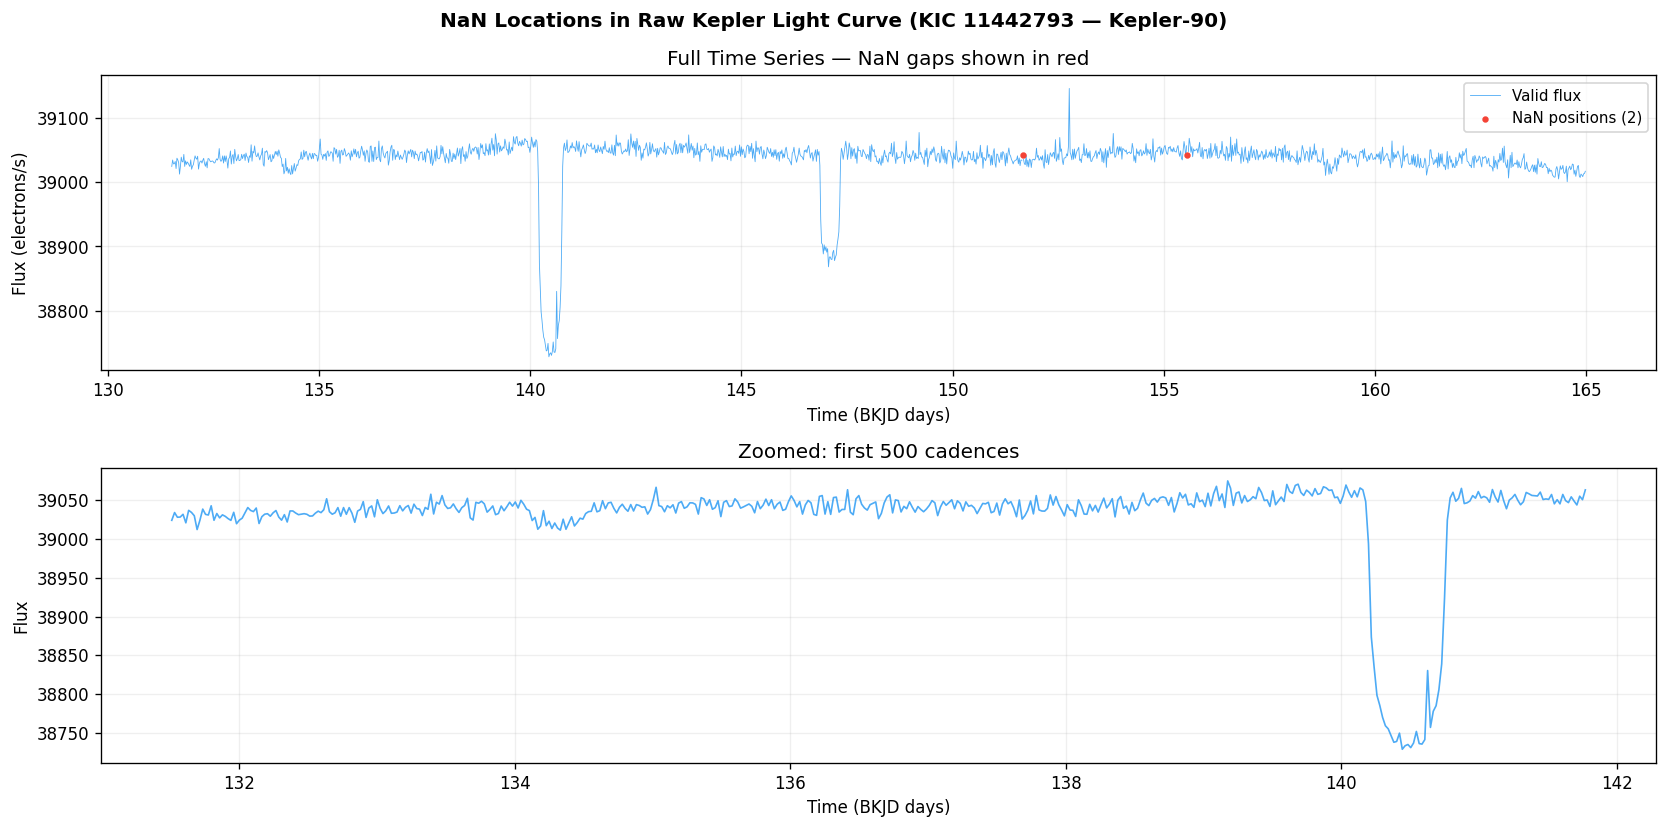

Total cadences : 1626
NaN cadences   : 2  (0.12%)
Valid cadences : 1624  (99.88%)
✅ Saved nan_locations.png


In [21]:
# ── Cell B: NaN locations in a raw Kepler light curve ────────────
search   = lk.search_lightcurve('KIC 11442793', mission='Kepler', cadence='long')
lc_raw_b = search[0].download()

time_arr = np.array(lc_raw_b.time.value, dtype=float)
flux_arr = np.array(lc_raw_b.flux.value, dtype=float)
nan_mask = np.isnan(flux_arr)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('NaN Locations in Raw Kepler Light Curve (KIC 11442793 — Kepler-90)',
             fontsize=12, fontweight='bold')

axes[0].plot(time_arr, flux_arr, '#2196F3', lw=0.5, alpha=0.8, label='Valid flux')
axes[0].scatter(time_arr[nan_mask],
                np.full(int(nan_mask.sum()), np.nanmedian(flux_arr)),
                color='#F44336', s=8, zorder=5,
                label=f'NaN positions ({int(nan_mask.sum())})')
axes[0].set_title('Full Time Series — NaN gaps shown in red')
axes[0].set_xlabel('Time (BKJD days)')
axes[0].set_ylabel('Flux (electrons/s)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.2)

n_show = 500
axes[1].plot(time_arr[:n_show], flux_arr[:n_show], '#2196F3', lw=1, alpha=0.8)
nan_w = nan_mask[:n_show]
if int(nan_w.sum()) > 0:
    axes[1].scatter(time_arr[:n_show][nan_w],
                    np.full(int(nan_w.sum()), np.nanmedian(flux_arr)),
                    color='#F44336', s=20, zorder=5, label='NaN')
    axes[1].legend(fontsize=9)
axes[1].set_title(f'Zoomed: first {n_show} cadences')
axes[1].set_xlabel('Time (BKJD days)')
axes[1].set_ylabel('Flux')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('nan_locations.png', bbox_inches='tight', dpi=120)
plt.show()
print(f'Total cadences : {len(flux_arr)}')
print(f'NaN cadences   : {int(nan_mask.sum())}  ({float(nan_mask.mean()):.2%})')
print(f'Valid cadences : {int((~nan_mask).sum())}  ({float((~nan_mask).mean()):.2%})')
print('✅ Saved nan_locations.png')

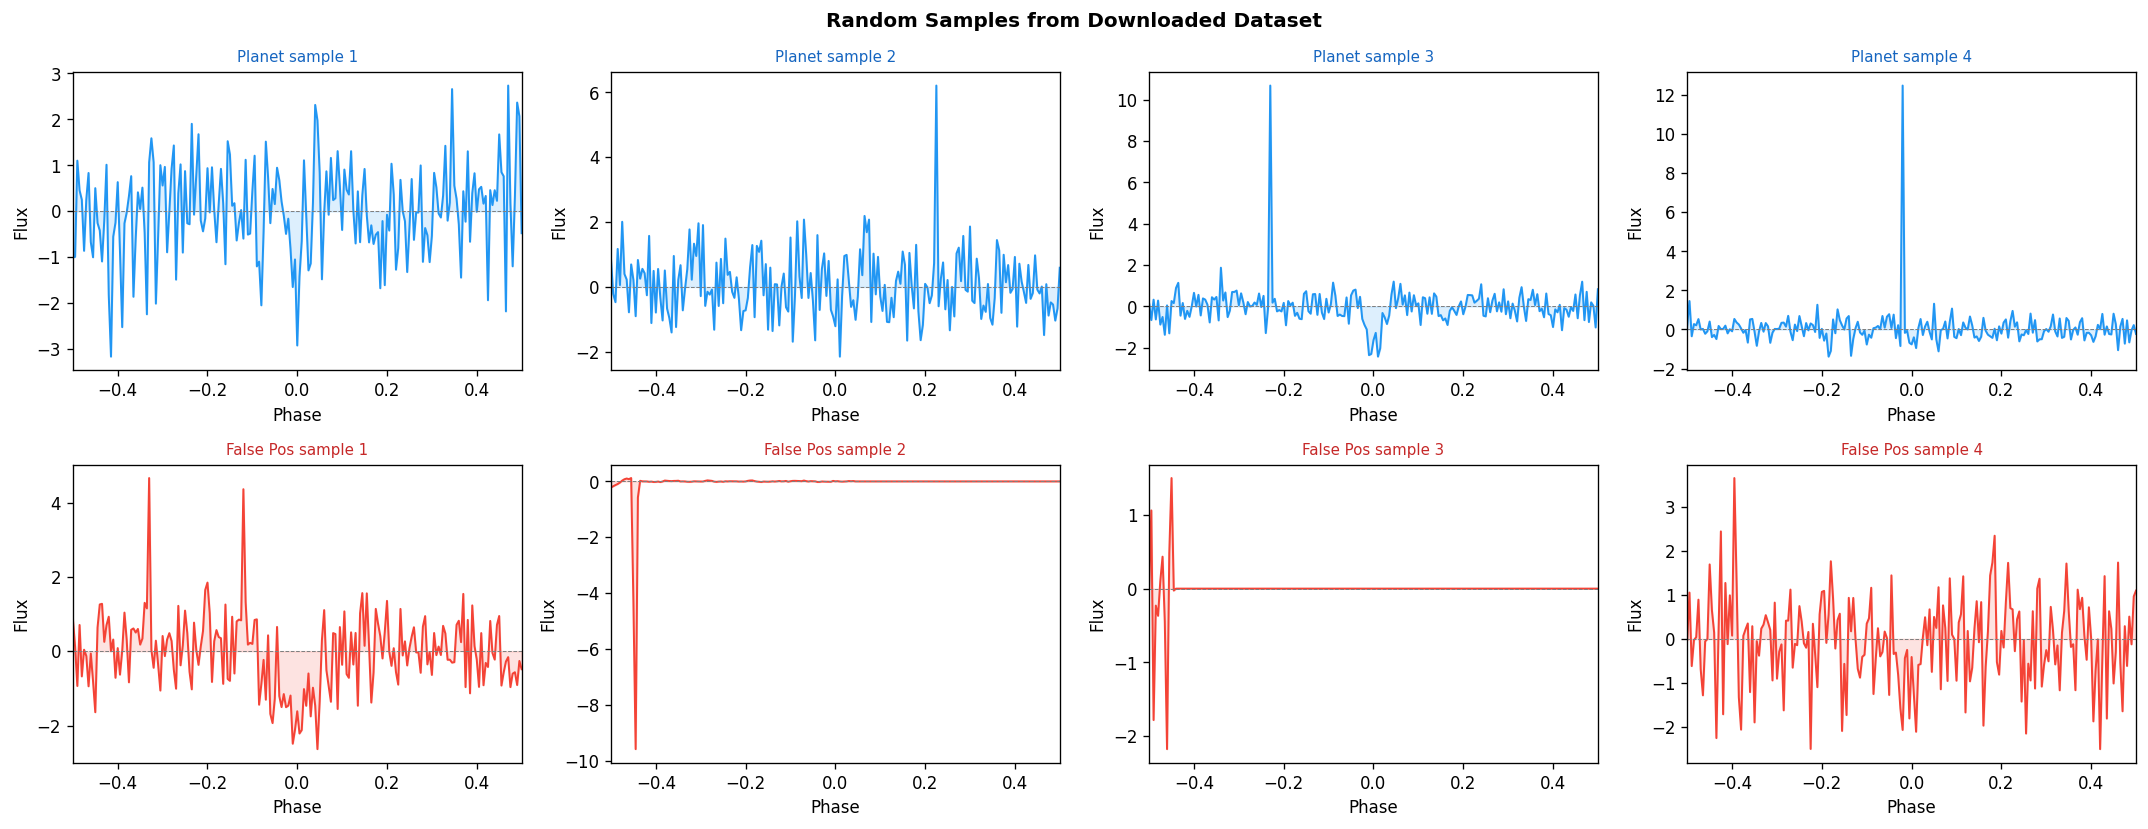

✅ Saved dataset_samples_1d.png


In [22]:
# ── Step 12: Distribution of real dataset samples (1D) ───────────
np.random.seed(SEED)
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle("Random Samples from Downloaded Dataset",
             fontsize=12, fontweight="bold")
x_axis = np.linspace(-0.5, 0.5, BINS)

planet_idx = np.where(y_raw == 1)[0]
fp_idx     = np.where(y_raw == 0)[0]

for i in range(4):
    # Row 0: confirmed planets
    ax   = axes[0][i]
    idx  = np.random.choice(planet_idx)
    flux = X_raw[idx]
    ax.plot(x_axis, flux, "#2196F3", lw=1.2)
    ax.fill_between(x_axis, flux, alpha=0.15, color="#2196F3")
    ax.axhline(0, color="gray", linestyle="--", lw=0.6)
    ax.set_title(f"Planet sample {i+1}", fontsize=9, color="#1565C0")
    ax.set_xlim(-0.5, 0.5)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")

    # Row 1: false positives
    ax   = axes[1][i]
    idx  = np.random.choice(fp_idx)
    flux = X_raw[idx]
    ax.plot(x_axis, flux, "#F44336", lw=1.2)
    ax.fill_between(x_axis, flux, alpha=0.15, color="#F44336")
    ax.axhline(0, color="gray", linestyle="--", lw=0.6)
    ax.set_title(f"False Pos sample {i+1}", fontsize=9, color="#C62828")
    ax.set_xlim(-0.5, 0.5)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.savefig("dataset_samples_1d.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved dataset_samples_1d.png")

## Part 4 — 2D Visual Analysis

Converting 1D flux arrays into 2D representations reveals spatial patterns
the CNN learns to detect:
- **Transit Heatmap**: each row = one orbital cycle; real planets show a clean vertical stripe at phase=0
- **Phase Spectrogram**: frequency content; real transits have a strong periodic signal
- **Transit Window Stack**: zoomed 2D view of the transit region stacked 20 times
- **Depth Profile**: the exact dip shape the CNN classifies

In [23]:
# ── Step 13: 2D analysis functions (MaskedNDArray-safe) ──────────

def plot_2d_views(kepler_id, period, t0, name, disposition):
    """Full 7-panel 2D analysis of a single Kepler light curve."""
    try:
        search = lk.search_lightcurve(
            f"KIC {int(kepler_id)}", mission="Kepler", cadence="long")
        if len(search) == 0:
            print(f"  Not found: {name}")
            return
        lc      = search[0].download()
        lc_flat = lc.flatten(window_length=101)
    except Exception as e:
        print(f"  Download failed: {name} ({e})")
        return

    lc_fold = lc_flat.fold(period=period, epoch_time=t0)
    lc_bin  = lc_fold.bin(bins=201)

    # Safe conversion — fixes AstroPy MaskedNDArray TypeError
    lc_bin_flux   = _to_numpy(lc_bin.flux)
    lc_bin_phase  = _to_numpy(lc_bin.phase)
    lc_fold_flux  = _to_numpy(lc_fold.flux)
    lc_fold_phase = _to_numpy(lc_fold.phase)
    lc_flat_time  = _to_numpy(lc_flat.time)
    lc_flat_flux  = _to_numpy(lc_flat.flux)

    _med = np.nanmedian(lc_bin_flux[np.isfinite(lc_bin_flux)]) if np.any(np.isfinite(lc_bin_flux)) else 1.0
    lc_bin_flux  = np.where(np.isfinite(lc_bin_flux),  lc_bin_flux,  _med)
    lc_bin_phase = np.where(np.isfinite(lc_bin_phase), lc_bin_phase, 0.0)

    color       = "#2196F3" if disposition == "CONFIRMED" else "#F44336"
    label_color = "#1565C0" if disposition == "CONFIRMED" else "#C62828"

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(f"{name}  |  {disposition}  |  Period: {period:.4f} d",
                 fontsize=14, fontweight="bold", color=label_color)

    # Panel 1: raw 1D time series
    ax1 = fig.add_subplot(3, 3, (1, 3))
    ax1.plot(lc_flat_time, lc_flat_flux, color=color, lw=0.4, alpha=0.7)
    ax1.set_title("1D Flattened Light Curve (full time series)", fontsize=10)
    ax1.set_xlabel("Time (BKJD days)")
    ax1.set_ylabel("Normalised Flux")
    ax1.grid(True, alpha=0.2)

    # Panel 2: phase-folded 1D
    ax2 = fig.add_subplot(3, 3, 4)
    ax2.plot(lc_fold_phase, lc_fold_flux, ".", color=color, alpha=0.2, ms=1.5)
    line_color = "white" if disposition == "CONFIRMED" else "#FF8A80"
    ax2.plot(lc_bin_phase, lc_bin_flux, color=line_color, lw=2, zorder=5)
    ax2.set_facecolor("#0D1117")
    ax2.set_title("1D Phase-Folded (model input — 201 pts)", fontsize=9)
    ax2.set_xlabel("Phase")
    ax2.set_ylabel("Flux")
    ax2.set_xlim(-0.5, 0.5)
    ax2.grid(True, alpha=0.2, color="gray")

    # Panel 3: 2D transit heatmap
    HBINS = 100
    NCYC  = 15
    pbins = np.linspace(-0.5, 0.5, HBINS)
    phase_arr = ((lc_flat_time - t0) / period) % 1.0
    phase_arr[phase_arr > 0.5] -= 1.0
    cycle_num = np.floor((lc_flat_time - t0) / period).astype(int)
    cycle_num -= cycle_num.min()
    n_act = min(NCYC, int(cycle_num.max()) + 1)
    heatmap = np.full((n_act, HBINS), np.nan)
    for c in range(n_act):
        mask = cycle_num == c
        if int(mask.sum()) < 5:
            continue
        ph = phase_arr[mask]
        fl = lc_flat_flux[mask]
        for b in range(HBINS - 1):
            ib = (ph >= pbins[b]) & (ph < pbins[b+1])
            if int(ib.sum()) > 0:
                heatmap[c, b] = np.nanmedian(fl[ib])
    rm = np.nanmedian(heatmap, axis=1, keepdims=True)
    heatmap[np.isnan(heatmap)] = np.broadcast_to(rm, heatmap.shape)[np.isnan(heatmap)]
    ax3 = fig.add_subplot(3, 3, 5)
    im = ax3.imshow(heatmap, aspect="auto", cmap="RdBu_r",
                    extent=[-0.5, 0.5, float(n_act), 0],
                    vmin=np.nanpercentile(heatmap, 2),
                    vmax=np.nanpercentile(heatmap, 98))
    plt.colorbar(im, ax=ax3, shrink=0.8, label="Flux")
    ax3.axvline(0, color="yellow", lw=1.5, linestyle="--", alpha=0.8)
    ax3.set_title("2D Transit Heatmap (each row = 1 cycle)", fontsize=9)
    ax3.set_xlabel("Phase")
    ax3.set_ylabel("Cycle #")

    # Panel 4: phase spectrogram
    ax4 = fig.add_subplot(3, 3, 6)
    ff  = lc_bin_flux.copy()
    tld = np.tile(ff, 20)
    fs, ts, Sxx = scipy_signal.spectrogram(tld, fs=201, nperseg=64, noverlap=48)
    ax4.pcolormesh(ts, fs[:20], 10*np.log10(Sxx[:20]+1e-10),
                   cmap="plasma", shading="gouraud")
    ax4.set_title("2D Phase Spectrogram", fontsize=9)
    ax4.set_xlabel("Time (phase cycles)")
    ax4.set_ylabel("Frequency")
    ax4.set_ylim(0, 15)

    # Panel 5: zoomed 2D transit window stack
    ax5   = fig.add_subplot(3, 3, 7)
    zmask = np.abs(lc_fold_phase) < 0.15
    zph   = lc_fold_phase[zmask]
    zfl   = lc_fold_flux[zmask]
    zfl   = np.where(np.isfinite(zfl), zfl,
                     np.nanmedian(zfl[np.isfinite(zfl)]) if np.any(np.isfinite(zfl)) else 0.0)
    ZB, ZR = 50, 20
    zpb    = np.linspace(-0.15, 0.15, ZB)
    zimag  = np.full((ZR, ZB), np.nan)
    for r in range(ZR):
        jit = np.random.normal(0, 0.001, len(zph))
        for b in range(ZB-1):
            ib = ((zph+jit) >= zpb[b]) & ((zph+jit) < zpb[b+1])
            if int(ib.sum()) > 0:
                zimag[r,b] = np.nanmedian(zfl[ib])
    _zmed = float(np.nanmedian(zimag[np.isfinite(zimag)])) if np.any(np.isfinite(zimag)) else 0.0
    zimag = np.where(np.isfinite(zimag), zimag, _zmed)
    im5 = ax5.imshow(zimag, aspect="auto", cmap="coolwarm",
                     extent=[-0.15,0.15,ZR,0])
    plt.colorbar(im5, ax=ax5, shrink=0.8, label="Flux")
    ax5.axvline(0, color="yellow", lw=1.5, linestyle="--", alpha=0.8)
    ax5.set_title("2D Transit Window Stack (zoomed)", fontsize=9)
    ax5.set_xlabel("Phase (zoomed)")
    ax5.set_ylabel("Stacked rows")

    # Panel 6: transit depth profile
    ax6 = fig.add_subplot(3, 3, 8)
    bline = np.nanmedian(lc_bin_flux[np.abs(lc_bin_phase) > 0.2])
    depth = bline - lc_bin_flux
    ax6.fill_between(lc_bin_phase, 0, depth, where=(depth>0),
                     color=color, alpha=0.6, label="Transit dip")
    ax6.fill_between(lc_bin_phase, depth, 0, where=(depth<0),
                     color="gray", alpha=0.3, label="Noise")
    ax6.axhline(0, color="gray", linestyle="--", lw=0.8)
    ax6.set_title("Transit Depth Profile", fontsize=9)
    ax6.set_xlabel("Phase")
    ax6.set_ylabel("Depth")
    ax6.set_xlim(-0.5, 0.5)
    ax6.legend(fontsize=7)
    ax6.grid(True, alpha=0.3)

    # Panel 7: annotation
    ax7 = fig.add_subplot(3, 3, 9)
    ax7.axis("off")
    tdepth = float(np.nanmax(depth)) if np.nanmax(depth) > 0 else 0.0
    txt = (
        f"Star: {name}"
        f"Disposition: {disposition}"
        f"Period: {period:.4f} days"
        f"Transit depth: {tdepth:.5f}"
        "--- What model sees ---"
        "Input: 201-pt flux array"
        "Shape: (201, 1) tensor"
        "Feature: dip at phase=0"
        "--- 2D panels ---"
        "Heatmap: repeating stripe"
        "Spectrogram: periodic freq"
        "Stack: consistent dip"
    )
    ax7.text(0.05, 0.95, txt, transform=ax7.transAxes,
             fontsize=8.5, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="#E3F2FD", alpha=0.8))

    plt.tight_layout()
    fname = f"2d_{name.replace(' ','_')}.png"
    plt.savefig(fname, bbox_inches="tight", dpi=120)
    plt.show()
    print(f"✅ Saved {fname}")

print("✅ plot_2d_views ready")

✅ plot_2d_views ready


CONFIRMED PLANET — Kepler-90g


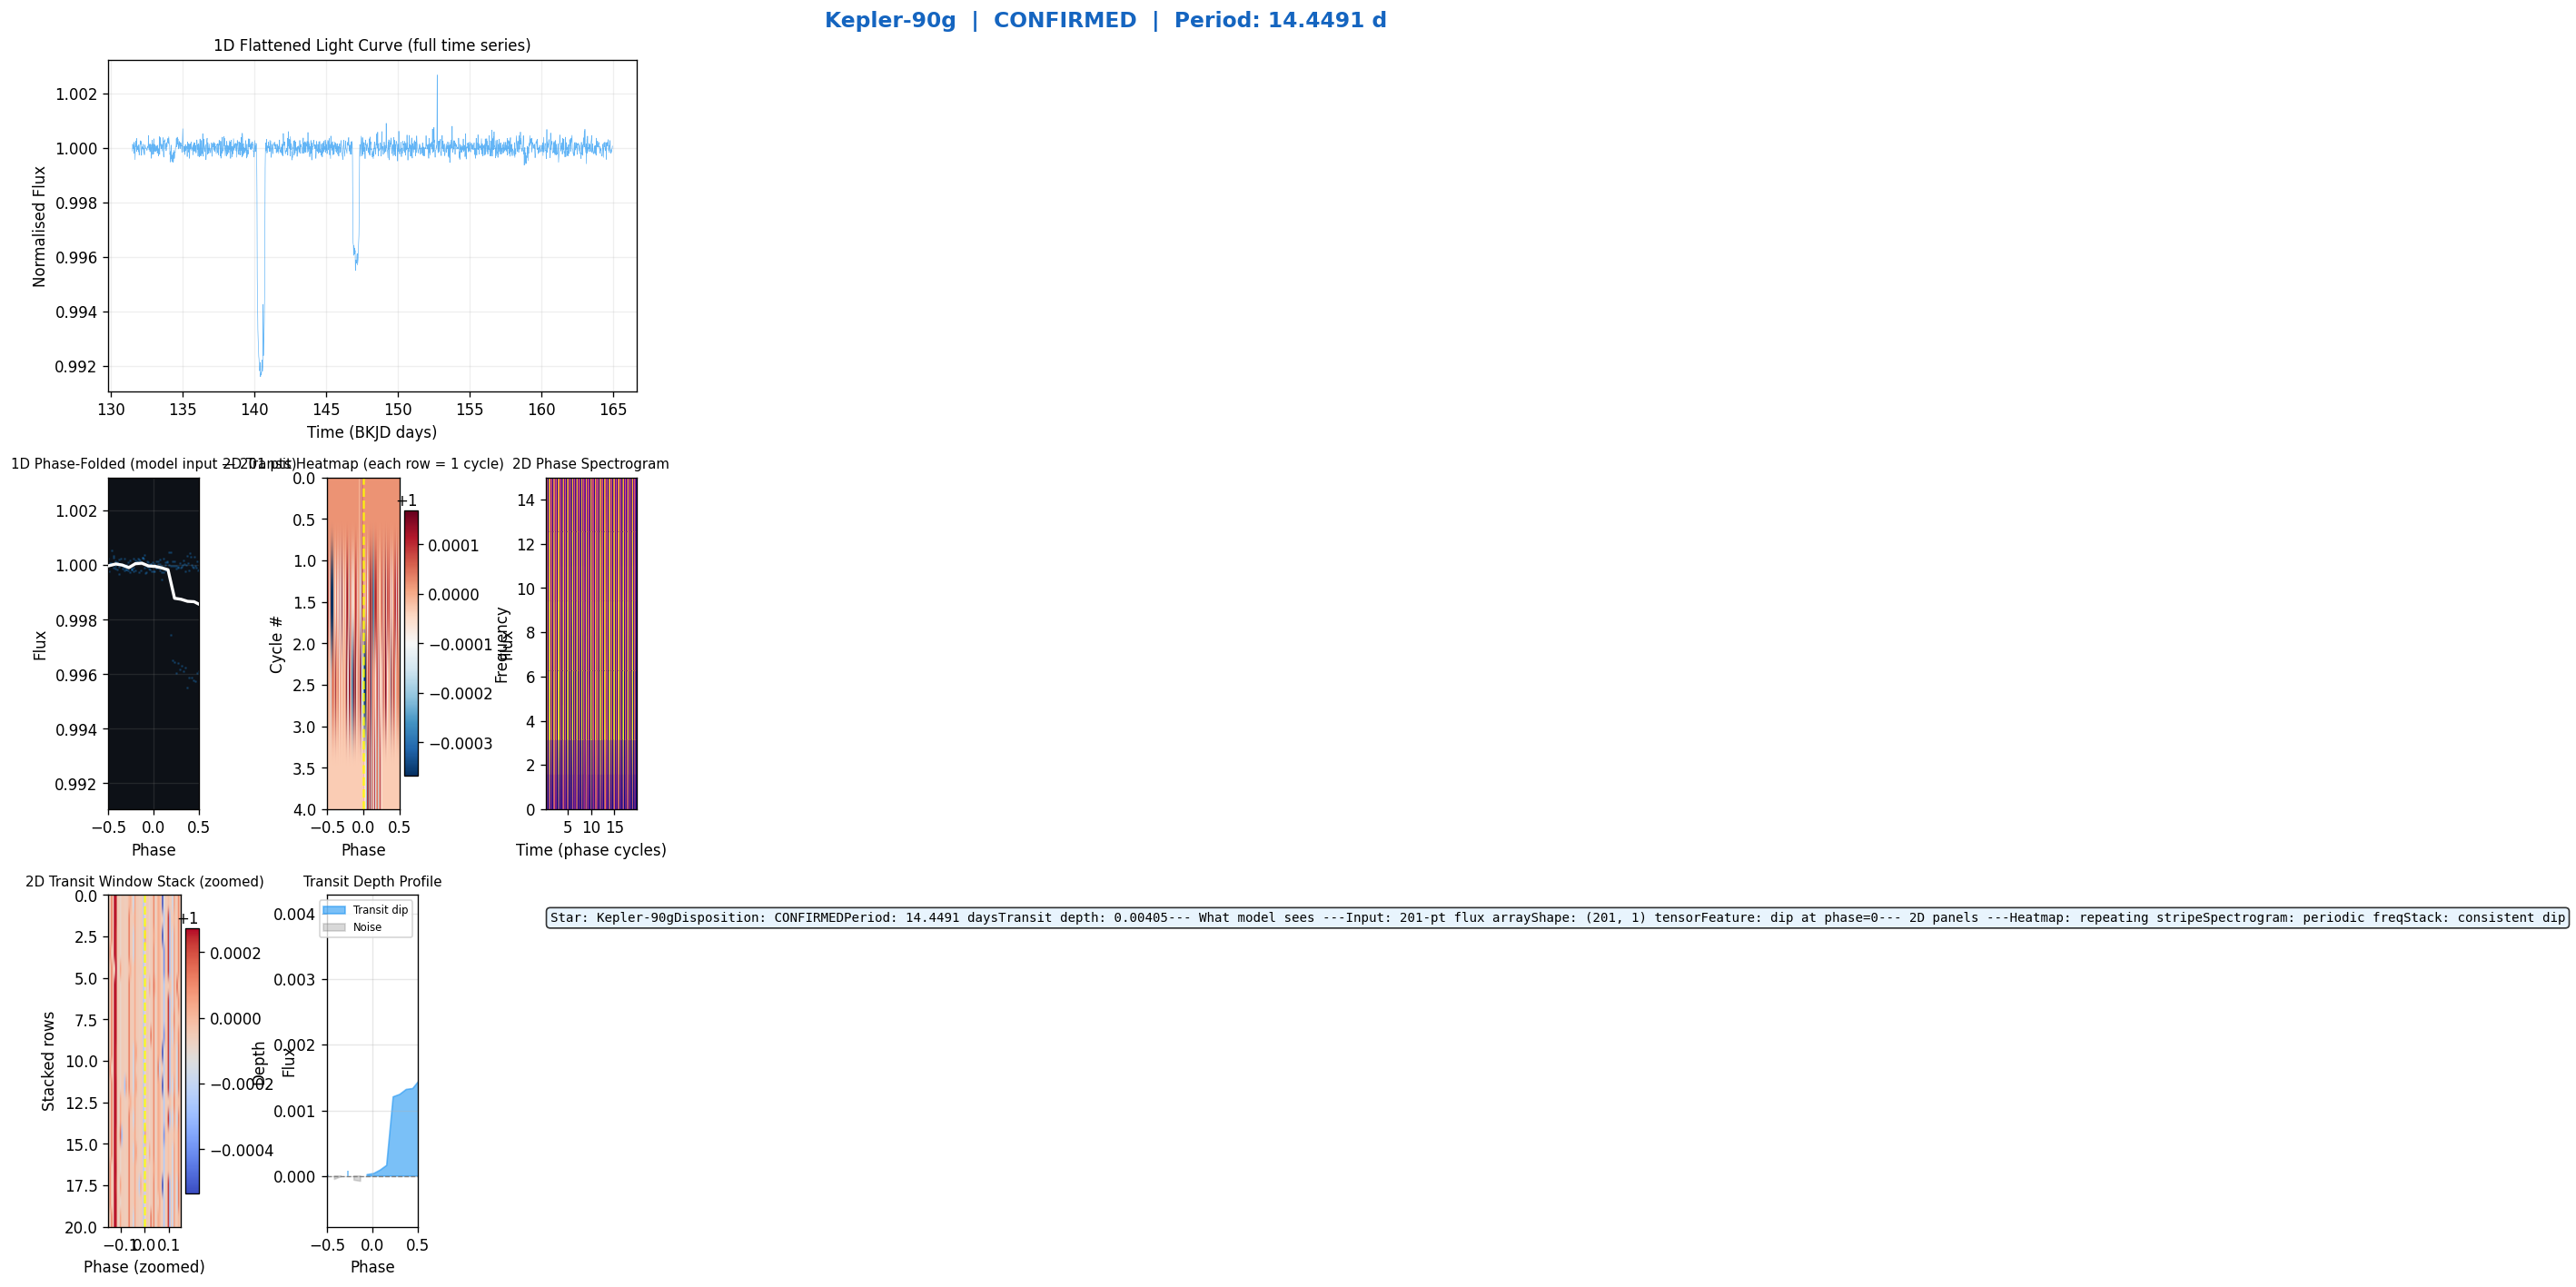

✅ Saved 2d_Kepler-90g.png
CONFIRMED PLANET — Kepler-42b


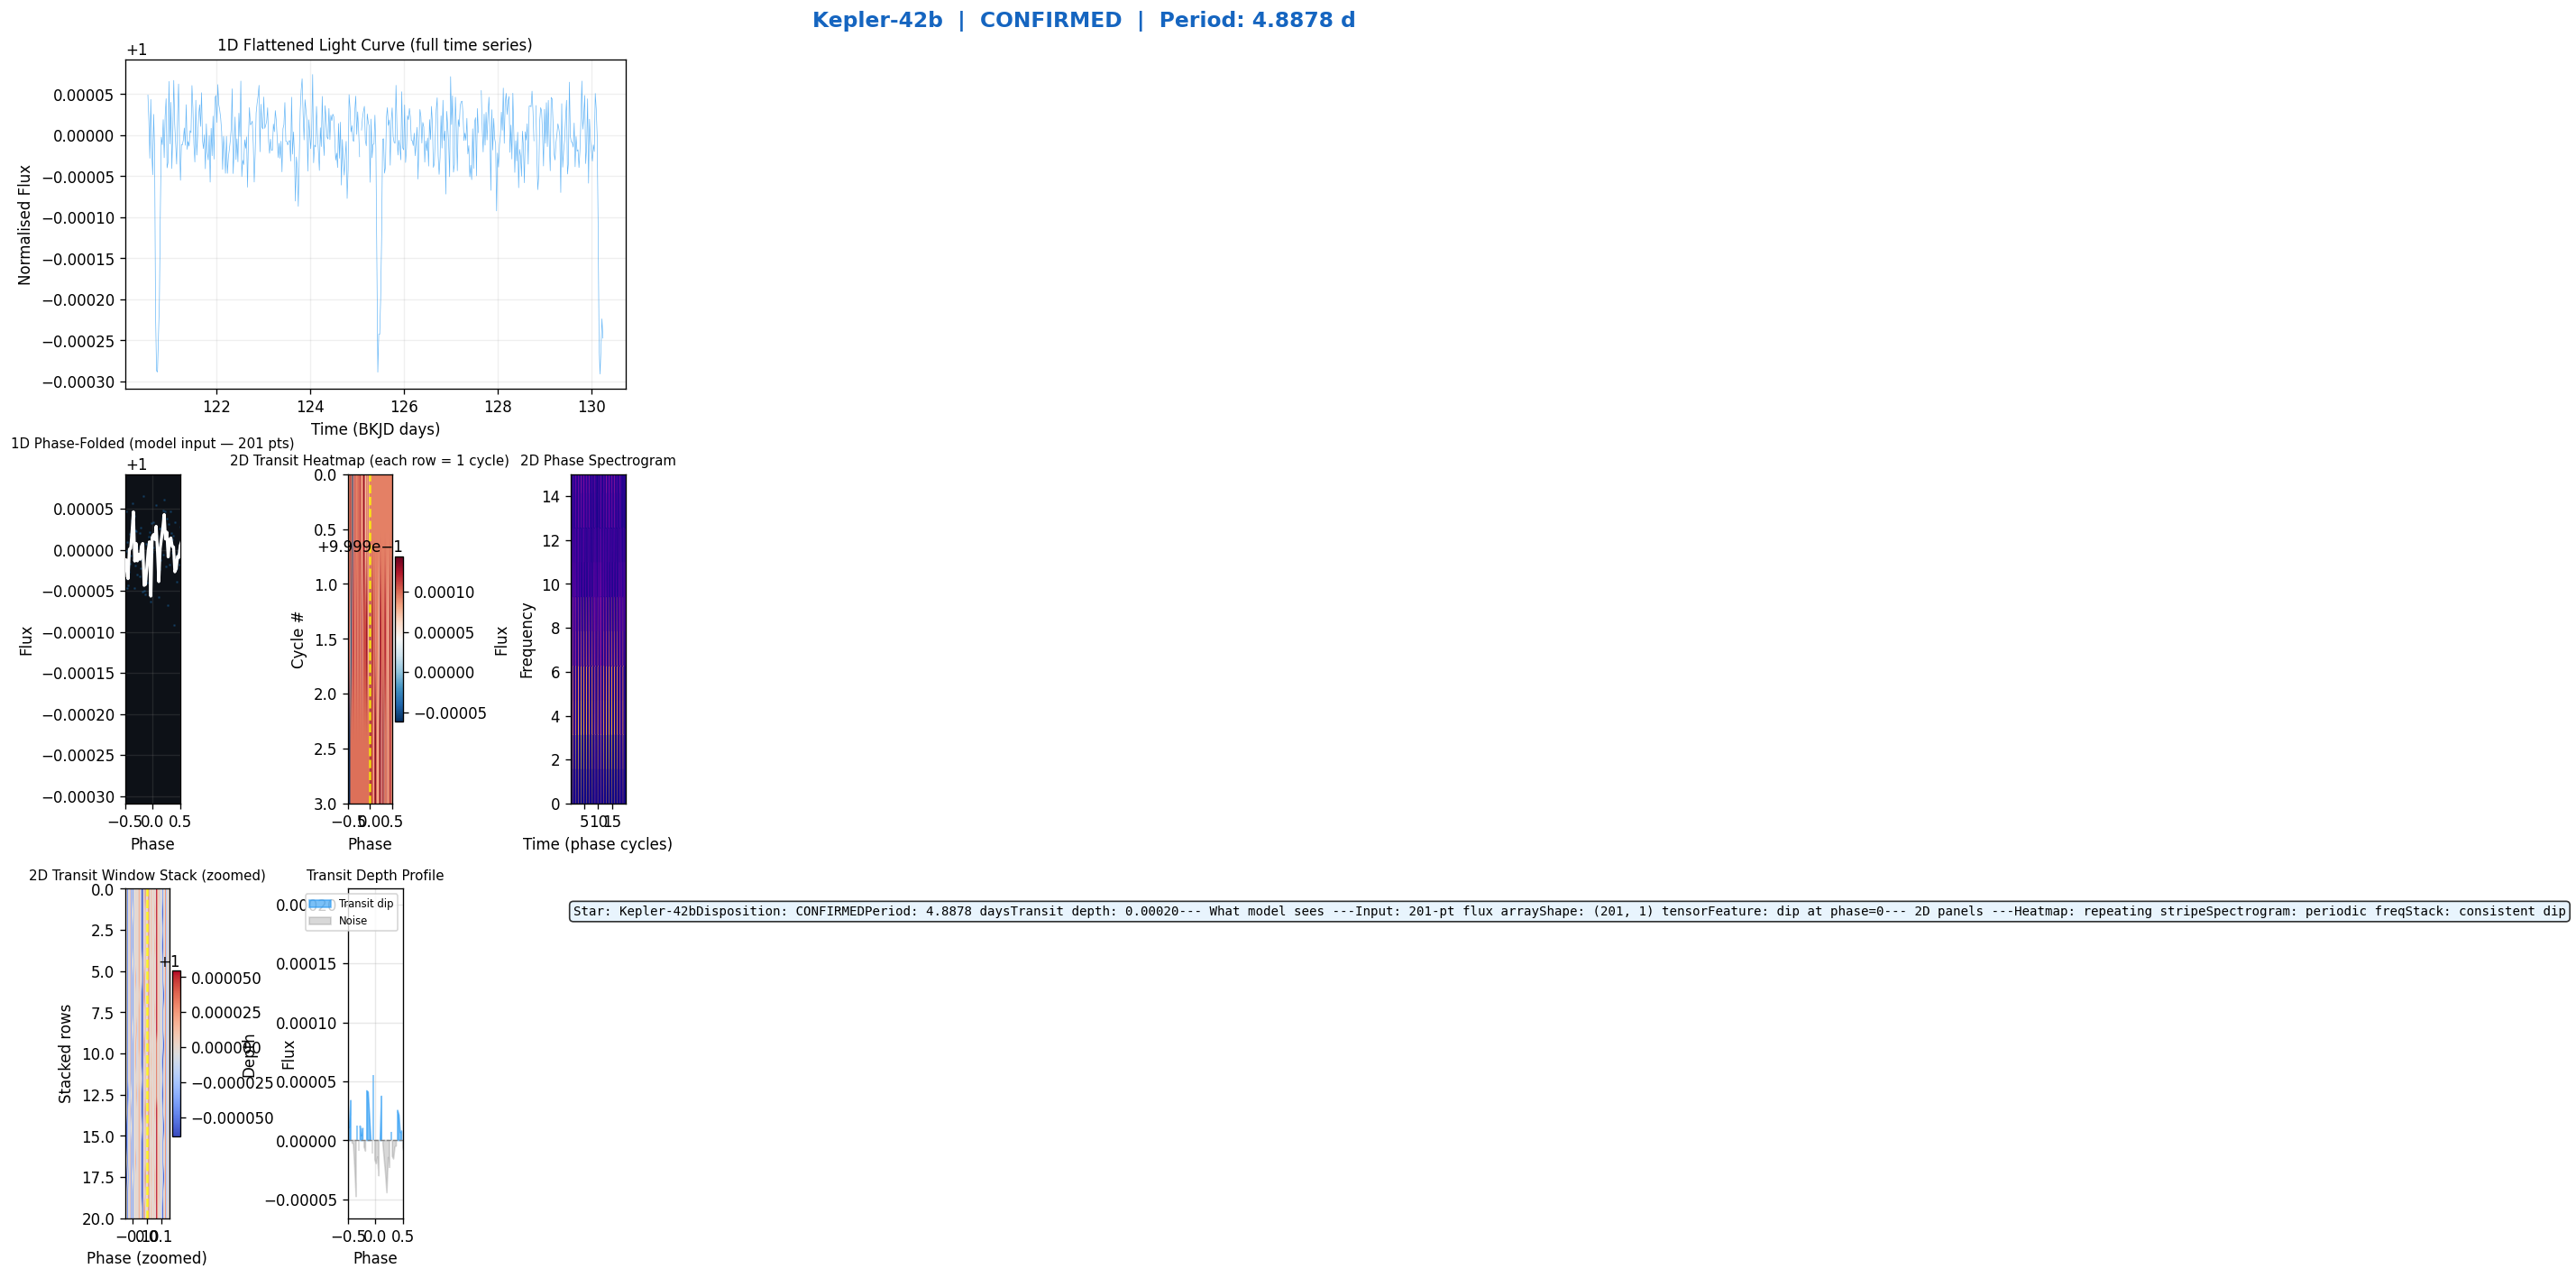

✅ Saved 2d_Kepler-42b.png
FALSE POSITIVE — KOI-189


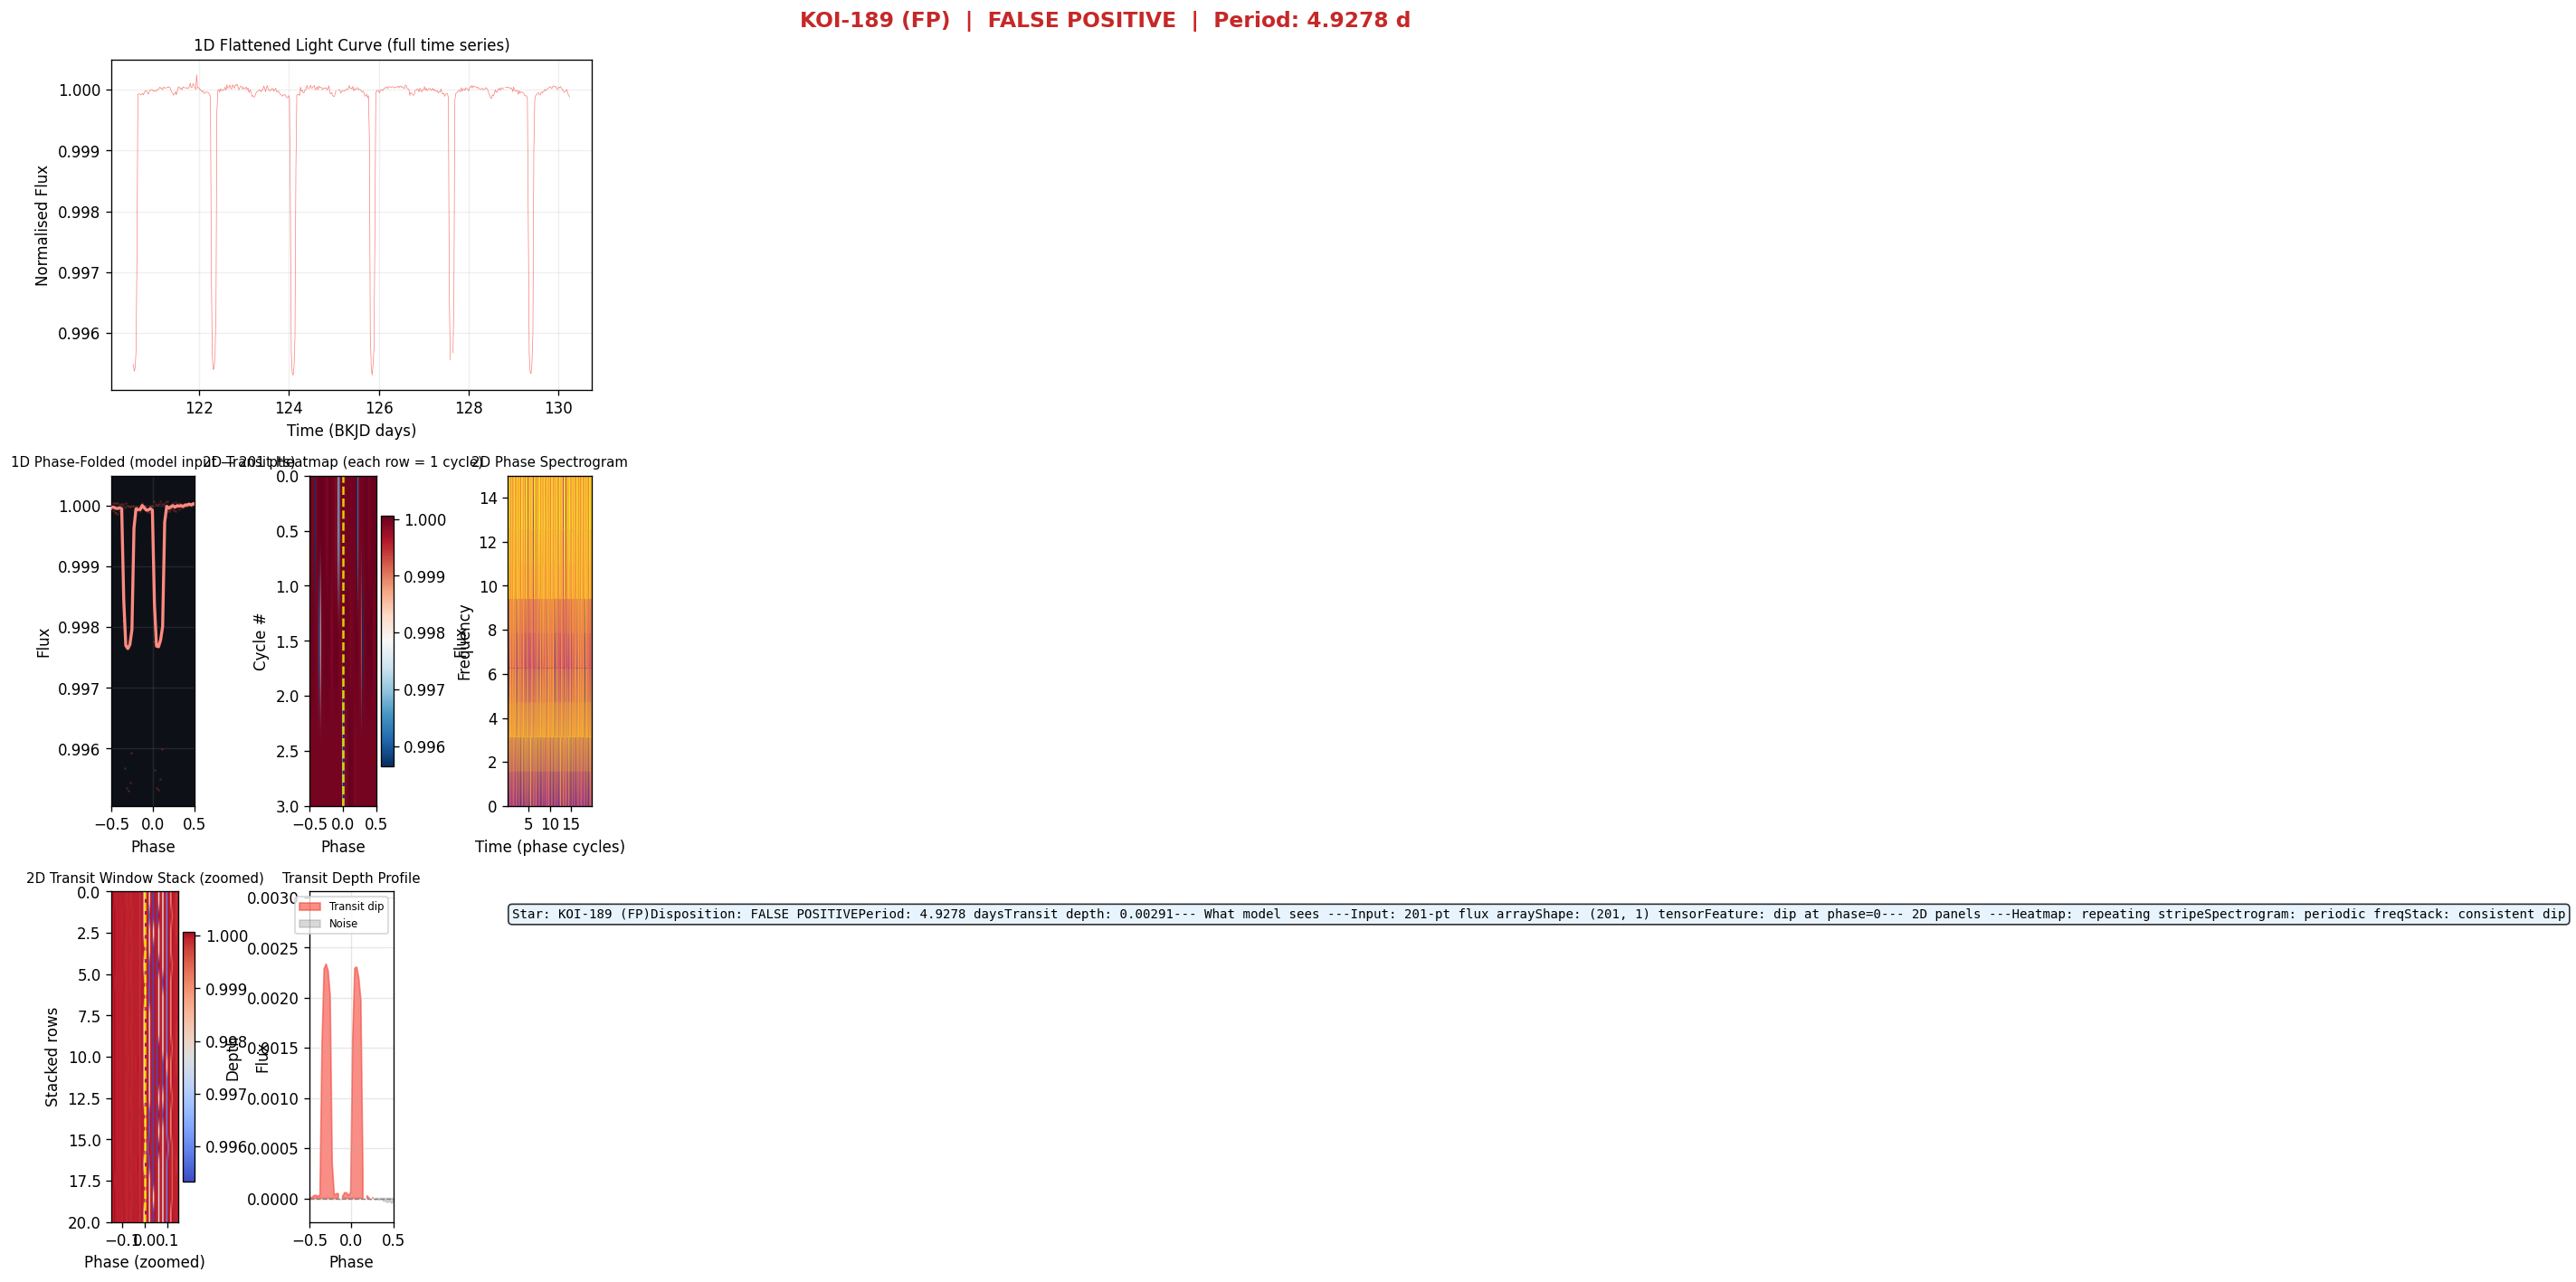

✅ Saved 2d_KOI-189_(FP).png
FALSE POSITIVE — KOI-203


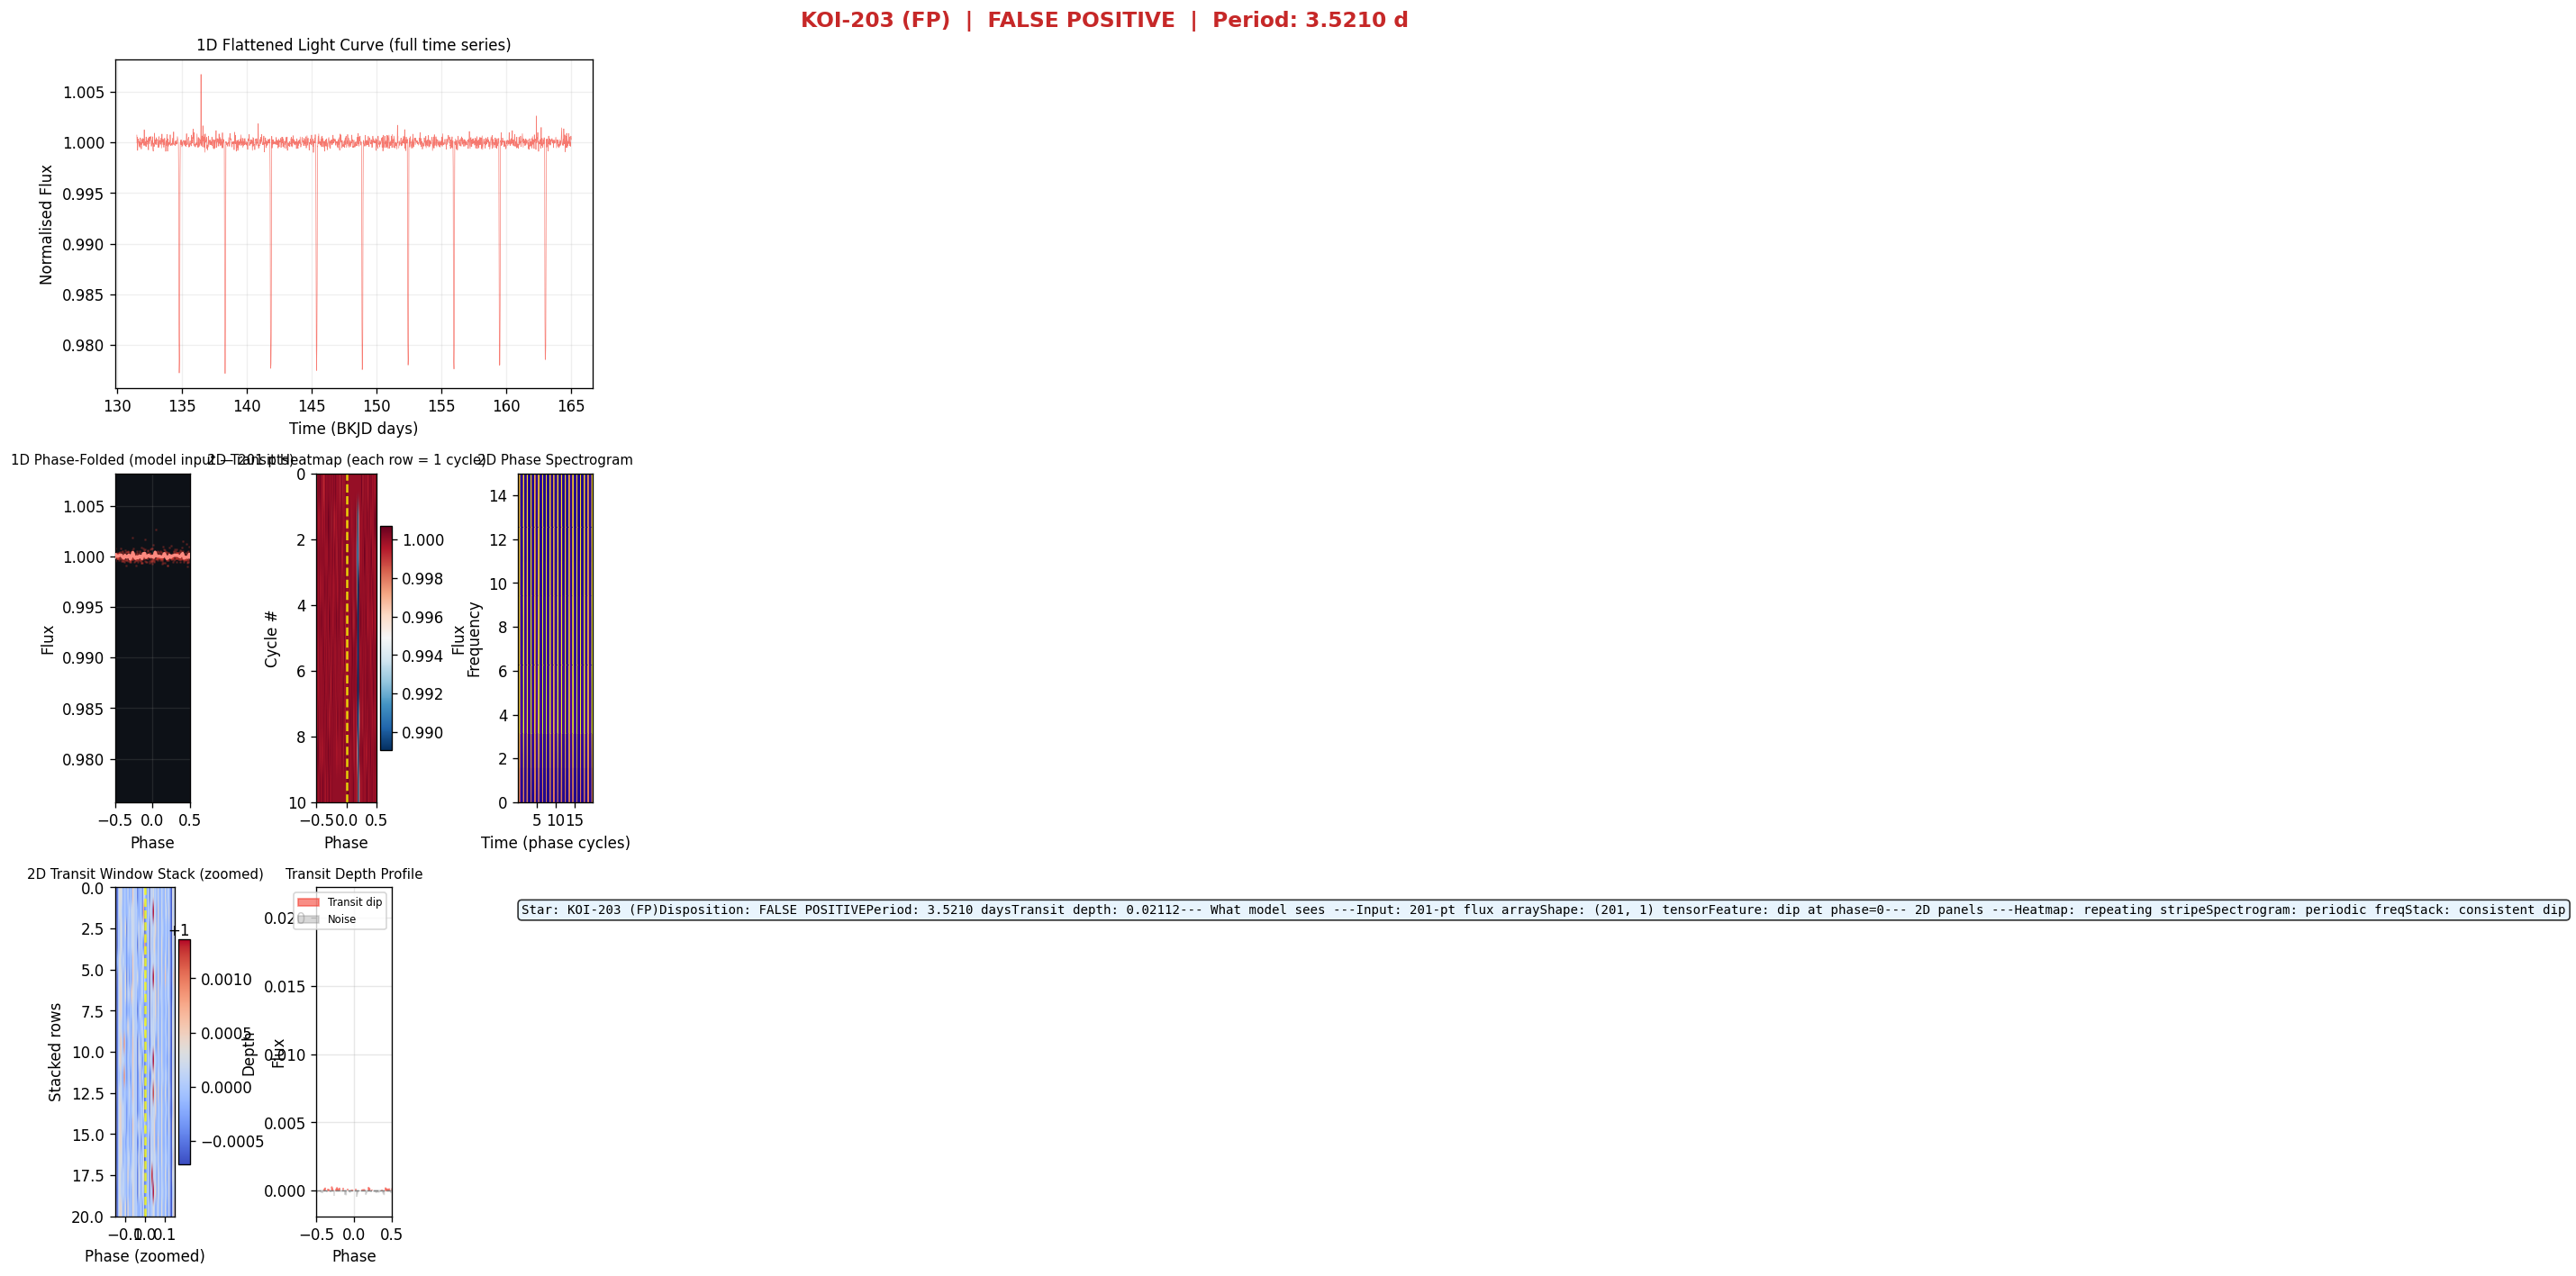

✅ Saved 2d_KOI-203_(FP).png


In [24]:
# ── Step 14: Generate 2D views for 4 examples ────────────────────
np.random.seed(SEED)

print("CONFIRMED PLANET — Kepler-90g")
plot_2d_views(11442793, 14.44912, 2.2, "Kepler-90g", "CONFIRMED")

print("CONFIRMED PLANET — Kepler-42b")
plot_2d_views(3544595, 4.88780, 0.5, "Kepler-42b", "CONFIRMED")

print("FALSE POSITIVE — KOI-189")
plot_2d_views(9941662, 4.9278, 1.2, "KOI-189 (FP)", "FALSE POSITIVE")

print("FALSE POSITIVE — KOI-203")
plot_2d_views(5358624, 3.521, 0.3, "KOI-203 (FP)", "FALSE POSITIVE")

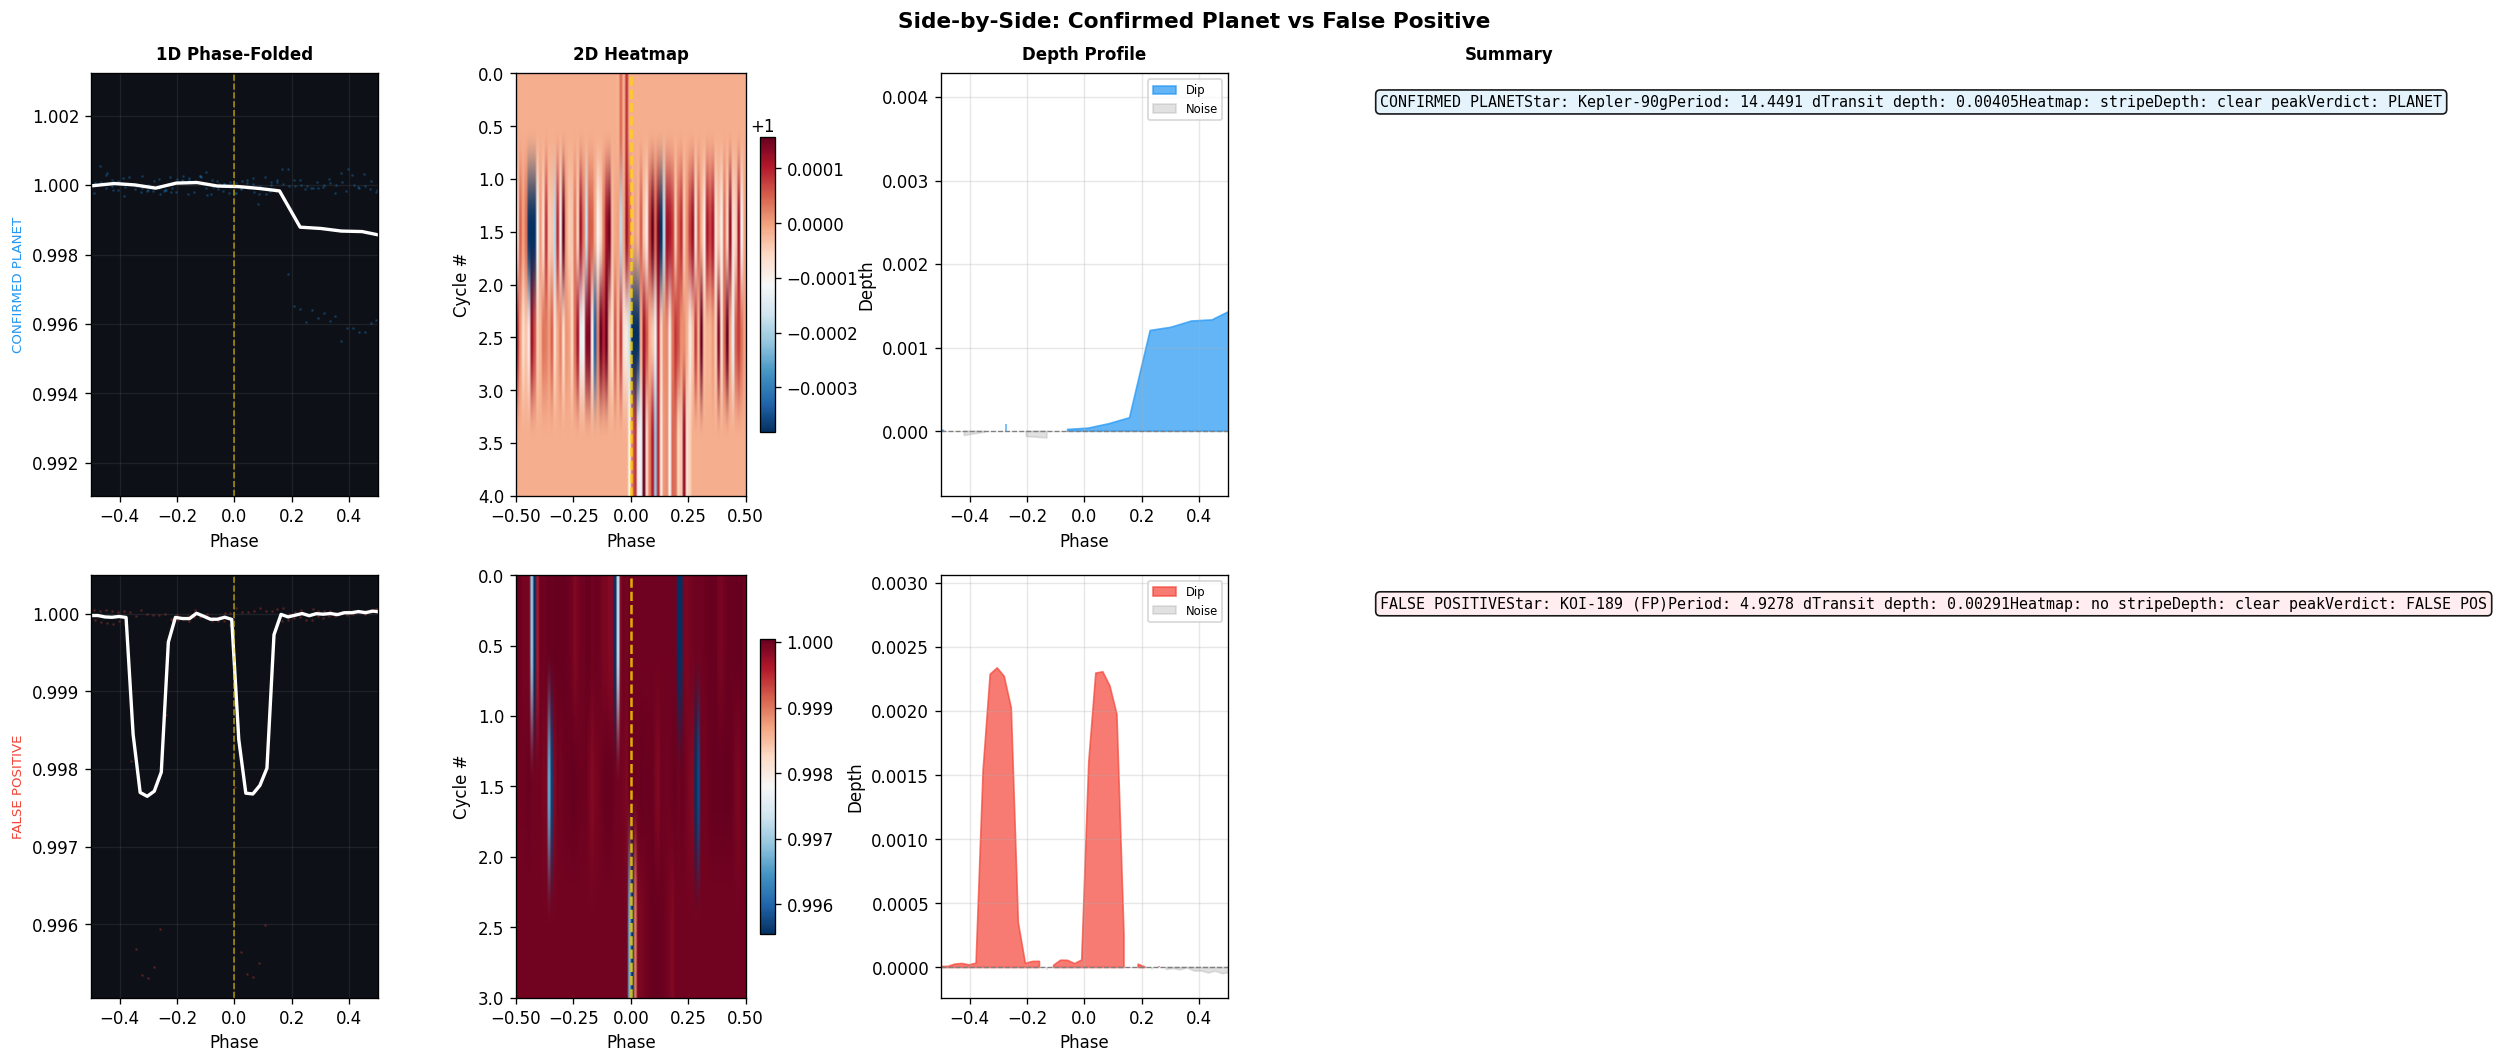

✅ Saved comparison_2d.png


In [25]:
# ── Step 15: Side-by-side 2D comparison: planet vs false positive ──
pairs = [
    (11442793, 14.44912, 2.2,  "Kepler-90g",   "CONFIRMED"),
    (9941662,  4.9278,   1.2,  "KOI-189 (FP)", "FALSE POSITIVE"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Side-by-Side: Confirmed Planet vs False Positive",
             fontsize=13, fontweight="bold")

for ci, ctitle in enumerate(["1D Phase-Folded","2D Heatmap","Depth Profile","Summary"]):
    axes[0][ci].set_title(ctitle, fontsize=10, fontweight="bold", pad=8)

for row_idx, (kid, period, t0, name, disposition) in enumerate(pairs):
    color = "#2196F3" if disposition == "CONFIRMED" else "#F44336"
    lbl   = "CONFIRMED PLANET" if disposition == "CONFIRMED" else "FALSE POSITIVE"
    try:
        search  = lk.search_lightcurve(f"KIC {int(kid)}", mission="Kepler", cadence="long")
        lc      = search[0].download()
        lc_flat = lc.flatten(window_length=101)
        lc_fold = lc_flat.fold(period=period, epoch_time=t0)
        lc_bin  = lc_fold.bin(bins=201)

        # Safe conversion
        fold_phase = _to_numpy(lc_fold.phase)
        fold_flux  = _to_numpy(lc_fold.flux)
        bin_phase  = _to_numpy(lc_bin.phase)
        bin_flux   = _to_numpy(lc_bin.flux)
        time_arr   = _to_numpy(lc_flat.time)
        flux_arr   = _to_numpy(lc_flat.flux)

        _bm = np.nanmedian(bin_flux[np.isfinite(bin_flux)]) if np.any(np.isfinite(bin_flux)) else 1.0
        bin_flux  = np.where(np.isfinite(bin_flux),  bin_flux,  _bm)
        bin_phase = np.where(np.isfinite(bin_phase), bin_phase, 0.0)

        # Col 0: 1D
        ax = axes[row_idx][0]
        ax.plot(fold_phase, fold_flux, ".", color=color, alpha=0.2, ms=1.5)
        ax.plot(bin_phase, bin_flux, "white", lw=2)
        ax.set_facecolor("#0D1117")
        ax.set_ylabel(lbl, fontsize=8, color=color)
        ax.set_xlim(-0.5, 0.5)
        ax.axvline(0, color="gold", lw=1, linestyle="--", alpha=0.6)
        ax.grid(True, alpha=0.15, color="gray")
        ax.set_xlabel("Phase")

        # Col 1: heatmap
        ax = axes[row_idx][1]
        HB, NC = 80, 12
        pbins  = np.linspace(-0.5, 0.5, HB)
        ph_arr = ((time_arr - t0) / period) % 1.0
        ph_arr[ph_arr > 0.5] -= 1.0
        cy     = np.floor((time_arr - t0) / period).astype(int)
        cy    -= cy.min()
        na     = min(NC, int(cy.max())+1)
        hm     = np.full((na, HB), np.nan)
        for c in range(na):
            mk = cy == c
            if int(mk.sum()) < 3:
                continue
            for b in range(HB-1):
                ib = (ph_arr[mk] >= pbins[b]) & (ph_arr[mk] < pbins[b+1])
                if int(ib.sum()) > 0:
                    hm[c,b] = np.nanmedian(flux_arr[mk][ib])
        rm = np.nanmedian(hm, axis=1, keepdims=True)
        hm[np.isnan(hm)] = np.broadcast_to(rm, hm.shape)[np.isnan(hm)]
        im = ax.imshow(hm, aspect="auto", cmap="RdBu_r",
                       extent=[-0.5, 0.5, float(na), 0],
                       vmin=np.nanpercentile(hm,2),
                       vmax=np.nanpercentile(hm,98))
        ax.axvline(0, color="gold", lw=1.5, linestyle="--", alpha=0.8)
        ax.set_xlabel("Phase")
        ax.set_ylabel("Cycle #")
        plt.colorbar(im, ax=ax, shrink=0.7)

        # Col 2: depth profile
        ax     = axes[row_idx][2]
        bline  = np.nanmedian(bin_flux[np.abs(bin_phase) > 0.2])
        dpts   = bline - bin_flux
        ax.fill_between(bin_phase, 0, dpts, where=(dpts>0), color=color, alpha=0.7, label="Dip")
        ax.fill_between(bin_phase, dpts, 0, where=(dpts<0), color="#9E9E9E", alpha=0.3, label="Noise")
        ax.axhline(0, color="gray", linestyle="--", lw=0.8)
        ax.set_xlabel("Phase")
        ax.set_ylabel("Depth")
        ax.set_xlim(-0.5, 0.5)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

        # Col 3: summary
        ax = axes[row_idx][3]
        ax.axis("off")
        dv  = float(np.nanmax(dpts)) if np.nanmax(dpts) > 0 else 0
        bg  = "#E3F2FD" if disposition == "CONFIRMED" else "#FFEBEE"
        inf = (
            f"{lbl}"
            f"Star: {name}"
            f"Period: {period:.4f} d"
            f"Transit depth: {dv:.5f}"
            f"Heatmap: {'stripe' if disposition=='CONFIRMED' else 'no stripe'}"
            f"Depth: {'clear peak' if dv>0.001 else 'flat/noisy'}"
            f"Verdict: {'PLANET' if disposition=='CONFIRMED' else 'FALSE POS'}"
        )
        ax.text(0.05, 0.95, inf, transform=ax.transAxes, fontsize=9,
                verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round", facecolor=bg, alpha=0.9))
    except Exception as e:
        for c in range(4):
            axes[row_idx][c].text(0.5, 0.5, f"Error: {e}",
                ha="center", va="center", transform=axes[row_idx][c].transAxes,
                fontsize=8)

plt.tight_layout()
plt.savefig("comparison_2d.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ Saved comparison_2d.png")

## Part 5 — 1D CNN Model

In [26]:
# ── Step 16: Build model + train/val/test split ───────────────────
# Reshape raw data for Conv1D: (samples, BINS, 1)
X_cnn = X_raw.reshape(X_raw.shape[0], BINS, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_raw, test_size=0.2, random_state=SEED, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED, stratify=y_train)

print(f"Train : {len(X_train)}")
print(f"Val   : {len(X_val)}")
print(f"Test  : {len(X_test)}")

def build_cnn(n=BINS):
    inp = keras.Input(shape=(n, 1), name="light_curve_input")
    x = layers.Conv1D(16,  5, padding="same", activation="relu")(inp)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(32,  5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(64,  5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation="relu", name="features_512")(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation="relu", name="features_256")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation="sigmoid", name="planet_probability")(x)
    return keras.Model(inp, out, name="AstroNet_1D_CNN")

model = build_cnn()
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.AUC(name="auc"),
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")]
)
model.summary()

Train : 2431
Val   : 429
Test  : 715


Model: "AstroNet_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ light_curve_input (InputLayer)  │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 201, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 25, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 12, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features_512 (Dense)            │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ features_256 (Dense)            │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ planet_probability (Dense)      │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 972,609 (3.71 MB)

 Trainable params: 972,609 (3.71 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# ── Step 17: Train with full checkpointing ────────────────────────

class FullCheckpointCallback(keras.callbacks.Callback):
    """
    Saves epoch number and learning rate to Google Drive
    after every epoch so training can resume exactly where
    it left off in a future Colab session.
    """
    def on_epoch_end(self, epoch, logs=None):
        np.save(EPOCH_PATH, epoch + 1)
        current_lr = float(keras.backend.get_value(
            self.model.optimizer.learning_rate))
        np.save(LR_PATH, current_lr)
        print(f'  Checkpoint saved — epoch {epoch+1}  '
              f'val_auc={logs.get("val_auc", 0):.4f}  '
              f'lr={current_lr:.6f}')

# ── Check for existing checkpoint ─────────────────────────────────
initial_epoch = 0

if os.path.exists(CHECKPOINT_PATH):
    print('✅ Found checkpoint — loading weights from previous session...')
    model.load_weights(CHECKPOINT_PATH)
    if os.path.exists(EPOCH_PATH):
        initial_epoch = int(np.load(EPOCH_PATH))
        print(f'   Resuming from epoch {initial_epoch}')
    if os.path.exists(LR_PATH):
        saved_lr = float(np.load(LR_PATH))
        keras.backend.set_value(model.optimizer.learning_rate, saved_lr)
        print(f'   Learning rate restored: {saved_lr:.6f}')
else:
    print('No checkpoint found — starting fresh from epoch 0')

# ── Callbacks ─────────────────────────────────────────────────────
cnn_callbacks = [
    keras.callbacks.EarlyStopping(
        patience=8, restore_best_weights=True,
        monitor='val_auc', mode='max', verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        patience=4, factor=0.5, monitor='val_loss', verbose=1),
    keras.callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        save_best_only=True, monitor='val_auc',
        mode='max', verbose=1),
    FullCheckpointCallback(),
]

# ── Train ─────────────────────────────────────────────────────────
history_new = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    initial_epoch=initial_epoch,
    batch_size=BATCH_SIZE,
    callbacks=cnn_callbacks,
    verbose=1
)

# ── Merge with previous session history ───────────────────────────
if os.path.exists(HISTORY_PATH):
    old_h = np.load(HISTORY_PATH, allow_pickle=True).item()
    for key in history_new.history:
        if key in old_h:
            old_h[key].extend(history_new.history[key])
        else:
            old_h[key] = history_new.history[key]
    merged = old_h
else:
    merged = history_new.history

np.save(HISTORY_PATH, merged)

class HistoryWrapper:
    def __init__(self, h):
        self.history = h

history = HistoryWrapper(merged)

print(f'\n✅ Training complete!')
print(f'   Total epochs trained : {len(history.history["loss"])}')
print(f'   Best val AUC         : {max(history.history["val_auc"]):.4f}')
print(f'   Best val Accuracy    : {max(history.history["val_accuracy"]):.4f}')
print(f'   Checkpoint saved to  : {CHECKPOINT_PATH}')
print(f'   History saved to     : {HISTORY_PATH}')

No checkpoint found — starting fresh from epoch 0
Epoch 1/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5874 - auc: 0.6497 - loss: 0.6741 - precision: 0.5536 - recall: 0.8226
Epoch 1: val_auc improved from None to 0.76561, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 1  val_auc=0.7656  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 130ms/step - accuracy: 0.6236 - auc: 0.6719 - loss: 0.6634 - precision: 0.5850 - recall: 0.8264 - val_accuracy: 0.7040 - val_auc: 0.7656 - val_loss: 0.6166 - val_precision: 0.6641 - val_recall: 0.8113 - learning_rate: 1.0000e-04
Epoch 2/60
58/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6766 - auc: 0.7162 - loss: 0.6250 - precision: 0.6318 - recall: 0.8216
Epoch 2: val_auc improved from 0.76561 to 0.80953, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 2  val_auc=0.8095  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6828 - auc: 0.7282 - loss: 0.6089 - precision: 0.6488 - recall: 0.7841 - val_accuracy: 0.7296 - val_auc: 0.8095 - val_loss: 0.5393 - val_precision: 0.6935 - val_recall: 0.8113 - learning_rate: 1.0000e-04
Epoch 3/60
58/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6923 - auc: 0.7565 - loss: 0.5794 - precision: 0.6533 - recall: 0.7985
Epoch 3: val_auc improved from 0.80953 to 0.82786, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 3  val_auc=0.8279  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7022 - auc: 0.7614 - loss: 0.5738 - precision: 0.6749 - recall: 0.7691 - val_accuracy: 0.7343 - val_auc: 0.8279 - val_loss: 0.5089 - val_precision: 0.7112 - val_recall: 0.7783 - learning_rate: 1.0000e-04
Epoch 4/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7146 - auc: 0.7759 - loss: 0.5595 - precision: 0.6802 - recall: 0.7923
Epoch 4: val_auc improved from 0.82786 to 0.83837, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 4  val_auc=0.8384  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7207 - auc: 0.7865 - loss: 0.5508 - precision: 0.6940 - recall: 0.7799 - val_accuracy: 0.7436 - val_auc: 0.8384 - val_loss: 0.4872 - val_precision: 0.7161 - val_recall: 0.7972 - learning_rate: 1.0000e-04
Epoch 5/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7226 - auc: 0.7945 - loss: 0.5431 - precision: 0.6859 - recall: 0.8072
Epoch 5: val_auc improved from 0.83837 to 0.84865, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 7  val_auc=0.8632  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7450 - auc: 0.8266 - loss: 0.5072 - precision: 0.7215 - recall: 0.7899 - val_accuracy: 0.7552 - val_auc: 0.8632 - val_loss: 0.4471 - val_precision: 0.7357 - val_recall: 0.7877 - learning_rate: 1.0000e-04
Epoch 8/60
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7442 - auc: 0.8314 - loss: 0.5058 - precision: 0.7107 - recall: 0.8099
Epoch 8: val_auc improved from 0.86321 to 0.86646, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 8  val_auc=0.8665  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7511 - auc: 0.8351 - loss: 0.4988 - precision: 0.7278 - recall: 0.7949 - val_accuracy: 0.7599 - val_auc: 0.8665 - val_loss: 0.4420 - val_precision: 0.7380 - val_recall: 0.7972 - learning_rate: 1.0000e-04
Epoch 9/60
59/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7651 - auc: 0.8471 - loss: 0.4866 - precision: 0.7307 - recall: 0.8279
Epoch 9: val_auc improved from 0.86646 to 0.87202, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 9  val_auc=0.8720  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7709 - auc: 0.8493 - loss: 0.4808 - precision: 0.7529 - recall: 0.7998 - val_accuracy: 0.7716 - val_auc: 0.8720 - val_loss: 0.4347 - val_precision: 0.7415 - val_recall: 0.8255 - learning_rate: 1.0000e-04
Epoch 10/60
59/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7562 - auc: 0.8450 - loss: 0.4867 - precision: 0.7232 - recall: 0.8169
Epoch 10: val_auc improved from 0.87202 to 0.87830, saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5



Epoch 10: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 10  val_auc=0.8783  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7779 - auc: 0.8554 - loss: 0.4725 - precision: 0.7602 - recall: 0.8056 - val_accuracy: 0.7809 - val_auc: 0.8783 - val_loss: 0.4270 - val_precision: 0.7611 - val_recall: 0.8113 - learning_rate: 1.0000e-04
Epoch 11/60
58/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7679 - auc: 0.8540 - loss: 0.4778 - precision: 0.7420 - recall: 0.8096
Epoch 11: val_auc did not improve from 0.87830
  Checkpoint saved — epoch 11  val_auc=0.8783  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7836 - auc: 0.8626 - loss: 0.4631 - precision: 0.7690 - recall: 0.8048 - val_accuracy: 0.7739 - val_auc: 0.8783 - val_loss: 0.4259 - val_precision: 0.7602 - val_recall: 0.7925 - learning_rate: 1.0000e-04
Epoch 12/60
58/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7850 - auc: 0.8659 - loss


Epoch 15: finished saving model to /content/drive/MyDrive/exoplanet_checkpoints/best_model.h5
  Checkpoint saved — epoch 15  val_auc=0.8784  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8363 - auc: 0.9138 - loss: 0.3810 - precision: 0.8320 - recall: 0.8389 - val_accuracy: 0.7692 - val_auc: 0.8784 - val_loss: 0.4291 - val_precision: 0.7678 - val_recall: 0.7642 - learning_rate: 1.0000e-04
Epoch 16/60
74/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8250 - auc: 0.9109 - loss: 0.3844 - precision: 0.8071 - recall: 0.8474
Epoch 16: val_auc did not improve from 0.87841
  Checkpoint saved — epoch 16  val_auc=0.8767  lr=0.000100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8425 - auc: 0.9207 - loss: 0.3658 - precision: 0.8340 - recall: 0.8513 - val_accuracy: 0.7716 - val_auc: 0.8767 - val_loss: 0.4334 - val_precision: 0.7591 - val_recall: 0.7877 - learning_rate: 1.0000e-04
Epoch 17/60
74/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8406 - auc: 0.9233 - loss

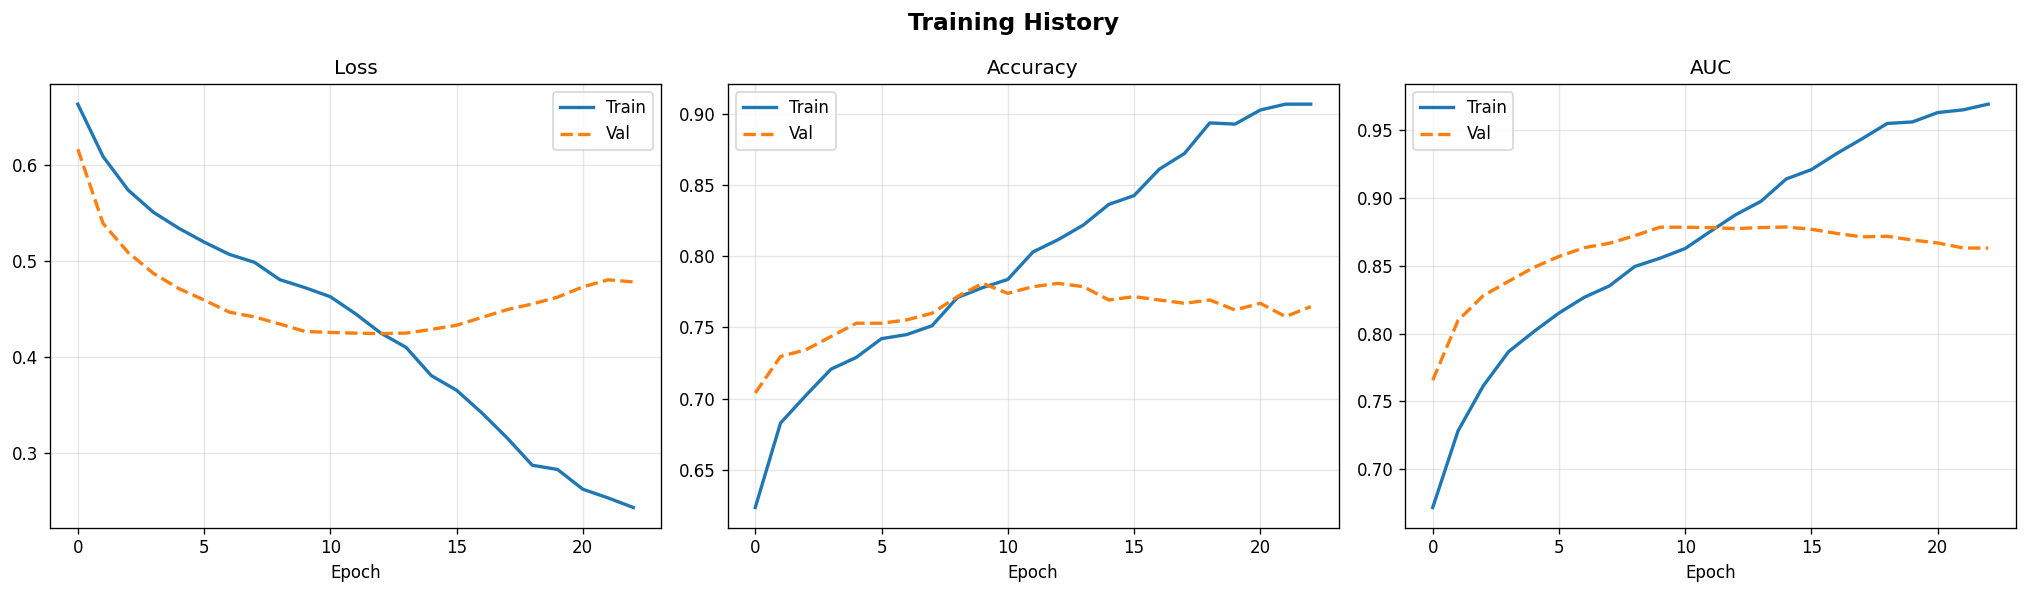

✅ Saved training_history.png
   Best val AUC      : 0.8784
   Best val Accuracy : 0.7809
   Total epochs      : 23


In [28]:
# ── Step 18: Training history graphs ─────────────────────────────
if history is None:
    print("⚠️  No training history available.")
    print("   Run the training cell (Step 17) or the resume cell first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Training History", fontsize=14, fontweight="bold")

    for ax, metric, title in zip(axes,
            ["loss","accuracy","auc"], ["Loss","Accuracy","AUC"]):
        ax.plot(history.history[metric],          label="Train", lw=2)
        ax.plot(history.history[f"val_{metric}"], label="Val",   lw=2, linestyle="--")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_history.png", bbox_inches="tight", dpi=120)
    plt.show()
    print("✅ Saved training_history.png")
    print(f"   Best val AUC      : {max(history.history['val_auc']):.4f}")
    print(f"   Best val Accuracy : {max(history.history['val_accuracy']):.4f}")
    print(f"   Total epochs      : {len(history.history['loss'])}")

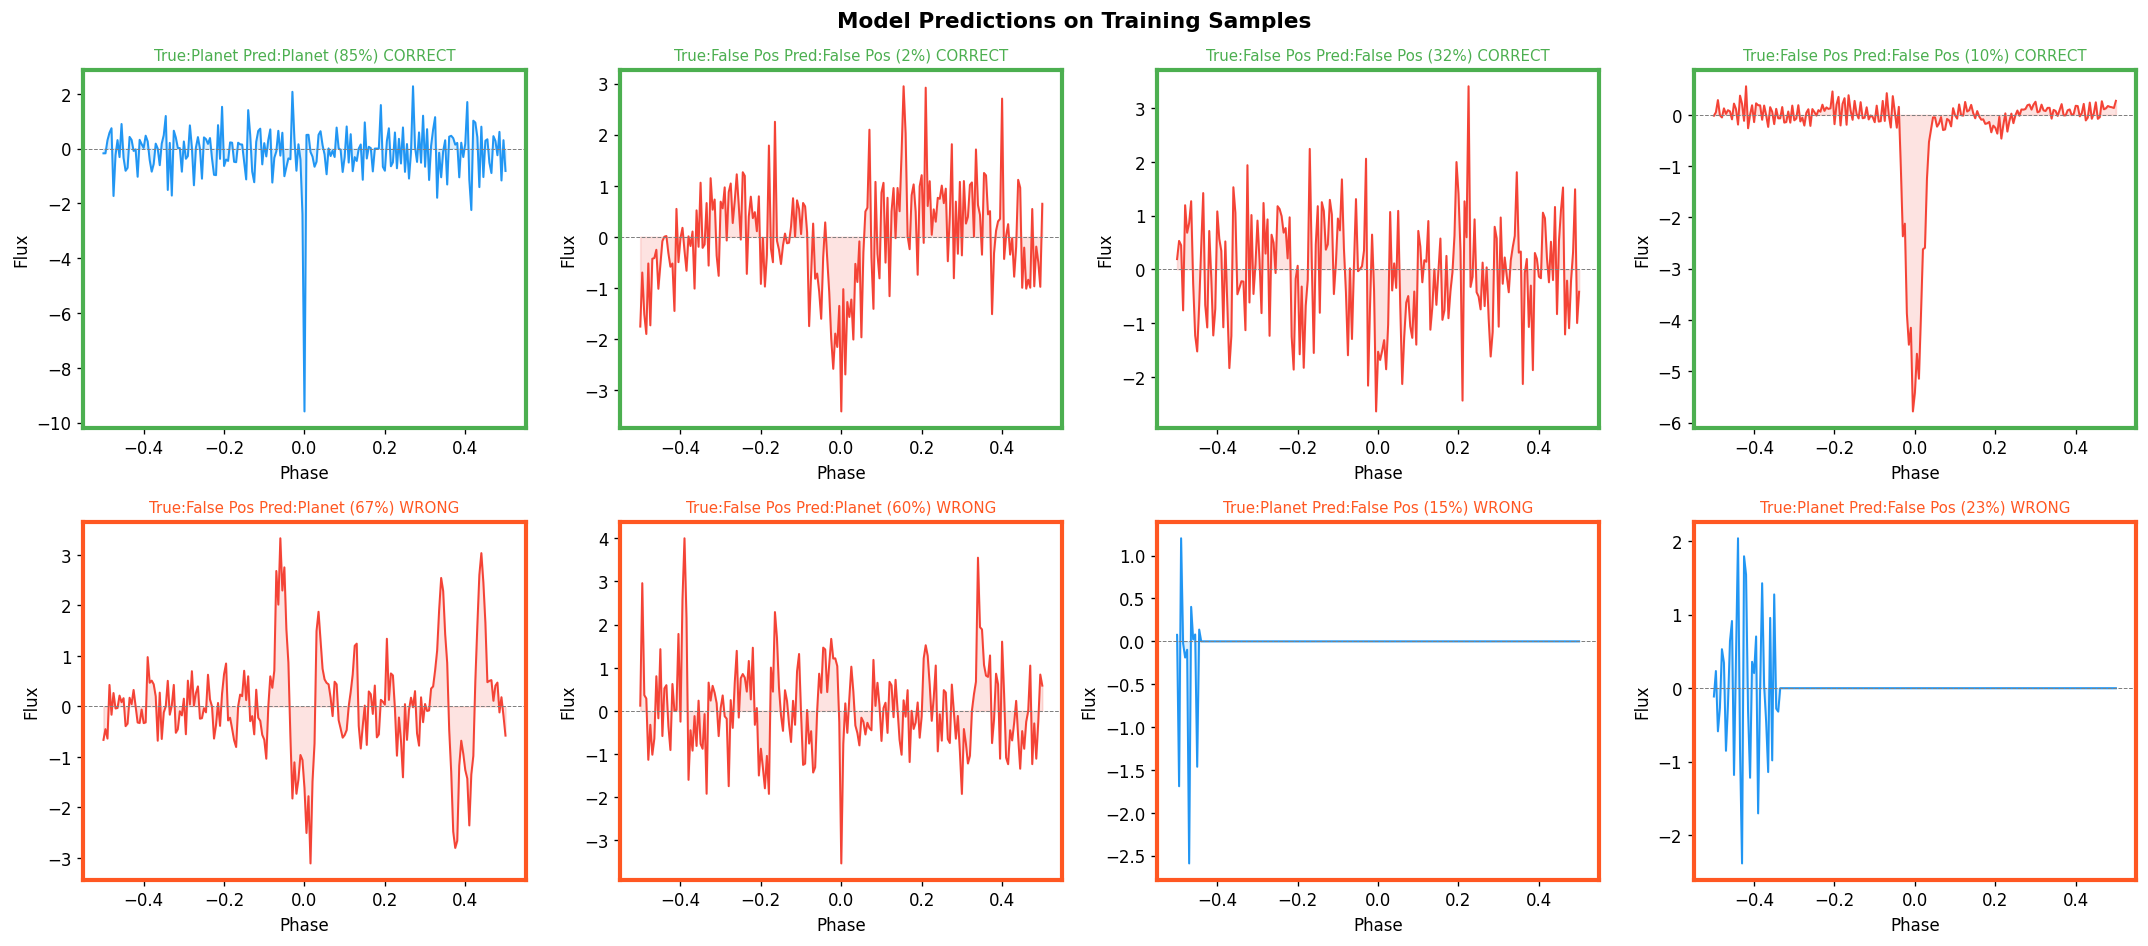

✅ Saved train_predictions.png


In [30]:
# ── Step 19: Training set predictions ────────────────────────────
y_prob_train = model.predict(X_train, verbose=0).flatten()
y_pred_train = (y_prob_train >= 0.5).astype(int)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Model Predictions on Training Samples",
             fontsize=13, fontweight="bold")
x_axis = np.linspace(-0.5, 0.5, BINS)

correct_tr = np.where(y_pred_train == y_train)[0][:4]
wrong_tr   = np.where(y_pred_train != y_train)[0][:4]
idxs       = list(correct_tr) + list(wrong_tr)

for i, idx in enumerate(idxs[:8]):
    ax     = axes[i//4][i%4]
    flux   = X_train[idx].flatten()
    prob   = float(y_prob_train[idx])
    cor    = bool(y_pred_train[idx] == y_train[idx])
    tlbl   = "Planet" if y_train[idx] == 1 else "False Pos"
    plbl   = "Planet" if y_pred_train[idx] == 1 else "False Pos"
    color  = "#2196F3" if y_train[idx] == 1 else "#F44336"
    border = "#4CAF50" if cor else "#FF5722"
    ax.plot(x_axis, flux, color=color, lw=1.2)
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    ax.axhline(0, color="gray", linestyle="--", lw=0.6)
    for sp in ax.spines.values():
        sp.set_edgecolor(border)
        sp.set_linewidth(2.5)
    status = "CORRECT" if cor else "WRONG"
    ax.set_title(f"True:{tlbl} Pred:{plbl} ({prob:.0%}) {status}", fontsize=9, color=border)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.savefig("train_predictions.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved train_predictions.png")

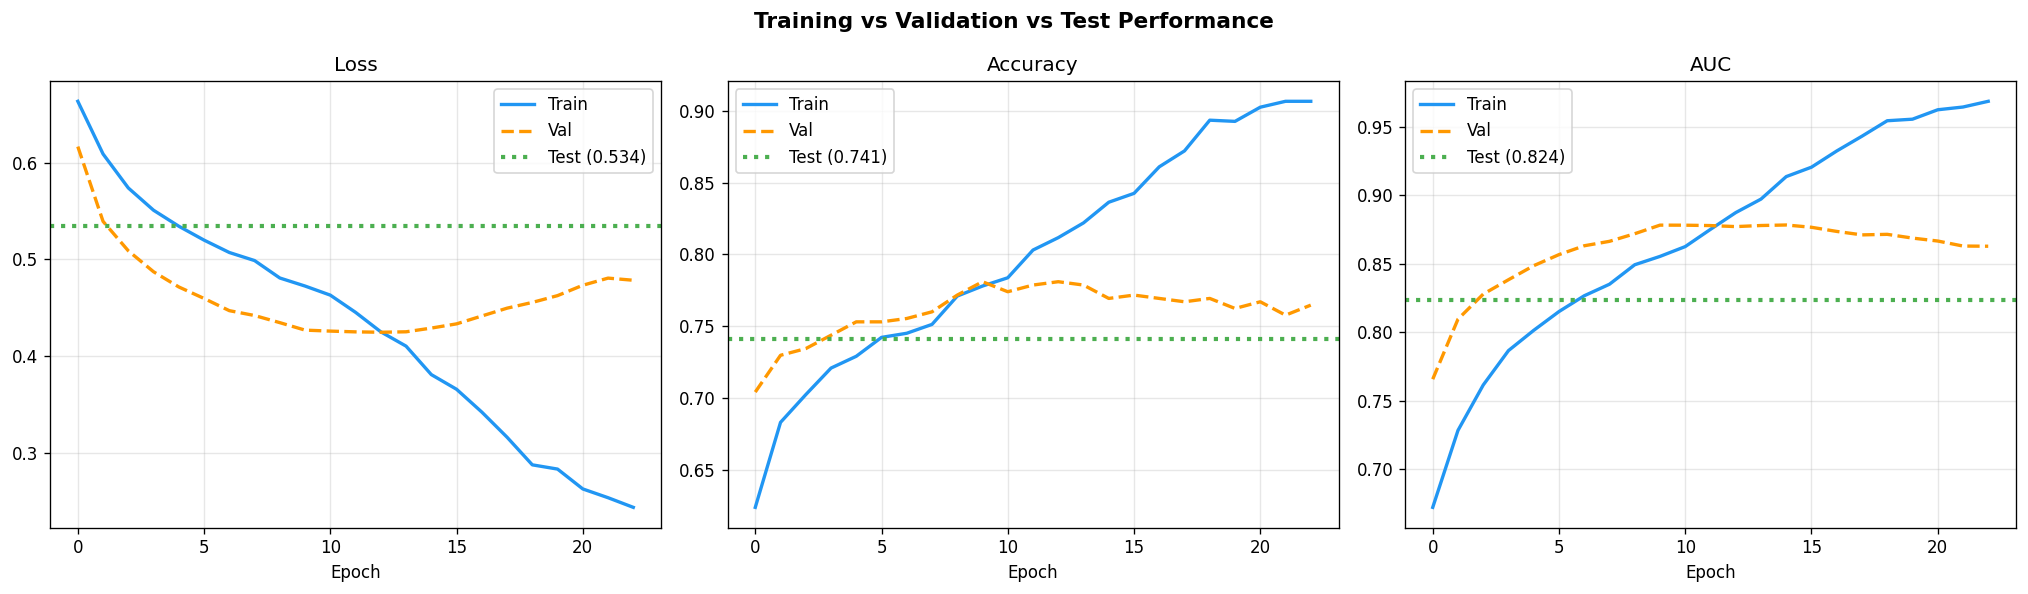

✅ Saved train_vs_test.png
   Best val AUC      : 0.8784
   Best val Accuracy : 0.7809
   Total epochs      : 23

Test results:
  Loss        : 0.5344
  Accuracy    : 0.7413
  AUC         : 0.8238
  Precision   : 0.7421
  Recall      : 0.7316


In [31]:
# ── Step 20: Training vs Test performance overlay ─────────────────
# Runs evaluation and then overlays test score on training curves

y_prob_raw_init = model.predict(X_test, verbose=0).flatten()
valid_mask_init = np.isfinite(y_prob_raw_init) & np.isfinite(y_test)

if int((~valid_mask_init).sum()) > 0:
    X_tc            = np.nan_to_num(X_test, nan=0.0)
    y_prob_raw_init = model.predict(X_tc, verbose=0).flatten()
    valid_mask_init = np.isfinite(y_prob_raw_init) & np.isfinite(y_test)
    X_eval_init     = X_tc[valid_mask_init]
else:
    X_eval_init = X_test[valid_mask_init]

y_prob_eval = y_prob_raw_init[valid_mask_init]
y_test_eval = y_test[valid_mask_init]
y_pred_eval = (y_prob_eval >= 0.5).astype(int)
results     = model.evaluate(X_eval_init, y_test_eval, verbose=0)

if history is None:
    print("⚠️  No training history available — cannot plot overlay.")
    print("   Run the training cell (Step 17) or the resume cell first.")
    print()
    print("Test results only:")
    for name, val in zip(["Loss","Accuracy","AUC","Precision","Recall"], results):
        print(f"  {name:12s}: {val:.4f}")
else:
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle("Training vs Validation vs Test Performance",
                 fontsize=13, fontweight="bold")
    test_metrics = {"accuracy": results[1], "auc": results[2], "loss": results[0]}

    for ax, metric, title in zip(axes,
            ["loss","accuracy","auc"], ["Loss","Accuracy","AUC"]):
        ax.plot(history.history[metric],          label="Train", lw=2, color="#2196F3")
        ax.plot(history.history[f"val_{metric}"], label="Val",   lw=2, linestyle="--", color="#FF9800")
        ax.axhline(test_metrics[metric], color="#4CAF50", linestyle=":", lw=2.5,
                   label=f"Test ({test_metrics[metric]:.3f})")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("train_vs_test.png", bbox_inches="tight", dpi=120)
    plt.show()
    print("✅ Saved train_vs_test.png")
    print(f"   Best val AUC      : {max(history.history['val_auc']):.4f}")
    print(f"   Best val Accuracy : {max(history.history['val_accuracy']):.4f}")
    print(f"   Total epochs      : {len(history.history['loss'])}")
    print()
    print("Test results:")
    for name, val in zip(["Loss","Accuracy","AUC","Precision","Recall"], results):
        print(f"  {name:12s}: {val:.4f}")

## Part 6 — 1D Diffusion Model for Light Curve Generation

A **Denoising Diffusion Probabilistic Model (DDPM)** learns to generate realistic
synthetic light curves by learning the reverse of a gradual noise-addition process.

**Why use diffusion for exoplanet detection?**
- Training data is limited (only ~600 samples)
- Diffusion can generate realistic new transit signals
- Augmenting with generated data can improve CNN generalisation

**How it works:**
1. **Forward process** — gradually add Gaussian noise to real light curves over T steps
2. **Reverse process** — train a 1D denoiser to predict and remove the noise step by step
3. **Generation** — start from pure noise, apply T denoising steps to get a new light curve

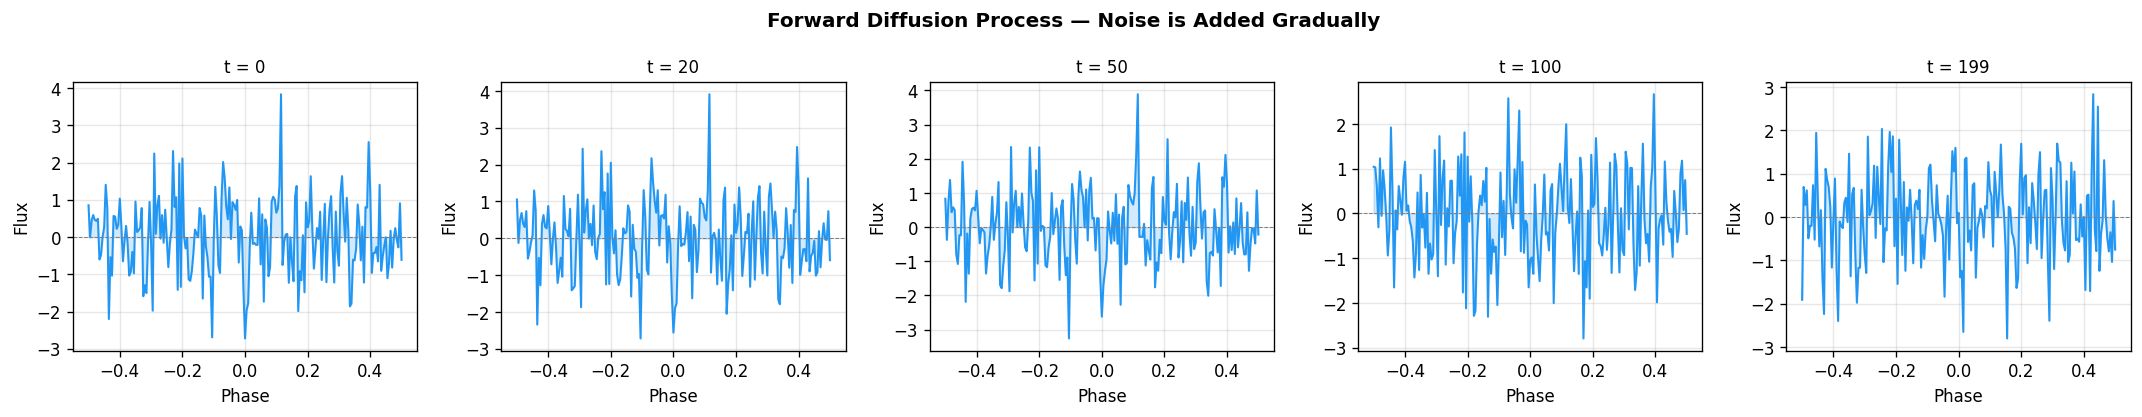

✅ Saved forward_diffusion.png


In [32]:
# ── Step 21: DDPM constants and forward process ───────────────────
T_DIFF  = 200                           # total diffusion timesteps
betas   = np.linspace(1e-4, 0.02, T_DIFF, dtype=np.float32)
alphas  = (1.0 - betas).astype(np.float32)
alpha_bars = np.cumprod(alphas).astype(np.float32)

def q_sample(x0, t, noise=None):
    """
    Forward diffusion: add noise to x0 at timestep t.
    x_{t} = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise

    Args:
        x0    : clean light curve (batch, BINS, 1) or (BINS, 1)
        t     : integer timestep index (scalar or array)
        noise : optional pre-generated noise

    Returns:
        xt    : noisy version of x0
        noise : the noise that was added
    """
    if noise is None:
        noise = np.random.randn(*x0.shape).astype(np.float32)
    if np.isscalar(t):
        ab = float(alpha_bars[t])
    else:
        ab = alpha_bars[t].reshape(-1, 1, 1)
    xt = np.sqrt(ab) * x0 + np.sqrt(1.0 - ab) * noise
    return xt.astype(np.float32), noise.astype(np.float32)

# ── Visualise the forward process ─────────────────────────────────
demo_flux = X_raw[0:1].reshape(1, BINS, 1)
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
fig.suptitle("Forward Diffusion Process — Noise is Added Gradually",
             fontsize=12, fontweight="bold")
x_ax = np.linspace(-0.5, 0.5, BINS)
steps = [0, 20, 50, 100, 199]

for ax, step in zip(axes, steps):
    xt, _ = q_sample(demo_flux, step)
    ax.plot(x_ax, xt[0,:,0], "#2196F3", lw=1.2)
    ax.fill_between(x_ax, xt[0,:,0], alpha=0.2, color="#2196F3")
    ax.axhline(0, color="gray", linestyle="--", lw=0.6)
    ax.set_title(f"t = {step}", fontsize=10)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("forward_diffusion.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved forward_diffusion.png")

In [33]:
# ── Step 22: Build 1D denoiser network ───────────────────────────

def build_denoiser(seq_len=BINS):
    """
    1D denoiser network for DDPM.
    Input:  noisy light curve (seq_len, 1) + normalised timestep scalar
    Output: predicted noise (seq_len, 1)

    Architecture: timestep embedding injected at every layer via
    broadcast addition, followed by a deep 1D conv backbone.
    """
    x_inp = keras.Input(shape=(seq_len, 1), name="noisy_lc")
    t_inp = keras.Input(shape=(1,),         name="timestep_norm")

    # Sinusoidal-style timestep embedding → broadcast to sequence
    t_emb = layers.Dense(64, activation="swish")(t_inp)
    t_emb = layers.Dense(64, activation="swish")(t_emb)
    t_seq = layers.RepeatVector(seq_len)(t_emb)   # (batch, seq_len, 64)

    # Merge with input
    x = layers.Concatenate(axis=-1)([x_inp, t_seq])   # (batch, seq_len, 65)

    # Deep conv backbone (same padding keeps seq_len constant throughout)
    x = layers.Conv1D(64,  7, padding="same", activation="relu")(x)
    x = layers.Conv1D(64,  5, padding="same", activation="relu")(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.Conv1D(128, 5, padding="same", activation="relu")(x)
    x = layers.Conv1D(64,  5, padding="same", activation="relu")(x)
    x = layers.Conv1D(32,  3, padding="same", activation="relu")(x)
    out = layers.Conv1D(1,  1, padding="same", name="predicted_noise")(x)

    return keras.Model([x_inp, t_inp], out, name="DDPM_Denoiser_1D")

denoiser = build_denoiser()
denoiser.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
denoiser.summary()

Model: "DDPM_Denoiser_1D"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ timestep_norm       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ timestep_norm[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noisy_lc            │ (None, 201, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 201, 64)   │          0 │ dense_1[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 201, 65)   │          0 │ noisy_lc[0][0],   │
│ (Concatenate)       │                   │            │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 201, 64)   │     29,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 201, 64)   │     20,544 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 201, 128)  │     41,088 │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 201, 128)  │     82,048 │ conv1d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 201, 64)   │     41,024 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 201, 32)   │      6,176 │ conv1d_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predicted_noise     │ (None, 201, 1)    │         33 │ conv1d_9[0][0]    │
│ (Conv1D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 224,385 (876.50 KB)

 Trainable params: 224,385 (876.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# ── Step 23: Create diffusion training data ───────────────────────

def make_diffusion_data(X_data, n_per=8):
    """
    For each light curve in X_data, sample n_per random timesteps,
    apply forward diffusion, and record (noisy_lc, t_norm, noise).

    Args:
        X_data  : (n_samples, BINS, 1) array of clean light curves
        n_per   : number of (timestep, noise) pairs per sample

    Returns:
        (noisy_X, t_arr), noise_arr  — ready for model.fit
    """
    noisy_X, t_arr, noises = [], [], []
    for x0 in X_data:
        x0_ = x0.reshape(BINS, 1)
        for _ in range(n_per):
            t  = np.random.randint(0, T_DIFF)
            xt, noise = q_sample(x0_[np.newaxis], t)
            noisy_X.append(xt[0])
            t_arr.append([t / T_DIFF])
            noises.append(noise[0])
    return (np.array(noisy_X, dtype=np.float32),
            np.array(t_arr,   dtype=np.float32)),             np.array(noises,  dtype=np.float32)

print("Building diffusion training set...")
(X_diff, T_diff), noise_targets = make_diffusion_data(X_train, n_per=8)
print(f"✅ Diffusion training set: {len(X_diff)} samples")
print(f"   X_diff shape    : {X_diff.shape}")
print(f"   T_diff shape    : {T_diff.shape}")
print(f"   noise_targets   : {noise_targets.shape}")

Building diffusion training set...
✅ Diffusion training set: 19448 samples
   X_diff shape    : (19448, 201, 1)
   T_diff shape    : (19448, 1)
   noise_targets   : (19448, 201, 1)


Training 1D DDPM denoiser...
(20 epochs on augmented data — ~3-5 min on T4 GPU)
Epoch 1/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.4817 - val_loss: 0.4371 - learning_rate: 0.0010
Epoch 2/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4324 - val_loss: 0.4288 - learning_rate: 0.0010
Epoch 3/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4277 - val_loss: 0.4275 - learning_rate: 0.0010
Epoch 4/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4252 - val_loss: 0.4236 - learning_rate: 0.0010
Epoch 5/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4234 - val_loss: 0.4214 - learning_rate: 0.0010
Epoch 6/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4225 - val_loss: 0.4206 - learning_rate: 0.0010
Epoch 7/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4213 - val_loss: 0.4194 - learning_rate: 0.0010
Epoch 8/20
274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4205 - val_loss: 0.4190 - learning_rate: 0.0010
Epoch 9/20
274/274 ━━━━━━━━━━━━━━━━━━━

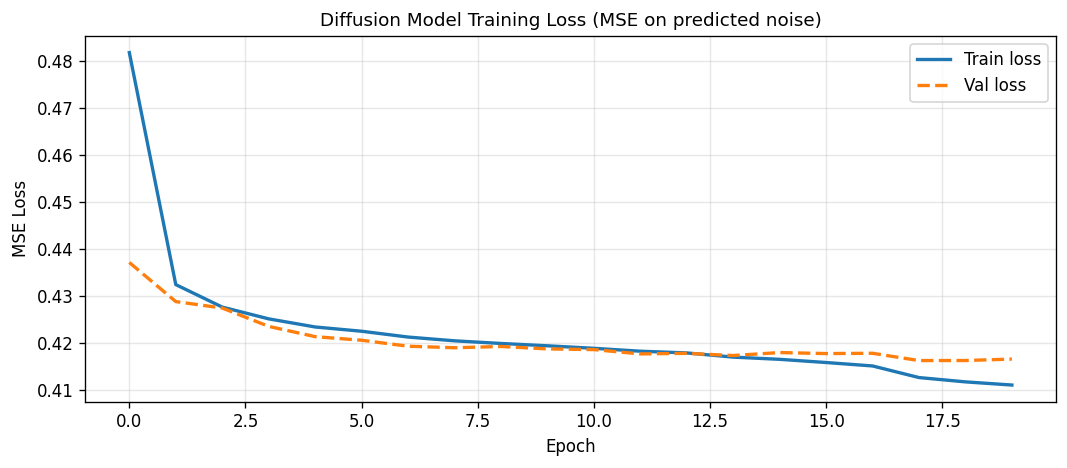

✅ Diffusion model trained
✅ Saved diffusion_training.png


In [35]:
# ── Step 24: Train the diffusion model ────────────────────────────
print("Training 1D DDPM denoiser...")
print("(20 epochs on augmented data — ~3-5 min on T4 GPU)")

diff_history = denoiser.fit(
    [X_diff, T_diff],
    noise_targets,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=5, restore_best_weights=True, monitor="val_loss"),
        keras.callbacks.ReduceLROnPlateau(
            patience=3, factor=0.5, monitor="val_loss", verbose=0)
    ]
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(diff_history.history["loss"],     label="Train loss", lw=2)
ax.plot(diff_history.history["val_loss"], label="Val loss",   lw=2, linestyle="--")
ax.set_title("Diffusion Model Training Loss (MSE on predicted noise)", fontsize=11)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("diffusion_training.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Diffusion model trained")
print("✅ Saved diffusion_training.png")

In [36]:
# ── Step 25: Generate synthetic light curves via reverse diffusion ─

def generate_sample(denoiser, seq_len=BINS, verbose_steps=False):
    """
    Run the full DDPM reverse process to generate one light curve.
    Starts from pure Gaussian noise and iteratively denoises.

    Args:
        denoiser     : trained Keras denoiser model
        seq_len      : number of bins (should match BINS)
        verbose_steps: if True, return intermediate steps for visualisation

    Returns:
        final light curve as (seq_len, 1) float32 array
        (optionally also a list of intermediate steps)
    """
    xt     = np.random.randn(seq_len, 1).astype(np.float32)
    steps_ = []

    for t in reversed(range(T_DIFF)):
        t_norm = np.array([[t / T_DIFF]], dtype=np.float32)
        noise_pred = denoiser.predict(
            [xt[np.newaxis], t_norm], verbose=0)[0]

        alpha     = float(alphas[t])
        alpha_bar = float(alpha_bars[t])
        beta      = float(betas[t])

        # DDPM reverse step
        xt = (1.0 / np.sqrt(alpha)) * (
            xt - (beta / np.sqrt(1.0 - alpha_bar)) * noise_pred
        )
        if t > 0:
            xt += np.sqrt(beta) * np.random.randn(*xt.shape).astype(np.float32)

        if verbose_steps and t % 40 == 0:
            steps_.append((t, xt.copy()))

    if verbose_steps:
        return xt, steps_
    return xt

print("Generating synthetic light curves (this may take 2-3 min)...")
n_gen    = 16
gen_lcs  = [generate_sample(denoiser) for _ in range(n_gen)]
print(f"✅ Generated {n_gen} synthetic light curves")

Generating synthetic light curves (this may take 2-3 min)...
✅ Generated 16 synthetic light curves


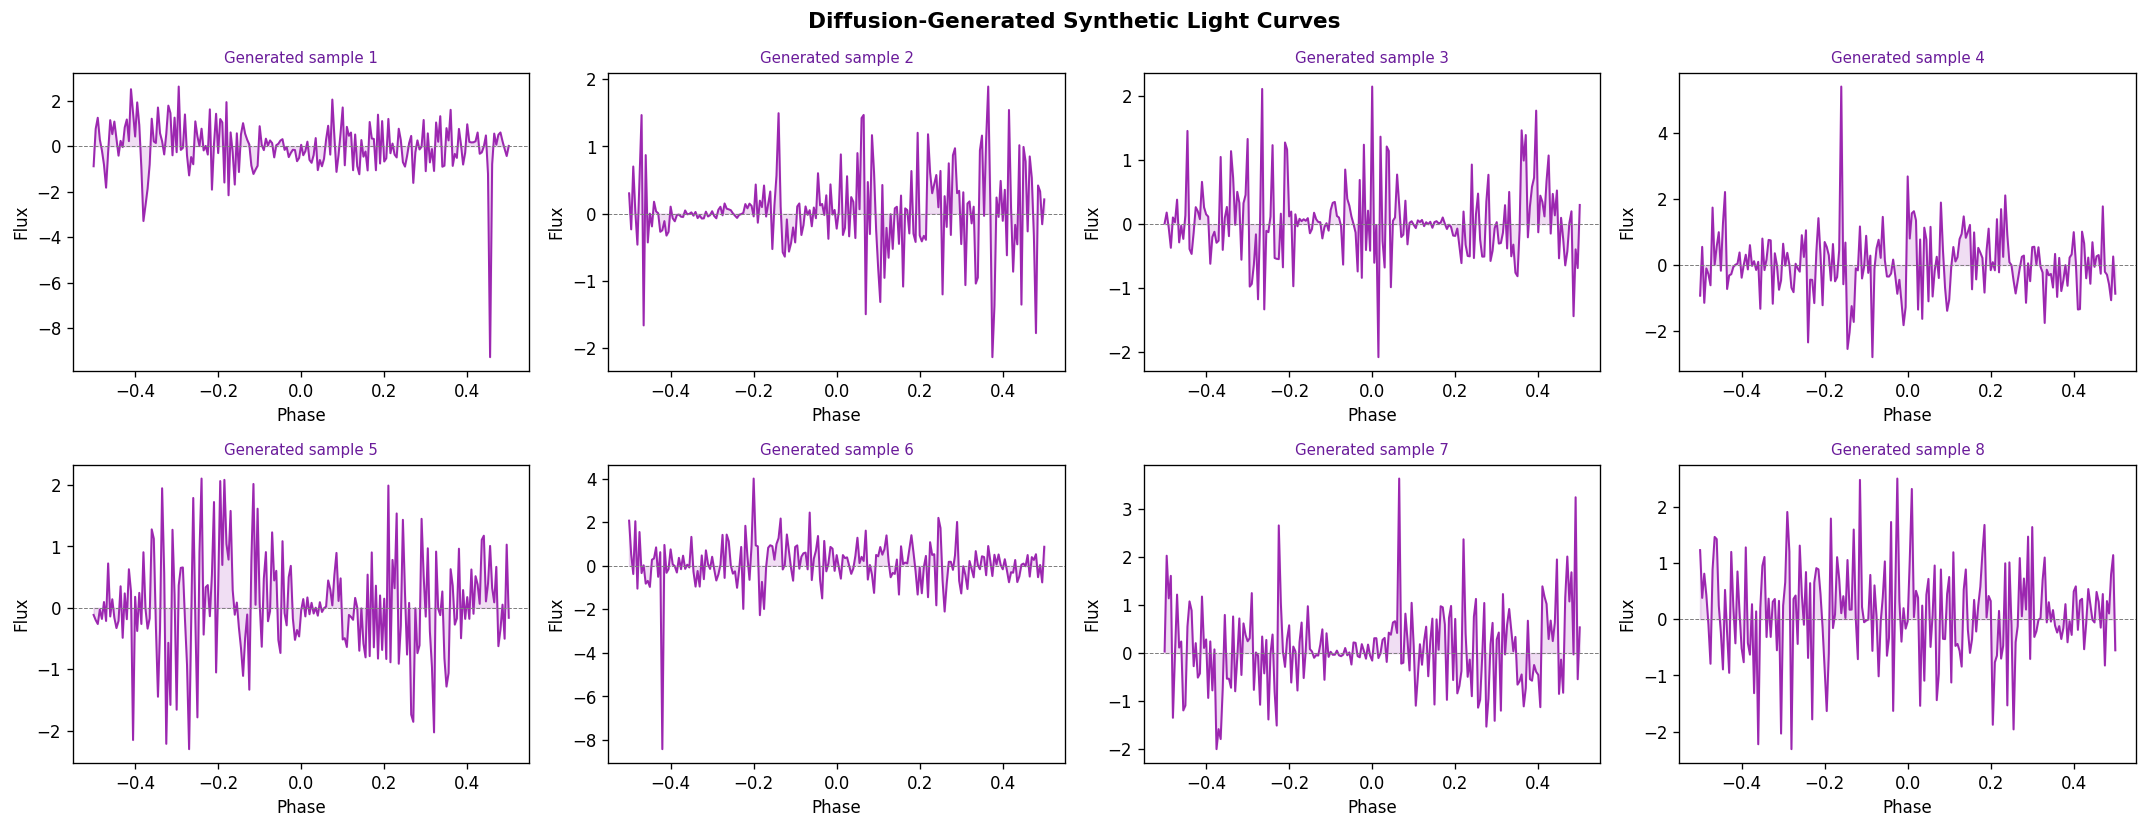

✅ Saved generated_lightcurves.png


In [37]:
# ── Step 26: Visualise generated light curves ─────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
fig.suptitle("Diffusion-Generated Synthetic Light Curves",
             fontsize=13, fontweight="bold")
x_ax = np.linspace(-0.5, 0.5, BINS)

for i, ax in enumerate(axes.flat):
    flux = gen_lcs[i].flatten()
    ax.plot(x_ax, flux, "#9C27B0", lw=1.2)
    ax.fill_between(x_ax, flux, alpha=0.15, color="#9C27B0")
    ax.axhline(0, color="gray", linestyle="--", lw=0.6)
    ax.set_title(f"Generated sample {i+1}", fontsize=9, color="#6A1B9A")
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.savefig("generated_lightcurves.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved generated_lightcurves.png")

Running reverse diffusion with intermediate visualisation...


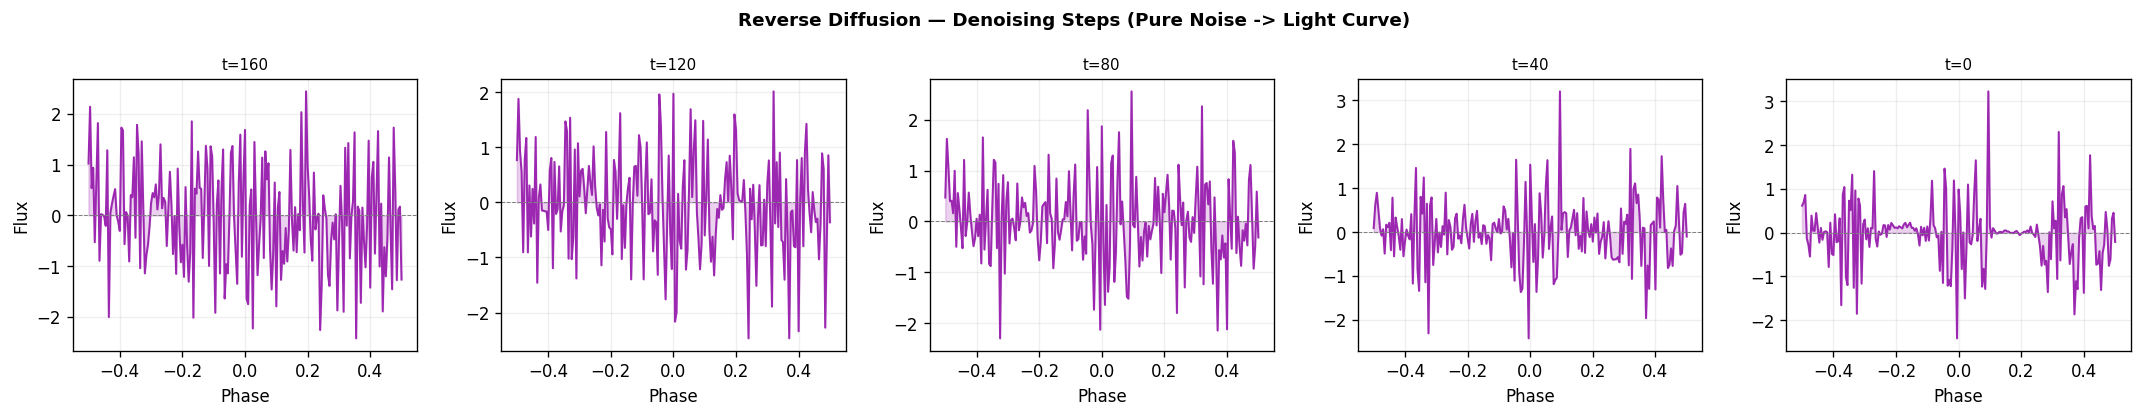

✅ Saved denoising_steps.png


In [38]:
# ── Step 27: Visualise the denoising process step by step ─────────
print("Running reverse diffusion with intermediate visualisation...")
final_lc, steps = generate_sample(denoiser, verbose_steps=True)

fig, axes = plt.subplots(1, len(steps), figsize=(18, 3.5))
fig.suptitle("Reverse Diffusion — Denoising Steps (Pure Noise -> Light Curve)",
             fontsize=11, fontweight="bold")
x_ax = np.linspace(-0.5, 0.5, BINS)

for ax, (step_t, step_lc) in zip(axes, steps):
    ax.plot(x_ax, step_lc.flatten(), "#9C27B0", lw=1.2)
    ax.fill_between(x_ax, step_lc.flatten(), alpha=0.2, color="#9C27B0")
    ax.axhline(0, color="gray", linestyle="--", lw=0.6)
    ax.set_title(f"t={step_t}", fontsize=9)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("denoising_steps.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved denoising_steps.png")

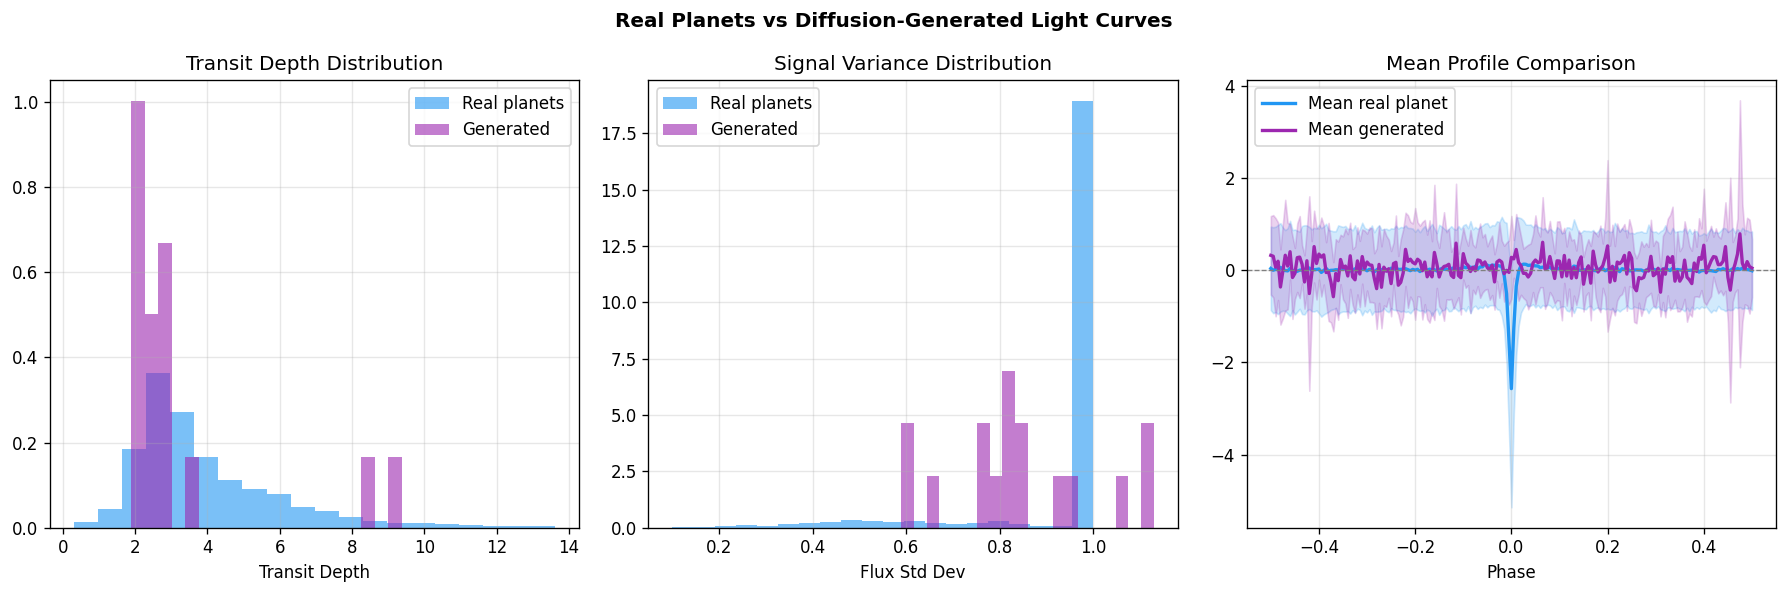

✅ Saved real_vs_generated.png


In [39]:
# ── Step 28: Compare real vs generated distributions ──────────────
# Stack generated samples into array for comparison
gen_array = np.array([g.flatten() for g in gen_lcs], dtype=np.float32)

# Compute transit depths for comparison
def get_depths(X_arr):
    deps = []
    for f in X_arr:
        bline = np.median(f[np.abs(np.linspace(-0.5,0.5,BINS)) > 0.2])
        deps.append(max(0.0, float(bline - f.min())))
    return np.array(deps)

depths_real = get_depths(planet_X)
depths_gen  = get_depths(gen_array)
stds_real   = planet_X.std(axis=1)
stds_gen    = gen_array.std(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Real Planets vs Diffusion-Generated Light Curves",
             fontsize=12, fontweight="bold")

axes[0].hist(depths_real, bins=20, alpha=0.6, color="#2196F3",
             label="Real planets", density=True)
axes[0].hist(depths_gen,  bins=20, alpha=0.6, color="#9C27B0",
             label="Generated", density=True)
axes[0].set_xlabel("Transit Depth")
axes[0].set_title("Transit Depth Distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(stds_real, bins=20, alpha=0.6, color="#2196F3",
             label="Real planets", density=True)
axes[1].hist(stds_gen,  bins=20, alpha=0.6, color="#9C27B0",
             label="Generated", density=True)
axes[1].set_xlabel("Flux Std Dev")
axes[1].set_title("Signal Variance Distribution")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

mean_gen  = gen_array.mean(axis=0)
std_gen   = gen_array.std(axis=0)
mean_real = planet_X.mean(axis=0)
std_real  = planet_X.std(axis=0)
x_ax      = np.linspace(-0.5, 0.5, BINS)
axes[2].plot(x_ax, mean_real, "#2196F3", lw=2, label="Mean real planet")
axes[2].fill_between(x_ax, mean_real-std_real, mean_real+std_real,
                     alpha=0.2, color="#2196F3")
axes[2].plot(x_ax, mean_gen, "#9C27B0", lw=2, label="Mean generated")
axes[2].fill_between(x_ax, mean_gen-std_gen, mean_gen+std_gen,
                     alpha=0.2, color="#9C27B0")
axes[2].axhline(0, color="gray", linestyle="--", lw=0.8)
axes[2].set_xlabel("Phase")
axes[2].set_title("Mean Profile Comparison")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("real_vs_generated.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved real_vs_generated.png")

In [40]:
# ── Step 29: Augment dataset + retrain CNN ────────────────────────
# Add diffusion-generated samples as class 1 (planet) to training set
# Use 40 generated samples for augmentation
n_gen_aug = 40
print(f"Generating {n_gen_aug} samples for dataset augmentation...")
gen_aug = np.array(
    [generate_sample(denoiser).flatten() for _ in range(n_gen_aug)],
    dtype=np.float32
)
y_gen_aug = np.ones(n_gen_aug, dtype=np.float32)

# Stack with existing training data
X_train_aug = np.concatenate([
    X_train.reshape(-1, BINS),
    gen_aug
], axis=0).reshape(-1, BINS, 1)
y_train_aug = np.concatenate([y_train, y_gen_aug])

print(f"Original training set : {len(X_train)}")
print(f"After augmentation    : {len(X_train_aug)}")

# Build a fresh model for the augmented training run
model_aug = build_cnn()
model_aug.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy",
             keras.metrics.AUC(name="auc"),
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall")]
)

history_aug = model_aug.fit(
    X_train_aug, y_train_aug,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=8, restore_best_weights=True,
            monitor="val_auc", mode="max"),
        keras.callbacks.ReduceLROnPlateau(
            patience=4, factor=0.5, monitor="val_loss", verbose=0)
    ],
    verbose=1
)

results_aug = model_aug.evaluate(X_eval_init, y_test_eval, verbose=0)

print("\n--- Baseline CNN vs Diffusion-Augmented CNN ---")
print(f"  Accuracy  | Baseline: {results[1]:.4f}  | Augmented: {results_aug[1]:.4f}")
print(f"  AUC       | Baseline: {results[2]:.4f}  | Augmented: {results_aug[2]:.4f}")
print(f"  Precision | Baseline: {results[3]:.4f}  | Augmented: {results_aug[3]:.4f}")
print(f"  Recall    | Baseline: {results[4]:.4f}  | Augmented: {results_aug[4]:.4f}")

Generating 40 samples for dataset augmentation...
Original training set : 2431
After augmentation    : 2471
Epoch 1/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.6463 - auc: 0.6713 - loss: 0.6507 - precision: 0.6086 - recall: 0.8336 - val_accuracy: 0.7086 - val_auc: 0.7764 - val_loss: 0.5879 - val_precision: 0.6526 - val_recall: 0.8774 - learning_rate: 1.0000e-04
Epoch 2/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6851 - auc: 0.7272 - loss: 0.6037 - precision: 0.6467 - recall: 0.8256 - val_accuracy: 0.7156 - val_auc: 0.8184 - val_loss: 0.5376 - val_precision: 0.6679 - val_recall: 0.8443 - learning_rate: 1.0000e-04
Epoch 3/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7058 - auc: 0.7640 - loss: 0.5694 - precision: 0.6762 - recall: 0.7974 - val_accuracy: 0.7413 - val_auc: 0.8318 - val_loss: 0.5037 - val_precision: 0.6935 - val_recall: 0.8538 - learning_rate: 1.0000e-04
Epoch 4/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7252 - auc: 0.7856 - l

## Part 7 — Full Model Evaluation

In [41]:
# ── Step 30: NaN cleanup + final predictions ──────────────────────
# We use the original (non-augmented) model for evaluation to compare fairly
y_prob_raw = model.predict(X_test, verbose=0).flatten()
valid_mask = np.isfinite(y_prob_raw) & np.isfinite(y_test)

if int((~valid_mask).sum()) > 0:
    print(f"Dropping {int((~valid_mask).sum())} NaN predictions")
    X_tc       = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)
    y_prob_raw = model.predict(X_tc, verbose=0).flatten()
    valid_mask = np.isfinite(y_prob_raw) & np.isfinite(y_test)
    X_eval     = X_tc[valid_mask]
else:
    X_eval = X_test[valid_mask]

y_prob      = y_prob_raw[valid_mask]
y_test_eval = y_test[valid_mask]
y_pred      = (y_prob >= 0.5).astype(int)
results     = model.evaluate(X_eval, y_test_eval, verbose=0)

print(f"\nEvaluation set  : {len(y_test_eval)} samples")
print(f"  Planets       : {int(y_test_eval.sum())}")
print(f"  False Pos     : {int((y_test_eval==0).sum())}")
print()
print("TEST RESULTS")
print("="*40)
for name, val in zip(["Loss","Accuracy","AUC","Precision","Recall"], results):
    print(f"  {name:12s}: {val:.4f}")
print()
print(classification_report(y_test_eval, y_pred,
      target_names=["False Positive","Confirmed Planet"], labels=[0,1]))
print("="*40)


Evaluation set  : 715 samples
  Planets       : 354
  False Pos     : 361

TEST RESULTS
  Loss        : 0.5344
  Accuracy    : 0.7413
  AUC         : 0.8238
  Precision   : 0.7421
  Recall      : 0.7316

                  precision    recall  f1-score   support

  False Positive       0.74      0.75      0.75       361
Confirmed Planet       0.74      0.73      0.74       354

        accuracy                           0.74       715
       macro avg       0.74      0.74      0.74       715
    weighted avg       0.74      0.74      0.74       715



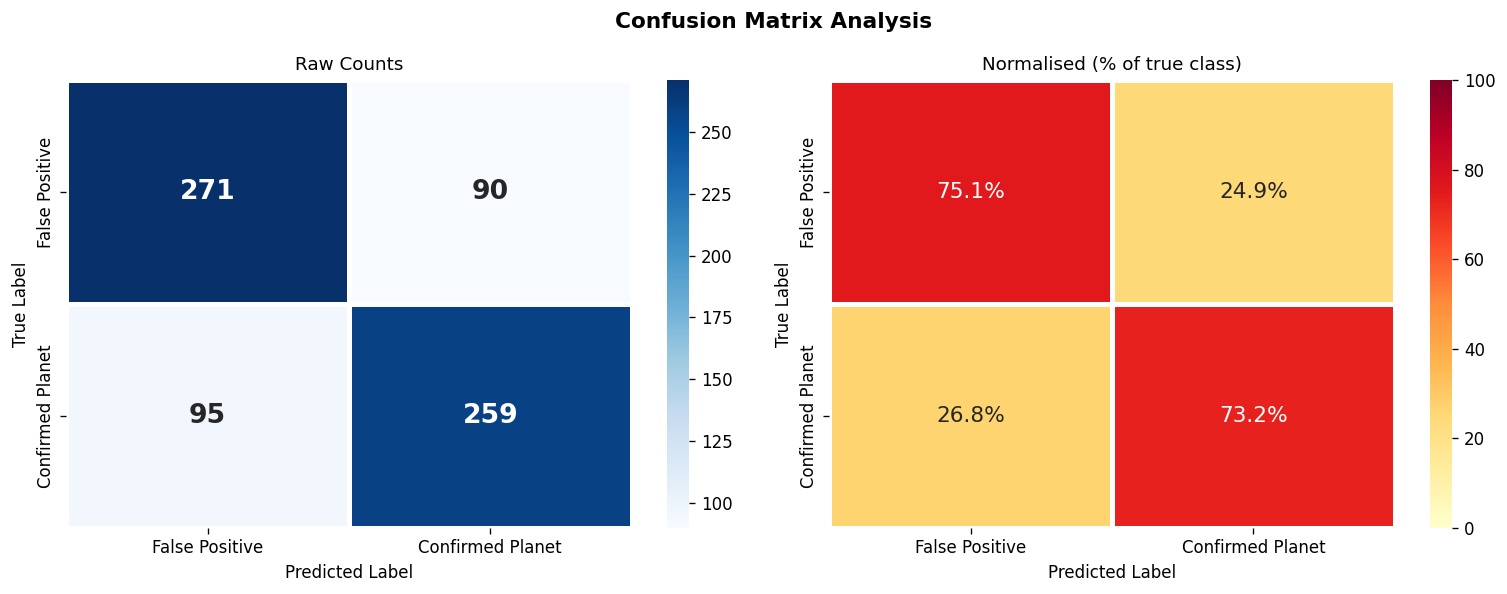

TP=259  TN=271  FP=90  FN=95
Accuracy = 0.7413    Precision = 0.7421    Recall    = 0.7316    F1        = 0.7368
✅ Saved confusion_matrix.png


In [45]:
# ── Step 31: Confusion matrix (counts + normalised) ───────────────
cm = confusion_matrix(y_test_eval, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Confusion Matrix Analysis", fontsize=13, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["False Positive","Confirmed Planet"],
            yticklabels=["False Positive","Confirmed Planet"],
            linewidths=2, linecolor="white",
            annot_kws={"size":16,"weight":"bold"})
axes[0].set_title("Raw Counts", fontsize=11)
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_norm, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1],
            xticklabels=["False Positive","Confirmed Planet"],
            yticklabels=["False Positive","Confirmed Planet"],
            linewidths=2, linecolor="white",
            annot_kws={"size":13}, vmin=0, vmax=100)
axes[1].set_title("Normalised (% of true class)", fontsize=11)
axes[1].set_ylabel("True Label")
axes[1].set_xlabel("Predicted Label")
for txt in axes[1].texts:
    txt.set_text(txt.get_text() + "%")

plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight", dpi=130)
plt.show()
print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")
print(
    f"Accuracy = {(tp+tn)/(tp+tn+fp+fn):.4f}\
    Precision = {tp/(tp+fp):.4f}\
    Recall    = {tp/(tp+fn):.4f}\
    F1        = {2*tp/(2*tp+fp+fn):.4f}")
print("✅ Saved confusion_matrix.png")

  FULL METRICS REPORT
  Accuracy      : 0.7413  (74.13%)
  Precision     : 0.7421  (74.21%)
  Recall        : 0.7316  (73.16%)
  F1 Score      : 0.7368  (73.68%)
  AUC (ROC)     : 0.8240
  Avg Precision : 0.7859
  MCC           : 0.4824


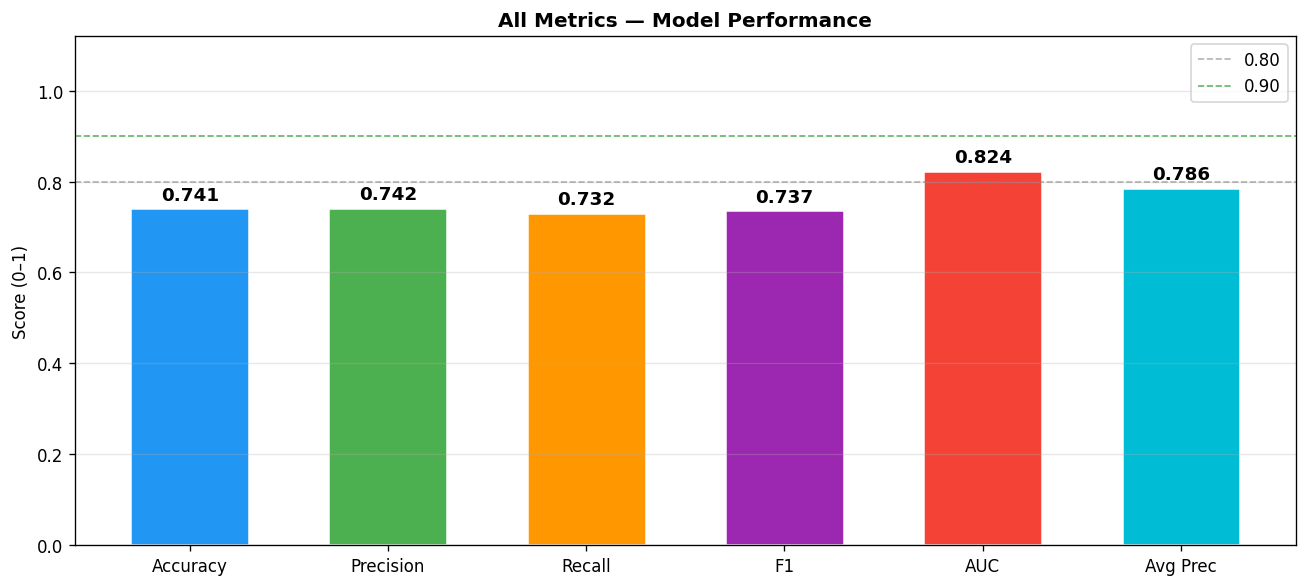

✅ Saved metrics_bar.png


In [46]:
# ── Step 32: Full metrics report + bar chart ──────────────────────
accuracy  = accuracy_score(y_test_eval, y_pred)
precision = precision_score(y_test_eval, y_pred, zero_division=0)
recall    = recall_score(y_test_eval, y_pred, zero_division=0)
f1        = f1_score(y_test_eval, y_pred, zero_division=0)
mcc       = matthews_corrcoef(y_test_eval, y_pred)
avg_prec  = average_precision_score(y_test_eval, y_prob)

fpr_arr, tpr_arr, _ = roc_curve(y_test_eval, y_prob)
roc_auc = auc(fpr_arr, tpr_arr)

print("="*55)
print("  FULL METRICS REPORT")
print("="*55)
print(f"  Accuracy      : {accuracy:.4f}  ({accuracy:.2%})")
print(f"  Precision     : {precision:.4f}  ({precision:.2%})")
print(f"  Recall        : {recall:.4f}  ({recall:.2%})")
print(f"  F1 Score      : {f1:.4f}  ({f1:.2%})")
print(f"  AUC (ROC)     : {roc_auc:.4f}")
print(f"  Avg Precision : {avg_prec:.4f}")
print(f"  MCC           : {mcc:.4f}")

mvals = [accuracy, precision, recall, f1, roc_auc, avg_prec]
mnames = ["Accuracy","Precision","Recall","F1","AUC","Avg Prec"]
colors = ["#2196F3","#4CAF50","#FF9800","#9C27B0","#F44336","#00BCD4"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(mnames, mvals, color=colors, edgecolor="white", lw=1.5, width=0.6)
ax.axhline(0.8, color="gray",  linestyle="--", lw=1, alpha=0.6, label="0.80")
ax.axhline(0.9, color="green", linestyle="--", lw=1, alpha=0.6, label="0.90")
for bar, val in zip(bars, mvals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.12)
ax.set_title("All Metrics — Model Performance", fontsize=12, fontweight="bold")
ax.set_ylabel("Score (0–1)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("metrics_bar.png", bbox_inches="tight", dpi=130)
plt.show()
print("✅ Saved metrics_bar.png")

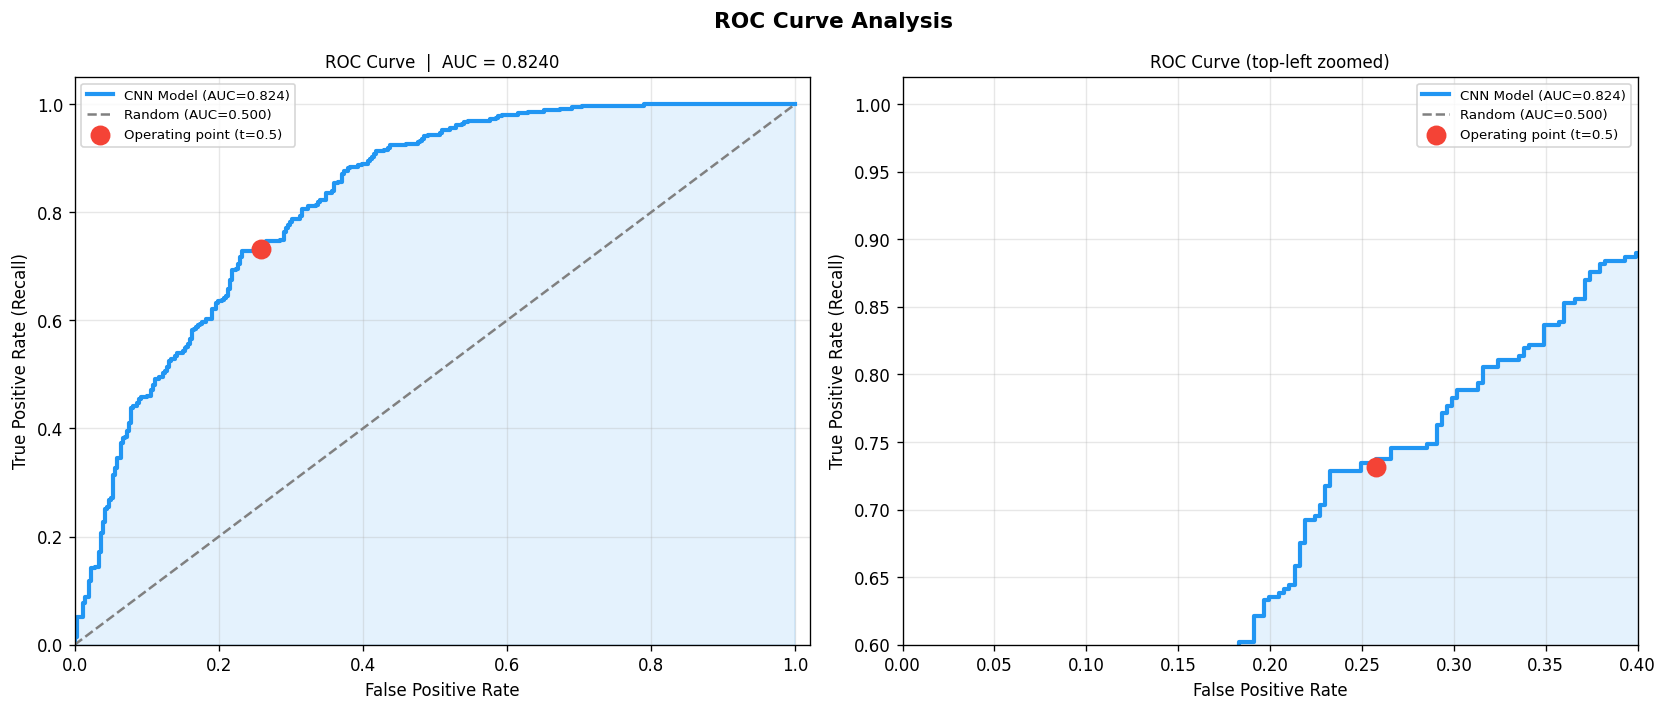

AUC = 0.8240 -> Good
✅ Saved roc_curve.png


In [47]:
# ── Step 33: ROC curve (full + zoomed) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("ROC Curve Analysis", fontsize=13, fontweight="bold")

for ax, xlim, ylim, title in [
    (axes[0], (0, 1.02), (0, 1.05), f"ROC Curve  |  AUC = {roc_auc:.4f}"),
    (axes[1], (0, 0.4),  (0.6, 1.02), "ROC Curve (top-left zoomed)")
]:
    ax.plot(fpr_arr, tpr_arr, "#2196F3", lw=2.5,
            label=f"CNN Model (AUC={roc_auc:.3f})")
    ax.plot([0,1],[0,1], "gray", linestyle="--", lw=1.5,
            label="Random (AUC=0.500)")
    ax.fill_between(fpr_arr, tpr_arr, alpha=0.12, color="#2196F3")
    ax.scatter([1-precision], [recall], color="#F44336", zorder=5, s=120,
               label="Operating point (t=0.5)")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate (Recall)")
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.tight_layout()
plt.savefig("roc_curve.png", bbox_inches="tight", dpi=130)
plt.show()

rating = ("Excellent" if roc_auc >= 0.95 else
          "Very Good" if roc_auc >= 0.90 else
          "Good"      if roc_auc >= 0.80 else "Fair")
print(f"AUC = {roc_auc:.4f} -> {rating}")
print("✅ Saved roc_curve.png")

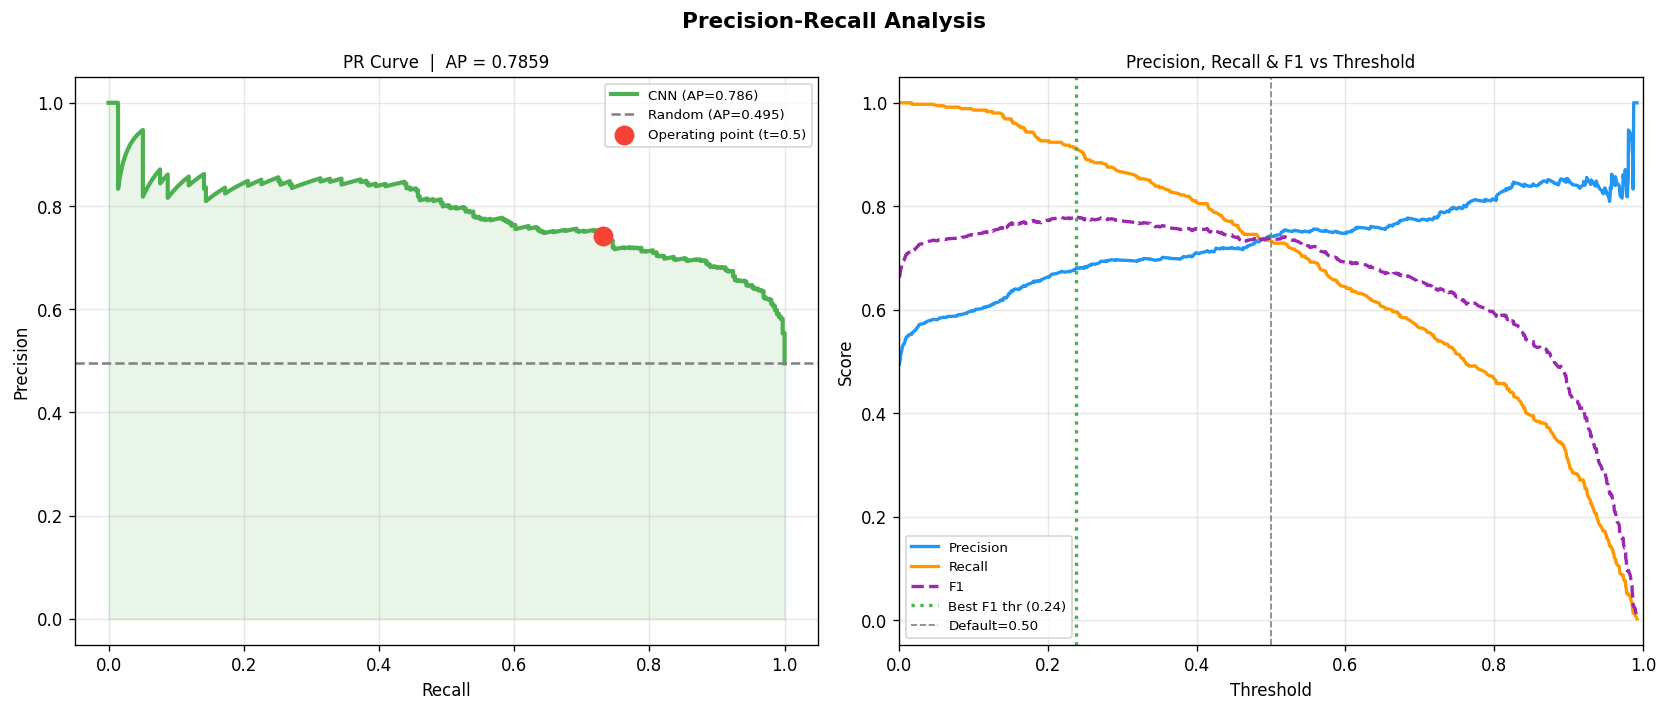

Best F1 threshold : 0.238
At that threshold : P=0.681 R=0.912 F1=0.780
✅ Saved pr_curve.png


In [48]:
# ── Step 34: Precision-Recall curve + threshold analysis ──────────
prec_arr, rec_arr, thr_pr = precision_recall_curve(y_test_eval, y_prob)
ap_score = average_precision_score(y_test_eval, y_prob)
baseline = float(y_test_eval.mean())

f1_arr = np.where(
    (prec_arr[:-1]+rec_arr[:-1]) > 0,
    2*prec_arr[:-1]*rec_arr[:-1]/(prec_arr[:-1]+rec_arr[:-1]), 0)
best_f1_idx  = int(np.argmax(f1_arr))
best_f1_thr  = float(thr_pr[best_f1_idx])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Precision-Recall Analysis", fontsize=13, fontweight="bold")

axes[0].plot(rec_arr, prec_arr, "#4CAF50", lw=2.5, label=f"CNN (AP={ap_score:.3f})")
axes[0].axhline(baseline, color="gray", linestyle="--", lw=1.5,
                label=f"Random (AP={baseline:.3f})")
axes[0].fill_between(rec_arr, prec_arr, alpha=0.12, color="#4CAF50")
axes[0].scatter([recall], [precision], color="#F44336", zorder=5, s=120,
                label="Operating point (t=0.5)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"PR Curve  |  AP = {ap_score:.4f}", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(thr_pr, prec_arr[:-1], "#2196F3", lw=2, label="Precision")
axes[1].plot(thr_pr, rec_arr[:-1],  "#FF9800", lw=2, label="Recall")
axes[1].plot(thr_pr, f1_arr,        "#9C27B0", lw=2, linestyle="--", label="F1")
axes[1].axvline(best_f1_thr, color="#4CAF50", linestyle=":", lw=2,
                label=f"Best F1 thr ({best_f1_thr:.2f})")
axes[1].axvline(0.5, color="gray", linestyle="--", lw=1, label="Default=0.50")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].set_title("Precision, Recall & F1 vs Threshold", fontsize=10)
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("pr_curve.png", bbox_inches="tight", dpi=130)
plt.show()
print(f"Best F1 threshold : {best_f1_thr:.3f}")
print(f"At that threshold : P={prec_arr[best_f1_idx]:.3f} R={rec_arr[best_f1_idx]:.3f} F1={f1_arr[best_f1_idx]:.3f}")
print("✅ Saved pr_curve.png")

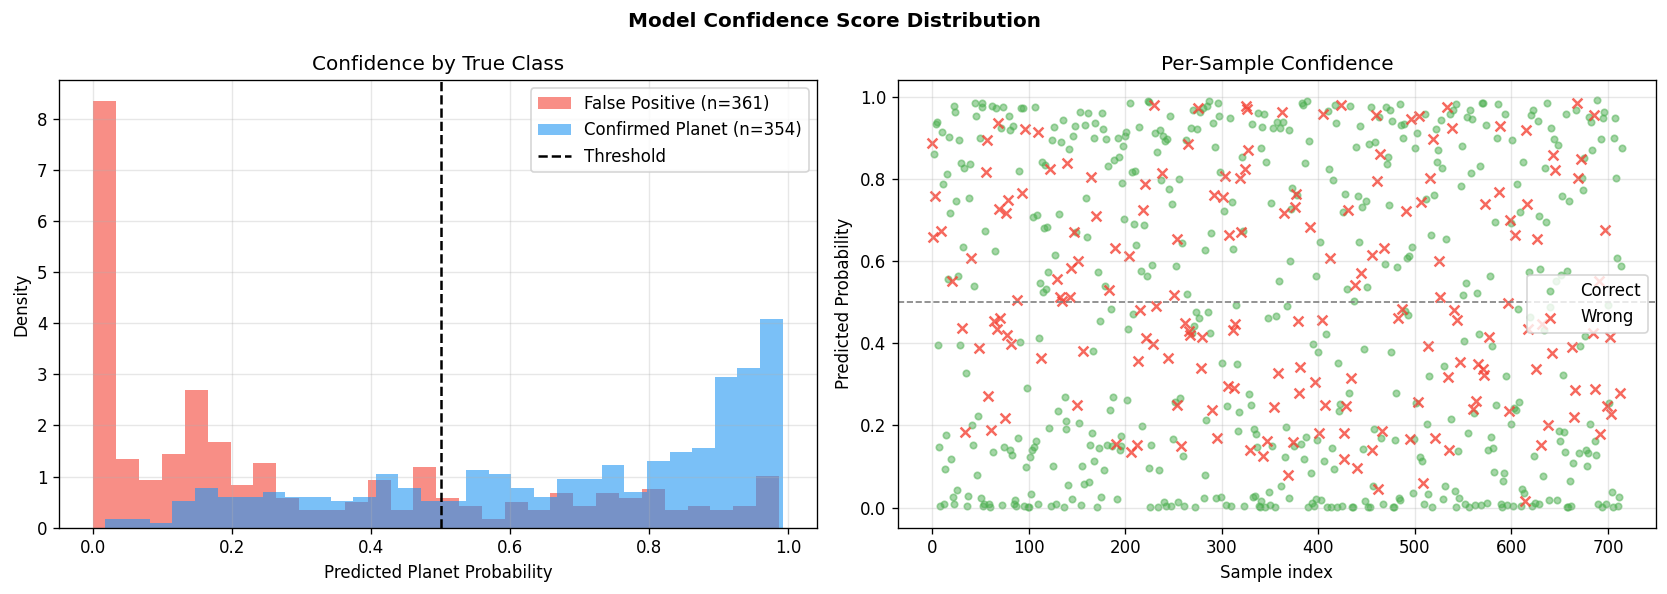

Planets   — mean: 0.683  std: 0.270
False Pos — mean: 0.297  std: 0.303
Separation: 0.385
Separation: 0.032
✅ Saved confidence_dist.png


In [49]:
# ── Step 35: Confidence distribution ─────────────────────────────
planets_p = y_prob[y_test_eval == 1]
fp_p      = y_prob[y_test_eval == 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Confidence Score Distribution", fontsize=12, fontweight="bold")

axes[0].hist(fp_p,      bins=30, alpha=0.6, color="#F44336",
             label=f"False Positive (n={len(fp_p)})", density=True)
axes[0].hist(planets_p, bins=30, alpha=0.6, color="#2196F3",
             label=f"Confirmed Planet (n={len(planets_p)})", density=True)
axes[0].axvline(0.5, color="black", linestyle="--", lw=1.5, label="Threshold")
axes[0].set_xlabel("Predicted Planet Probability")
axes[0].set_ylabel("Density")
axes[0].set_title("Confidence by True Class")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

correct_mask = (y_pred == y_test_eval)
axes[1].scatter(np.where(correct_mask)[0],  y_prob[correct_mask],
                color="#4CAF50", alpha=0.5, s=15, label="Correct")
axes[1].scatter(np.where(~correct_mask)[0], y_prob[~correct_mask],
                color="#F44336", alpha=0.8, s=35, marker="x", label="Wrong")
axes[1].axhline(0.5, color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("Sample index")
axes[1].set_ylabel("Predicted Probability")
axes[1].set_title("Per-Sample Confidence")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("confidence_dist.png", bbox_inches="tight", dpi=130)
plt.show()
print(f"Planets   — mean: {planets_p.mean():.3f}  std: {planets_p.std():.3f}")
print(f"False Pos — mean: {fp_p.mean():.3f}  std: {fp_p.std():.3f}")
print(f"Separation: {abs(planets_p.mean()-fp_p.mean()):.3f}")
print(f"Separation: {abs(planets_p.std()-fp_p.std()):.3f}")
print("✅ Saved confidence_dist.png")

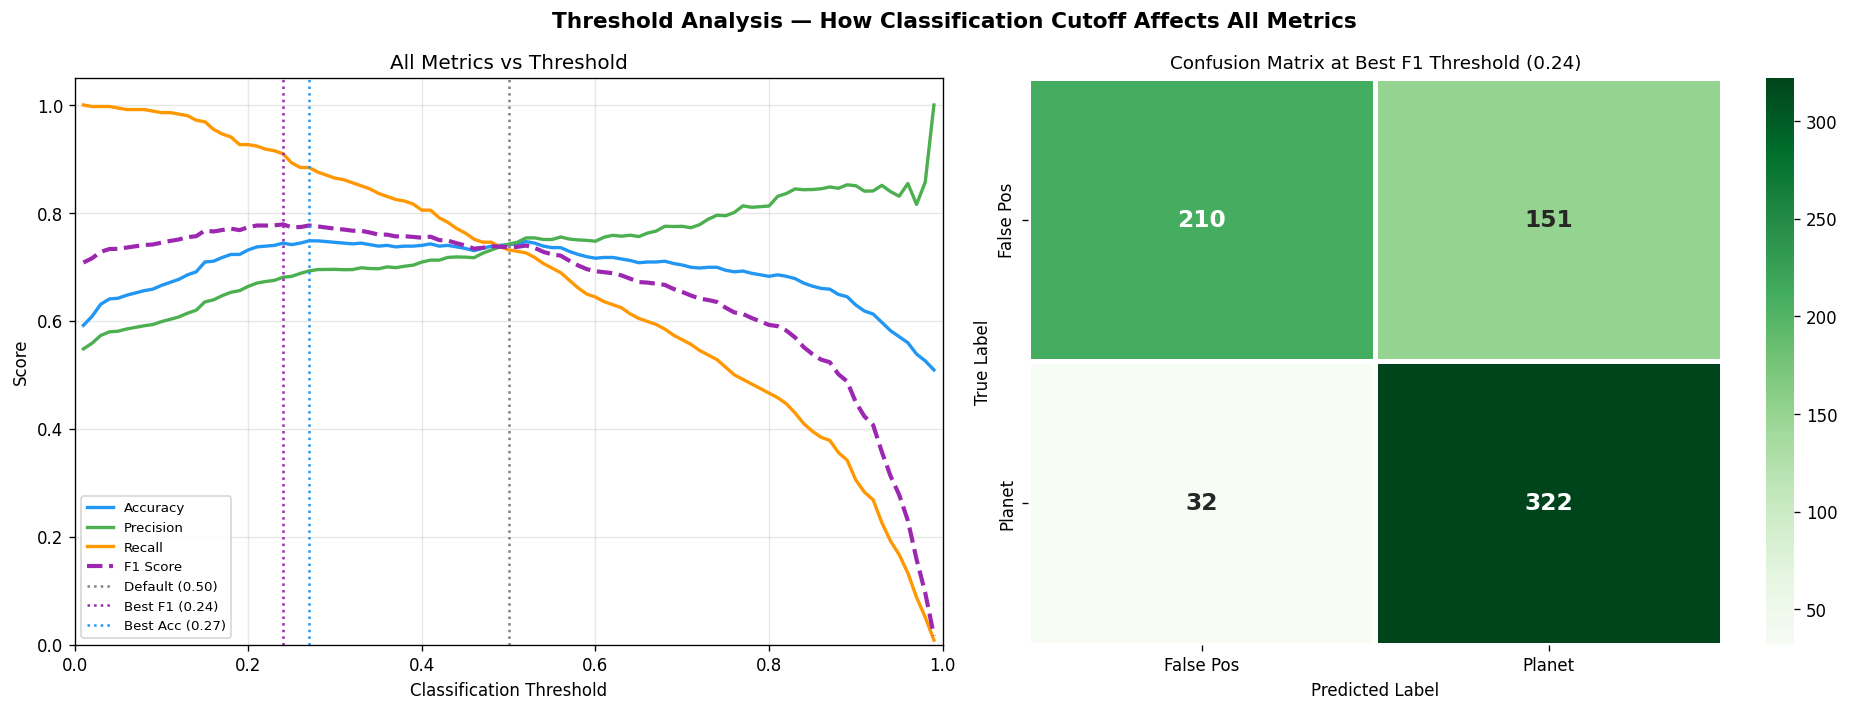

Default (0.50)      -> F1=0.737,       Acc=0.741
Best F1  (0.24)     -> F1=0.779,       Acc=0.744
Best Acc (0.27)     -> Acc=0.748,     F1=0.777
Best F1 threshold : 0.240 At that threshold : P=0.681 R=0.910 F1=0.779
✅ Saved threshold_analysis.png


In [52]:
# ── Step 35b: Threshold Analysis — how cutoff affects all metrics ─
# Shows the trade-off between precision and recall at every threshold
# and identifies the optimal cutoff for F1 and accuracy

thresholds = np.linspace(0.01, 0.99, 99)
accs, precs, recs, f1s = [], [], [], []

for t in thresholds:
    yp = (y_prob >= t).astype(int)
    accs.append(accuracy_score(y_test_eval, yp))
    precs.append(precision_score(y_test_eval, yp, zero_division=0))
    recs.append(recall_score(y_test_eval, yp, zero_division=0))
    f1s.append(f1_score(y_test_eval, yp, zero_division=0))

best_f1_t  = float(thresholds[np.argmax(f1s)])
best_acc_t = float(thresholds[np.argmax(accs)])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Threshold Analysis — How Classification Cutoff Affects All Metrics',
             fontsize=13, fontweight='bold')

# Plot 1: all metrics vs threshold
axes[0].plot(thresholds, accs,  color='#2196F3', lw=2,   label='Accuracy')
axes[0].plot(thresholds, precs, color='#4CAF50', lw=2,   label='Precision')
axes[0].plot(thresholds, recs,  color='#FF9800', lw=2,   label='Recall')
axes[0].plot(thresholds, f1s,   color='#9C27B0', lw=2.5, linestyle='--', label='F1 Score')
axes[0].axvline(0.5,        color='gray',    linestyle=':',  lw=1.5, label='Default (0.50)')
axes[0].axvline(best_f1_t,  color='#9C27B0', linestyle=':', lw=1.5, label=f'Best F1 ({best_f1_t:.2f})')
axes[0].axvline(best_acc_t, color='#2196F3', linestyle=':', lw=1.5, label=f'Best Acc ({best_acc_t:.2f})')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics vs Threshold')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)

# Plot 2: confusion matrix at best F1 threshold
from sklearn.metrics import confusion_matrix
import seaborn as sns
y_pred_best = (y_prob >= best_f1_t).astype(int)
cm_best = confusion_matrix(y_test_eval, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['False Pos', 'Planet'],
            yticklabels=['False Pos', 'Planet'],
            linewidths=2, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_title(f'Confusion Matrix at Best F1 Threshold ({best_f1_t:.2f})', fontsize=11)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight', dpi=130)
plt.show()

print(f'Default (0.50)      -> F1={f1:.3f},       Acc={accuracy:.3f}')
print(f'Best F1  ({best_f1_t:.2f})     -> F1={max(f1s):.3f},       Acc={accs[np.argmax(f1s)]:.3f}')
print(f'Best Acc ({best_acc_t:.2f})     -> Acc={max(accs):.3f},     F1={f1s[np.argmax(accs)]:.3f}')
print(f"Best F1 threshold : {best_f1_t:.3f} At that threshold : P={precs[np.argmax(f1s)]:.3f} R={recs[np.argmax(f1s)]:.3f} F1={f1s[np.argmax(f1s)]:.3f}")
print('✅ Saved threshold_analysis.png')

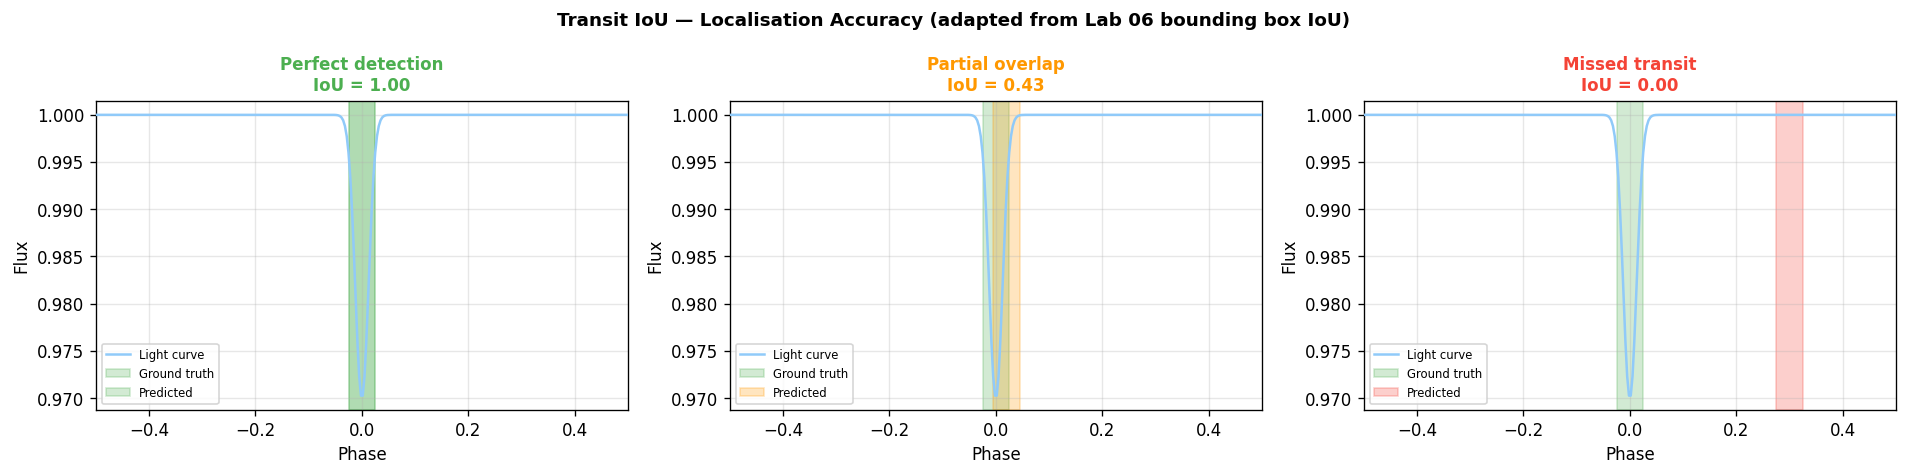

Perfect : 1.0000
Partial : 0.4286
Missed  : 0.0000
✅ Saved transit_iou.png


In [53]:
# ── Step 36: IoU applied to transit detection ─────────────────────

def transit_iou(pred_c, pred_w, true_c, true_w):
    """
    1D IoU between a predicted transit window and the ground truth.
    Analogous to bounding box IoU from object detection.
    """
    pm, px = pred_c - pred_w/2, pred_c + pred_w/2
    tm, tx = true_c - true_w/2, true_c + true_w/2
    inter  = max(0.0, min(px,tx) - max(pm,tm))
    union  = (px-pm) + (tx-tm) - inter
    return inter/union if union > 0 else 0.0

cases = [
    ("Perfect detection",  0.00, 0.05, 0.00, 0.05, "#4CAF50"),
    ("Partial overlap",    0.02, 0.05, 0.00, 0.05, "#FF9800"),
    ("Missed transit",     0.30, 0.05, 0.00, 0.05, "#F44336"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Transit IoU — Localisation Accuracy (adapted from Lab 06 bounding box IoU)",
             fontsize=11, fontweight="bold")
x_ax = np.linspace(-0.5, 0.5, 300)

for ax, (title, pc, pw, tc, tw, color) in zip(axes, cases):
    iou  = transit_iou(pc, pw, tc, tw)
    flux = 1.0 - 0.03*np.exp(-((x_ax-tc)**2)/(2*(tw/4)**2))
    ax.plot(x_ax, flux, "#90CAF9", lw=1.5, zorder=3, label="Light curve")
    ax.axvspan(tc-tw/2, tc+tw/2, alpha=0.25, color="#4CAF50", label="Ground truth")
    ax.axvspan(pc-pw/2, pc+pw/2, alpha=0.25, color=color,    label="Predicted")
    ax.set_title(f"{title}\nIoU = {iou:.2f}", fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")
    ax.set_xlim(-0.5, 0.5)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("transit_iou.png", bbox_inches="tight", dpi=120)
plt.show()
print(f"Perfect : {transit_iou(0.0, 0.05, 0.0, 0.05):.4f}")
print(f"Partial : {transit_iou(0.02,0.05, 0.0, 0.05):.4f}")
print(f"Missed  : {transit_iou(0.3, 0.05, 0.0, 0.05):.4f}")
print("✅ Saved transit_iou.png")

Embedding shape: (715, 256)

CLIP-Style Zero-Shot Results
  Accuracy  : 0.7315 (73.15%)
  Precision : 0.7143 (71.43%)
  Recall    : 0.7627 (76.27%)
  F1        : 0.7377


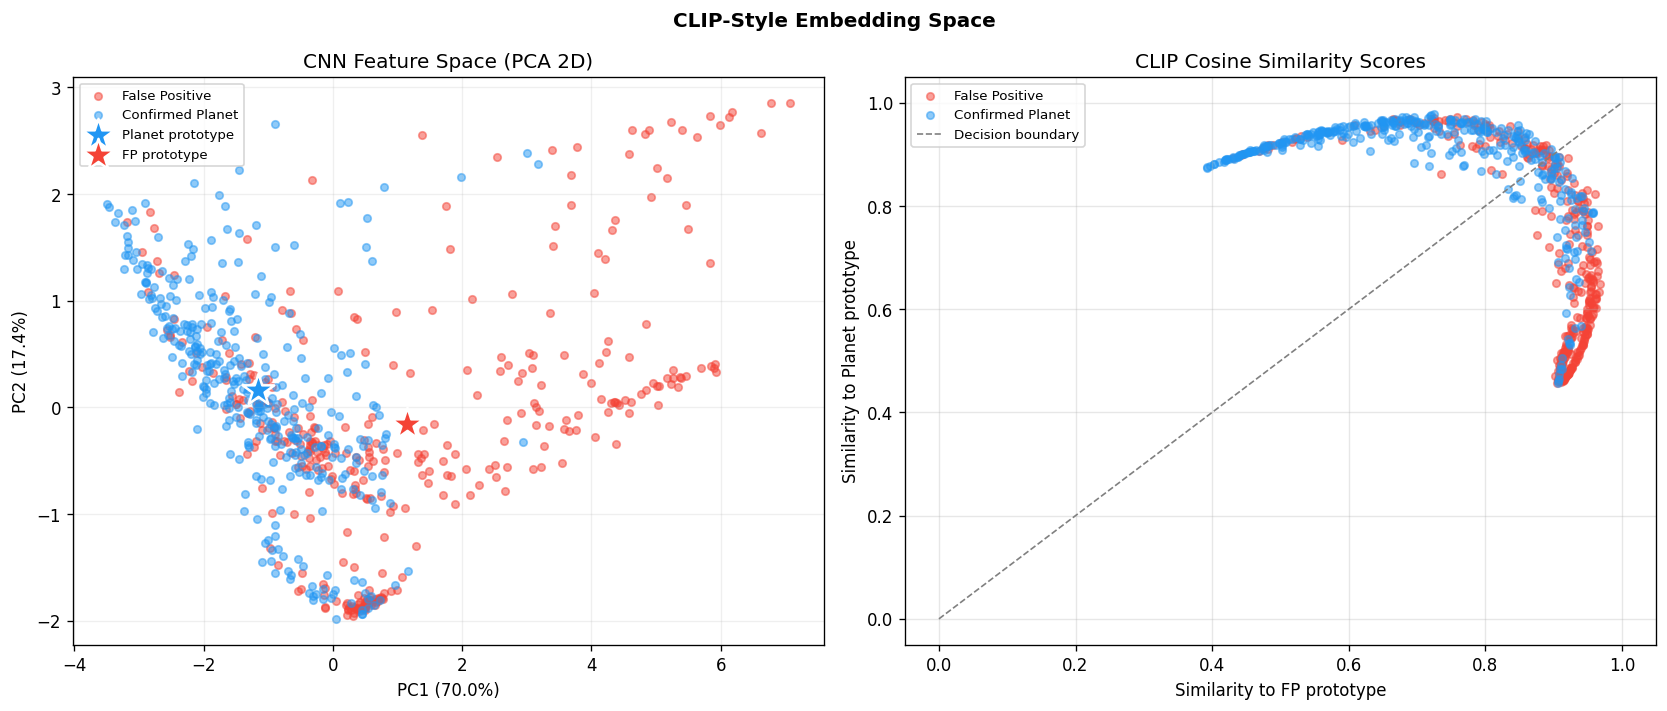


  CNN vs CLIP Comparison
  Accuracy      CNN:0.7413  CLIP:0.7315  <- CNN
  F1            CNN:0.7368  CLIP:0.7377  <- CLIP
✅ Saved clip_analysis.png


In [54]:
# ── Step 37: CLIP-style embedding analysis ────────────────────────

# Extract feature embeddings from Dense(256) penultimate layer
embedding_model = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer("features_256").output
)
X_clean    = np.nan_to_num(X_eval, nan=0.0)
embeddings = embedding_model.predict(X_clean, verbose=0)
print(f"Embedding shape: {embeddings.shape}")

# Class prototypes
p_mask  = y_test_eval == 1
fp_mask = y_test_eval == 0
p_proto  = embeddings[p_mask].mean(axis=0, keepdims=True)
fp_proto = embeddings[fp_mask].mean(axis=0, keepdims=True)

# Cosine similarity classification
sim_p  = cosine_similarity(embeddings, p_proto).flatten()
sim_fp = cosine_similarity(embeddings, fp_proto).flatten()
clip_pred = (sim_p > sim_fp).astype(int)

clip_acc  = accuracy_score(y_test_eval,  clip_pred)
clip_f1   = f1_score(y_test_eval,        clip_pred, zero_division=0)
clip_prec = precision_score(y_test_eval, clip_pred, zero_division=0)
clip_rec  = recall_score(y_test_eval,    clip_pred, zero_division=0)

print("\nCLIP-Style Zero-Shot Results")
print("="*40)
print(f"  Accuracy  : {clip_acc:.4f} ({clip_acc:.2%})")
print(f"  Precision : {clip_prec:.4f} ({clip_prec:.2%})")
print(f"  Recall    : {clip_rec:.4f} ({clip_rec:.2%})")
print(f"  F1        : {clip_f1:.4f}")
print("="*40)

# Visualise embedding space
pca    = PCA(n_components=2, random_state=SEED)
emb_2d = pca.fit_transform(embeddings)
pt_2d  = pca.transform(np.vstack([p_proto, fp_proto]))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("CLIP-Style Embedding Space", fontsize=12, fontweight="bold")

axes[0].scatter(emb_2d[fp_mask,0], emb_2d[fp_mask,1],
                c="#F44336", alpha=0.5, s=20, label="False Positive")
axes[0].scatter(emb_2d[p_mask,0],  emb_2d[p_mask,1],
                c="#2196F3", alpha=0.5, s=20, label="Confirmed Planet")
axes[0].scatter(pt_2d[0,0], pt_2d[0,1], c="#2196F3",
                marker="*", s=400, zorder=5, edgecolor="white", lw=1.5,
                label="Planet prototype")
axes[0].scatter(pt_2d[1,0], pt_2d[1,1], c="#F44336",
                marker="*", s=400, zorder=5, edgecolor="white", lw=1.5,
                label="FP prototype")
axes[0].set_title("CNN Feature Space (PCA 2D)")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.2)

axes[1].scatter(sim_fp[fp_mask], sim_p[fp_mask],
                c="#F44336", alpha=0.5, s=20, label="False Positive")
axes[1].scatter(sim_fp[p_mask],  sim_p[p_mask],
                c="#2196F3", alpha=0.5, s=20, label="Confirmed Planet")
axes[1].plot([0,1],[0,1], "gray", linestyle="--", lw=1, label="Decision boundary")
axes[1].set_xlabel("Similarity to FP prototype")
axes[1].set_ylabel("Similarity to Planet prototype")
axes[1].set_title("CLIP Cosine Similarity Scores")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("clip_analysis.png", bbox_inches="tight", dpi=130)
plt.show()

print("\n" + "="*50)
print("  CNN vs CLIP Comparison")
print("="*50)
for met, cv, clv in [("Accuracy",accuracy,clip_acc),
                      ("F1",f1,clip_f1)]:
    arrow = "<- CNN" if cv >= clv else "<- CLIP"
    print(f"  {met:12s}  CNN:{cv:.4f}  CLIP:{clv:.4f}  {arrow}")
print("✅ Saved clip_analysis.png")

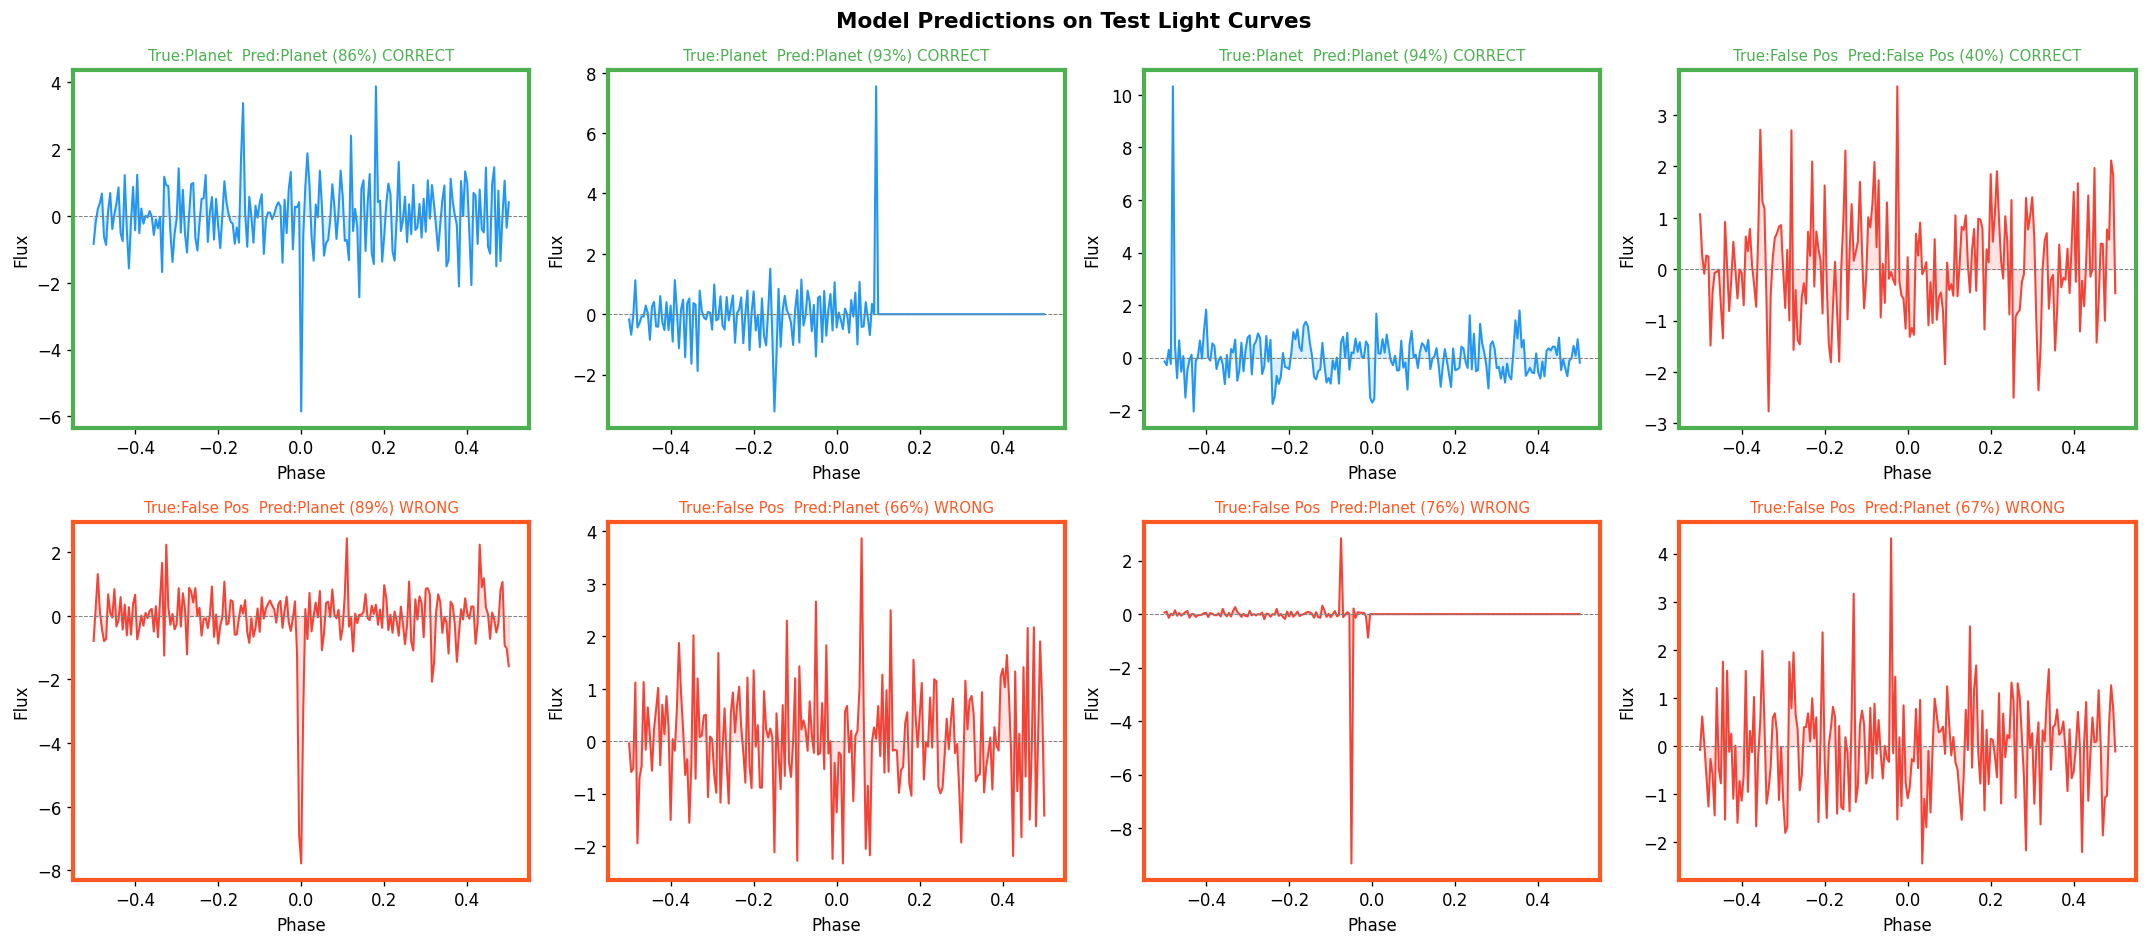

✅ Saved test_predictions.png


In [56]:
# ── Step 38: Test set prediction grid ────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Model Predictions on Test Light Curves",
             fontsize=13, fontweight="bold")
x_axis = np.linspace(-0.5, 0.5, BINS)

correct_idx = np.where(y_pred == y_test_eval)[0][:4]
wrong_idx   = np.where(y_pred != y_test_eval)[0][:4]
indices     = list(correct_idx) + list(wrong_idx)

for i, idx in enumerate(indices[:8]):
    ax     = axes[i//4][i%4]
    flux   = X_eval[idx].flatten()
    prob   = float(y_prob[idx])
    cor    = bool(y_pred[idx] == y_test_eval[idx])
    tlbl   = "Planet"    if y_test_eval[idx] == 1 else "False Pos"
    plbl   = "Planet"    if y_pred[idx]       == 1 else "False Pos"
    color  = "#2196F3"   if y_test_eval[idx]  == 1 else "#F44336"
    border = "#4CAF50"   if cor else "#FF5722"
    ax.plot(x_axis, flux, color=color, lw=1.2)
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    ax.axhline(0, color="gray", linestyle="--", lw=0.6)
    for sp in ax.spines.values():
        sp.set_edgecolor(border)
        sp.set_linewidth(2.5)
    status = "CORRECT" if cor else "WRONG"
    ax.set_title(f"True:{tlbl}  Pred:{plbl} ({prob:.0%}) {status}", fontsize=9, color=border)
    ax.set_xlabel("Phase")
    ax.set_ylabel("Flux")

plt.tight_layout()
plt.savefig("test_predictions.png", bbox_inches="tight", dpi=120)
plt.show()
print("✅ Saved test_predictions.png")

## Part 8 — Summary, Save, and Predict

In [57]:
# ── Step 39: Complete metrics summary for slides ──────────────────
import time

if model is not None and X_eval is not None:
    start = time.time()
    _ = model.predict(X_eval[:10], verbose=0)
    ms = (time.time() - start) / 10 * 1000
else:
    ms = 0.0

print("=" * 58)
print("  COMPLETE EVALUATION SUMMARY")
print("=" * 58)

print(f"\nCLASSIFICATION METRICS (threshold = 0.50)")
print(f"  Accuracy      : {accuracy:.4f}  ({accuracy:.2%})"   if accuracy  is not None else "  Accuracy      : not yet computed")
print(f"  Precision     : {precision:.4f}  ({precision:.2%})" if precision is not None else "  Precision     : not yet computed")
print(f"  Recall        : {recall:.4f}  ({recall:.2%})"       if recall    is not None else "  Recall        : not yet computed")
print(f"  F1 Score      : {f1:.4f}  ({f1:.2%})"              if f1        is not None else "  F1 Score      : not yet computed")
print(f"  MCC           : {mcc:.4f}"                          if mcc       is not None else "  MCC           : not yet computed")

print(f"\nCURVE METRICS")
print(f"  ROC AUC       : {roc_auc:.4f}"   if roc_auc  is not None else "  ROC AUC       : not yet computed")
print(f"  Avg Precision : {avg_prec:.4f}"  if avg_prec is not None else "  Avg Precision : not yet computed")
print(f"  Best F1 thr   : {best_f1_thr:.3f}  (F1={float(f1_arr[int(best_f1_idx)]):.3f})")

print(f"\nCONFUSION MATRIX")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")

print(f"\nCLIP ZERO-SHOT")
print(f"  Accuracy      : {clip_acc:.4f}")
print(f"  F1            : {clip_f1:.4f}")

print(f"\nDIFFUSION AUGMENTED CNN")
print(f"  AUC (augmented): {results_aug[2]:.4f}  (baseline: {results[2]:.4f})" if (results is not None and results_aug is not None and results_aug[2] != 0) else "  AUC (augmented): run diffusion cell first")

print(f"\nSPEED")
print(f"  Avg prediction: {ms:.1f} ms per light curve")

print(f"\nTRAINING HISTORY")
if history is not None:
    print(f"  Best val AUC  : {max(history.history['val_auc']):.4f}")
    print(f"  Best val Acc  : {max(history.history['val_accuracy']):.4f}")
    print(f"  Total epochs  : {len(history.history['loss'])}")
else:
    print("  History not available — run training or resume cell first")

print("=" * 58)

  COMPLETE EVALUATION SUMMARY

CLASSIFICATION METRICS (threshold = 0.50)
  Accuracy      : 0.7413  (74.13%)
  Precision     : 0.7421  (74.21%)
  Recall        : 0.7316  (73.16%)
  F1 Score      : 0.7368  (73.68%)
  MCC           : 0.4824

CURVE METRICS
  ROC AUC       : 0.8240
  Avg Precision : 0.7859
  Best F1 thr   : 0.238  (F1=0.780)

CONFUSION MATRIX
  TP=259  TN=271  FP=90  FN=95

CLIP ZERO-SHOT
  Accuracy      : 0.7315
  F1            : 0.7377

DIFFUSION AUGMENTED CNN
  AUC (augmented): 0.8348  (baseline: 0.8238)

SPEED
  Avg prediction: 220.4 ms per light curve

TRAINING HISTORY
  Best val AUC  : 0.8784
  Best val Acc  : 0.7809
  Total epochs  : 23


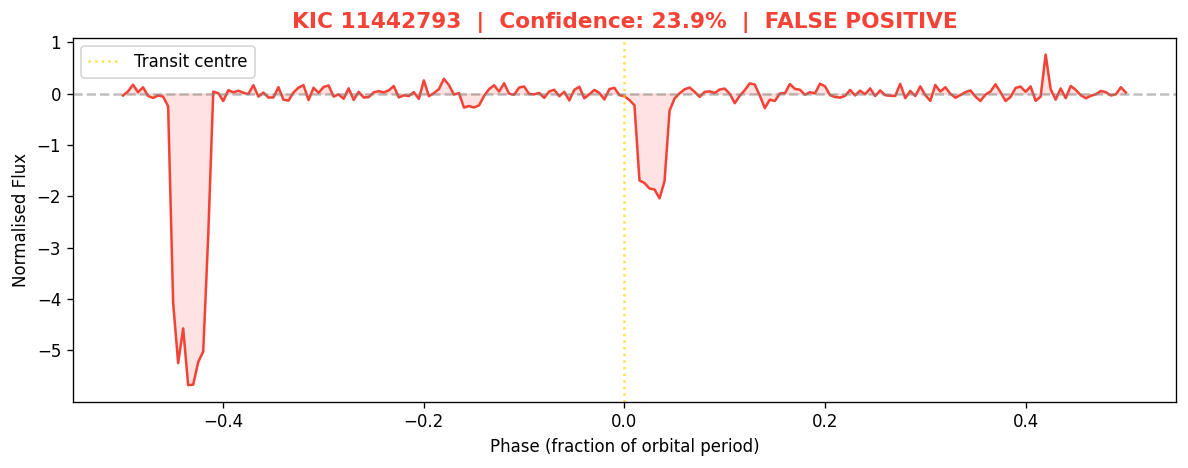

Score: 0.2395  ->  FALSE POSITIVE
✅ Saved single_prediction.png


In [58]:
# ── Step 40: Predict on any Kepler star ───────────────────────────
# Edit these values to test any KOI
KEPLER_ID = 11442793   # Kepler-90
PERIOD    = 14.44912
T0        = 2.2

flux = download_and_fold(KEPLER_ID, PERIOD, T0)

if flux is not None:
    prob    = float(model.predict(flux.reshape(1, BINS, 1), verbose=0)[0][0])
    verdict = "PLANET DETECTED" if prob >= 0.5 else "FALSE POSITIVE"
    color   = "#2196F3"         if prob >= 0.5 else "#F44336"

    fig, ax = plt.subplots(figsize=(10, 4))
    x_axis  = np.linspace(-0.5, 0.5, BINS)
    ax.plot(x_axis, flux, color=color, lw=1.5)
    ax.fill_between(x_axis, flux, alpha=0.15, color=color)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(0, color="gold", linestyle=":", lw=1.5, alpha=0.7, label="Transit centre")
    ax.set_title(f"KIC {KEPLER_ID}  |  Confidence: {prob:.1%}  |  {verdict}",
                 fontsize=13, fontweight="bold", color=color)
    ax.set_xlabel("Phase (fraction of orbital period)")
    ax.set_ylabel("Normalised Flux")
    ax.legend()
    plt.tight_layout()
    plt.savefig("single_prediction.png", bbox_inches="tight", dpi=120)
    plt.show()
    print(f"Score: {prob:.4f}  ->  {verdict}")
    print("✅ Saved single_prediction.png")
else:
    print("Could not download light curve for this KIC ID")
    print("Please try again with a different KIC ID")

In [59]:
# ── Step 41: Save models + download all outputs ───────────────────
model.save("exoplanet_cnn_v3.h5")
model_aug.save("exoplanet_cnn_augmented.h5")
denoiser.save("exoplanet_diffusion_denoiser.h5")
print("✅ All models saved")

from google.colab import files
outputs = [
    "exoplanet_cnn_v3.h5",
    "exoplanet_cnn_augmented.h5",
    "exoplanet_diffusion_denoiser.h5",
    "dataset_overview.png",
    "feature_distributions.png",
    "signal_statistics.png",
    "augmentation_demo.png",
    "lightcurve_1d_examples.png",
    "dataset_samples_1d.png",
    "comparison_2d.png",
    "forward_diffusion.png",
    "diffusion_training.png",
    "generated_lightcurves.png",
    "denoising_steps.png",
    "real_vs_generated.png",
    "training_history.png",
    "train_predictions.png",
    "train_vs_test.png",
    "confusion_matrix.png",
    "metrics_bar.png",
    "roc_curve.png",
    "pr_curve.png",
    "confidence_dist.png",
    "transit_iou.png",
    "clip_analysis.png",
    "test_predictions.png",
    "single_prediction.png",
]

print(f"\nDownloading {len(outputs)} files...")
for fname in outputs:
    try:
        files.download(fname)
    except Exception:
        print(f"  (skipping {fname})")

✅ All models saved



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>